<div style="text-align: center;">
  <h1><b>London Security</b></h1>
  <img src="https://upload.wikimedia.org/wikipedia/commons/c/c1/City_of_London_logo.svg" 
       width="400" 
       style="display: block; margin-left: auto; margin-right: auto;">
  <h2><i>Case study involving SQL querying, Python, and data visualisation based on real governmental datasets</i></h2>
</div>

<div align="center">

## ***Table of Contents***

<table>
<colgroup>
  <col style="width: 30%;">
  <col style="width: 30%;">
</colgroup>

| Title | Chapter| 
|:-----:|:------:|
| Sources | 1 |
| Python Libraries Installation | 2 |
| Crime Analytics: Offences and their Frequencies | 3 | 
| Crimes and their Locations | 4 |
| Crimes and Demographics | 5 |
| Demographics of London's Most Crime-Prone Areas | 6 |
| Demographics of London's Least Crime-Prone Areas | 7 |
| Data Visualisation | 8 | 
| Final Observations and Conclusion | 9 |


</table>

## **Sources**  
 
The tables employed for this study were sourced from the following websites.

1. **[City of London Police](https://data.police.uk/data/)** for criminological data,
2. **[Metropolitan Police Service](https://data.london.gov.uk/dataset/recorded_crime_summary/)** for the ward level reported crimes from August 2023 to July 2025,
3. **[Office for National Statistics](https://www.nomisweb.co.uk/sources/census_2021_bulk)** for the census data, and
4. **[Ministry of Housing, Communities & Local Government](https://data.london.gov.uk/dataset/indices-of-deprivation/)** for the indices of deprivation.

## ***City of London Police: Criminological Data***  

<img src="https://upload.wikimedia.org/wikipedia/en/thumb/7/71/City_of_London_Police_logo.svg/1920px-City_of_London_Police_logo.svg.png" width="300">

The dataset contains a detailed selection of crimes reported in the City of London during May 2025, including geospatial data and an additional outcomes table. 

### Downloads:

[**May 2025 London Police Reported Crimes With Geospatial Data**](https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/City%20of%20London%20Police/2025-05-London-Geospatial-Crimes.csv)  
[**May 2025 London Police Reported Crimes Outcomes**](https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/City%20of%20London%20Police/2025-05-London-Outcomes-Crimes.csv
)

## ***Metropolitan Police Service: Historical of Ward Level Reported Crimes from August 2023 to July 2025***

<img src="https://upload.wikimedia.org/wikipedia/en/thumb/1/18/Metropolitan_Police_logo.svg/1920px-Metropolitan_Police_logo.svg.png" width="300">

<div style="text-align: justify;">
    
The dataset presents an extended record of reported crimes per ward, covering the period from August 2023 to July 2025.

### [Download](https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/Metropolitan%20Police/MPS%20Ward%20Level%20Crime%20(Aug%202023%20to%20Jul%202025).csv)

</div>

## ***Office for National Statistics: 2021 Census Data***

<img src="https://upload.wikimedia.org/wikipedia/en/thumb/6/67/Office_for_National_Statistics_logo.svg/1920px-Office_for_National_Statistics_logo.svg.png" width="300">  

<div style="text-align: justify;">  
    
The Office for National Statistics published the 2021 Census Bulk Data, inclusive of demography and migration, UK armed forces veterans data, ethnicity, identity, language and religion data, Welsh language in Wales, work and travel data, housing, sexual orientation and gender identity, Education, and Health.

### Downloads: 

[**Passport Holders Per Location**](https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/Office%20for%20National%20Statistics/Census_2021_Passport_Holders.csv)  
[**Ethnic Groups Per Location**](https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/Office%20for%20National%20Statistics/Census_2021_Ethnic_Groups.csv)  

</div>

## ***Ministry of Housing, Communities & Local Government - 2019 London Wards Indices of Deprivation***

<img src="https://upload.wikimedia.org/wikipedia/en/thumb/f/f5/MHCLG_logo.svg/1920px-MHCLG_logo.svg.png" width="300">

The 2019 London indices of deprivation per ward published by the Ministry of Housing, Communities & Local Government.  

### [Download](https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/Ministry%20of%20Housing%2C%20Communities%20%26%20Local%20Government/Indices_of_Deprivation.csv)

## **Python Libraries Installation**  

Before loading the datasets in the system, we must install a set of Python libraries, enabling us to handle and visualise them properly. Among them, we have `prettytable`, a small Python library designed to display tabular data in a nice and readable format inside the terminal or, in this case, a Jupyter Notebook. `Pandas`, instead, is one of the most popular data analysis libraries in Python; it is built on top of `NumPy` and provides powerful tools for the handling of structured data, such as tables, time series, categorical data, etc.   

The string `prettytable.DEFAULT = 'DEFAULT'` ensures that the package uses its standard formatting, while `conn = sqlite3.connect("FinalDB.db")` creates a connection object `conn` that links the Python code to an SQLite database file called `FinalDB.db`. If the file already exists, it opens it, whereas if not, it creates a new database file with that name in your working directory.

In [1]:
!pip install pandas
!pip install prettytable
!pip install ipython-sql

# Import modules after installation is complete, and add a restart kernel message
import sys
try:
    import prettytable
    prettytable.DEFAULT = 'DEFAULT'
    import pandas as pd
    import sqlite3
    
    # Connect to (or create) SQLite database
    conn = sqlite3.connect("FinalDB.db")
    print("All modules imported successfully!")
except ModuleNotFoundError:
    print("Module not found. Please restart the kernel after installation and run this cell again.")
    print("To restart: Click on Kernel menu -> Restart")

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
All modules imported successfully!


The code printed `All modules imported successfully!`, therefore, we can proceed by enabling the notebook to work with SQL.

## Loading of the SQL Magic Module  

SQL Magic enables the writing of SQL queries directly inside Jupyter Notebook without having to leave Python; however, before analysing the datasets, we will use `Pandas` to load them into dataframes. Finally, once loaded, we will stack them in `FinalDB.db` for consultation via SQL Magic.  

Since we are working with 6 different datasets, we will name them as follows.  

* `LP_GEOSPATIAL_CRIMES`  
* `LP_OUTCOMES_CRIMES`
* `MP_WARD_LEVEL`
* `ONS_PASSPORT_HOLDERS`
* `ONS_ETHNIC_GROUPS`
* `MOH_DEPRIVATION_INDICES`

In [2]:
# URLs of datasets

lp_geospatial_crimes_url = "https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/City%20of%20London%20Police/2025-05-London-Geospatial-Crimes.csv"
lp_outcomes_crimes_url = "https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/City%20of%20London%20Police/2025-05-London-Outcomes-Crimes.csv"
mp_ward_level_url = "https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/Metropolitan%20Police/MPS%20Ward%20Level%20Crime%20(Aug%202023%20to%20Jul%202025).csv"
ons_passport_holders_url ="https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/Office%20for%20National%20Statistics/Census_2021_Passport_Holders.csv"
ons_ethnic_groups_url = "https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/Office%20for%20National%20Statistics/Census_2021_Ethnic_Groups.csv"
moh_deprivation_indices_url = "https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@main/CSV%20Datasets/Ministry%20of%20Housing%2C%20Communities%20%26%20Local%20Government/Indices_of_Deprivation.csv"

# Load into DataFrames

lp_geospatial_crimes_df = pd.read_csv(lp_geospatial_crimes_url)
lp_outcomes_crimes_df = pd.read_csv(lp_outcomes_crimes_url)
mp_ward_level_df = pd.read_csv(mp_ward_level_url)
ons_passport_holders_df = pd.read_csv(ons_passport_holders_url)
ons_ethnic_groups_df = pd.read_csv(ons_ethnic_groups_url)
moh_deprivation_indices_pd = pd.read_csv(moh_deprivation_indices_url)

# Load DataFrames into SQLite tables

lp_geospatial_crimes_df.to_sql("LP_GEOSPATIAL_CRIMES", conn, if_exists="replace", index=False)
lp_outcomes_crimes_df.to_sql("LP_OUTCOMES_CRIMES", conn, if_exists="replace", index=False)
mp_ward_level_df.to_sql("MP_WARD_LEVEL", conn, if_exists="replace", index=False)
ons_passport_holders_df.to_sql("ONS_PASSPORT_HOLDERS", conn, if_exists="replace", index=False)
ons_ethnic_groups_df.to_sql("ONS_ETHNIC_GROUPS", conn, if_exists="replace", index=False)
moh_deprivation_indices_pd.to_sql("MOH_DEPRIVATION_INDICES", conn, if_exists="replace", index=False)

633

The long code output is 633, which is the number of rows of the `MOH_DEPRIVATION_INDICES`, showing that all the tables were loaded correctly.

## Establishing Connection Between the Module and `FinalDB.db`

The last step before initialising our data analysis through SQL queries is to connect the imported SQL Magic module with the `FinalDB.db` database. This can simply be achieved with the short codes below. 

In [3]:
# Load SQL magic

%load_ext sql

# Connect SQL magic to the SQLite database

%sql sqlite:///FinalDB.db

We have now completed the importing section of this work, and we can finally proceed by analysing the data provided in the datasets. 

<div align="center">

## ***Crime Analytics: Offences and their Frequencies***

</iv>


Before consulting the data, we may be prompted to ask ourselves how frequently crimes are reported in London. The `LP_GEOSPATIAL_CRIMES` dataset, provided by the London Police, lists all the offences recorded in May 2025; it is sufficient to count the rows of the table to observe the number of entries. To achieve this end, the SQL aggregate function `COUNT(*)` is a good fit.

In [4]:
%sql SELECT COUNT(*) AS "Total crimes reported by the London Police in May 2025" \
FROM LP_GEOSPATIAL_CRIMES;

 * sqlite:///FinalDB.db
Done.


Total crimes reported by the London Police in May 2025
778


Interestingly, according to the dataset provided, the London Police recorded 778 offences in May. We can now repeat the experiment by employing `MP_WARD_LEVEL`, provided by the Metropolitan Police; however, by visualising the structure of the table, we will note that, this time, the sole count of the rows would yield an incorrect result. 

In [5]:
%sql SELECT * FROM MP_WARD_LEVEL LIMIT 5;

 * sqlite:///FinalDB.db
Done.


MajorText,MinorText,WardName,WardCode,LookUp_BoroughName,202308,202309,202310,202311,202312,202401,202402,202403,202404,202405,202406,202407,202408,202409,202410,202411,202412,202501,202502,202503,202504,202505,202506,202507
ARSON AND CRIMINAL DAMAGE,ARSON,Heathrow Villages,E05013570,Aviation Security (SO18),0,0,0,0,1,3,0,2,0,0,1,2,2,3,2,2,1,2,1,1,0,0,5,3
ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Heathrow Villages,E05013570,Aviation Security (SO18),23,24,19,17,36,25,28,21,31,24,22,29,34,19,30,14,17,28,23,27,25,15,18,25
BURGLARY,BURGLARY - RESIDENTIAL,Heathrow Villages,E05013570,Aviation Security (SO18),0,0,0,0,0,0,0,4,2,2,5,4,8,10,6,12,5,6,4,10,3,1,9,1
BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Heathrow Villages,E05013570,Aviation Security (SO18),4,6,3,1,4,2,9,6,3,3,0,6,5,3,7,4,0,3,5,2,5,6,4,1
BURGLARY,BURGLARY IN A DWELLING,Heathrow Villages,E05013570,Aviation Security (SO18),14,14,1,10,11,12,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
%sql SELECT COUNT(*) AS "Number of Attributes in MP_WARD_LEVEL" \
FROM pragma_table_info('MP_WARD_LEVEL');

 * sqlite:///FinalDB.db
Done.


Number of Attributes in MP_WARD_LEVEL
29


The string `SELECT * FROM MP_WARD_LEVEL LIMIT 5` shows the first five rows of the table. At first glance, we observe that the dataset includes a high number of attributes. To count its columns, we must introduce `pragma`, a set of SQLite instructions that enables the querying or changing of the internal behaviour of the database.  
The string `pragma_table_info('MP_WARD_LEVEL')` returns the metadata of the table's column, such as their column ID, name, data type, if a `NOT NULL` constraint is set, etc.; therefore, by applying the SQL aggregate function `COUNT(*)`, we can count their number, as we did above.  
While observing the details of `MP_WARD_LEVEL`, we can note that its attributes are sorted by dates; ergo, to yield a correct result, we must sum the numbers reported on each entry of column `202505`, corresponding to May 2025.

In [7]:
%sql SELECT SUM("202505") AS "Total crimes reported by the Metropolitan Police in May 2025" \
FROM MP_WARD_LEVEL;

 * sqlite:///FinalDB.db
Done.


Total crimes reported by the Metropolitan Police in May 2025
77289


By its result, we can immediately reckon that 77,289 is a remarkably higher number than 778; this is because the Metropolitan Police is competent for the Greater London, a much larger area than that assigned to the London Police, which handles only the *Square Mile*, or the historical City of London financial district. According to [Wikipedia](https://en.wikipedia.org/wiki/Greater_London), the Greater London had an estimated population of 8,866,180 in 2022; therefore, assuming that each single crime reported on May 2025 were committed by different persons, with the following `Python` code, we can assume the percentage of criminals per population.

In [8]:
# Crimes data for May 2025
london_police_crimes = 778
met_police_crimes = 77289

# Total crimes (sum of both forces)
total_crimes = london_police_crimes + met_police_crimes

# Population of Greater London
population = 8_866_180

# Calculate percentage of criminals (assuming one crime = one criminal)
percentage = (total_crimes / population) * 100

# Print results
print("Total crimes recorded in May 2025:", total_crimes)
print("Population of Greater London:", population)
print(f"Hypothetical percentage of criminals: {percentage:.2f}%")

Total crimes recorded in May 2025: 78067
Population of Greater London: 8866180
Hypothetical percentage of criminals: 0.88%


However, the hypothetical percentage of criminals, amounting of 0.88%, is a rather gross parameter; in fact, its springs from the assumption that each crime was committed by a single person. Furthermore, some offences may have also been performed by non-residents, and with our current datasets, we are unable to determine these details. What official institutions normally do is publish crime rates, which are delinquency numbers per 1,000 or 100,000 residents. A good example is the following [Wikipedia Table](https://en.wikipedia.org/wiki/Crime_in_London), ranking London at 1.3%.
To visualise it as a dataframe, we will need to install the following packages:  


* `BeautifulSoup 4`: a library for parsing and navigating `HTML/XML`.
* `lxml`: a fast HTML/XML parser used by pandas and BeautifulSoup. Without it, pandas may fail to read tables.
* `numpy`: provides fast numerical operations and arrays. Used internally by pandas and matplotlib. Although it is not directly used in the code, it is often imported alongside pandas.  

And libraries:

* `requests`: a library to fetch web pages by making HTTP requests.  

The following code, whose function is to visualise the table, is structured in the following fashion:  

#### ***Function Definition***  

```Python
def extract(url, table_attribs):
```

It defines a function called `extract` which takes two arguments:  

* `url`: the web page URL;
* `table_attribs`: the names we want for the DataFrame’s columns.

#### ***User-Agent headers***  

```Python
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/120.0.0.0 Safari/537.36"
    }
````

Some websites, like Wikipedia, block automated requests without a browser fingerprint. By adding a User-Agent string, we trick the site into thinkinthat we ae’re a normal browser.  

#### ***Fetching the HTML***  

```Python
    resp = requests.get(url, headers=headers)
    resp.raise_for_status()  # raise error if request failed
    html = resp.text
```

* `requests.get(url, headers=headers)`: downloads the HTML source code of the page.
* `resp.raise_for_status()`: if the request fails (403, 404, etc.), it raises an error instead of silently failing.
* `resp.text`: the actual HTML string.  

#### ***Extracting tables with pandas***  

```Python
    tables = pd.read_html(html, header=0)
```

* `pd.read_html()` scans the HTML and extracts all `<table>` elements into a list of pandas DataFrames.
* `header=0` tells pandas: "Use the first row of the table as column headers."

#### ***Selecting the correct table***  

```Python
    homicide_df = None
    for t in tables:
        cols = [c.lower() for c in t.columns]
        if "homicide rate" in cols and "population (thousands)" in cols:
            homicide_df = t
            break
```

* Iterates through all tables found on the page.
* Converts the column names to lowercase (to make matching case-insensitive).
* Looks for the table that has both `"homicide rate"` and `"population (thousands)"`.
* Once found, assigns it to `homicide_df`.

#### ***Error Handling***  

```Python
    if homicide_df is None:
        raise ValueError("Could not find homicide table.")
```

If no matching table was found, the function throws an error.  

#### ***Cleaning column names***  

```Python
    homicide_df.columns = table_attribs
```

It replaces the original table column names with the chosen column names (such as `"City"`, `"Homicides"`, etc.).

#### ***Cleaning city names***  

```Python
    homicide_df["City"] = homicide_df["City"].str.replace(r"\[.*\]", "", regex=True)
```

* Wikipedia often adds reference numbers like Berlin[34].
* This regex removes anything inside square brackets (e.g., [34]).

#### ***Returning the cleaned DataFrame***  

```Python
    return homicide_df
```

The final clean DataFrame is returned.  

#### ***Running the function***  

```Python
url = "https://en.wikipedia.org/wiki/Crime_in_London"
table_attribs = ["City", "Homicides", "Homicide Rate (percentage)", "Population (thousands)"]

homicide_df = extract(url, table_attribs)
```

* Calls the `extract` function with the Wikipedia URL and the column names you want.
* Stores the clean result in `homicide_df`.

#### ***Displaying the result***  

```Python
print("Extracted Homicide Data:")
display(homicide_df)
```

* Prints a message.
* Uses Jupyter’s `display()` function to show the DataFrame in a nicely formatted table.

In [9]:
# Install required packages (if not already installed)
!pip install numpy
!pip install bs4
!pip install lxml

# Import necessary libraries
import requests

def extract(url, table_attribs):
    '''
    Extract the homicide data table from the Crime in London Wikipedia page
    and return it as a pandas DataFrame.
    '''
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/120.0.0.0 Safari/537.36"
    }
    # Fetch HTML with headers (to avoid 403)
    resp = requests.get(url, headers=headers)
    resp.raise_for_status()  # raise error if request failed
    html = resp.text

    # Parse tables from the HTML string
    tables = pd.read_html(html, header=0)

    # Find the one that has "Homicide Rate" and "Population (thousands)" in its columns
    homicide_df = None
    for t in tables:
        cols = [c.lower() for c in t.columns]
        if "homicide rate" in cols and "population (thousands)" in cols:
            homicide_df = t
            break

    if homicide_df is None:
        raise ValueError("Could not find homicide table.")

    # Clean column names
    homicide_df.columns = table_attribs

    # Remove reference marks like [34]
    homicide_df["City"] = homicide_df["City"].str.replace(r"\[.*\]", "", regex=True)

    return homicide_df

# Declaring known values
url = "https://en.wikipedia.org/wiki/Crime_in_London"
table_attribs = ["City", "Homicides", "Homicide Rate (percentage)", "Population (thousands)"]

# Extract the data
homicide_df = extract(url, table_attribs)

# Display the extracted data
print("Extracted Homicide Data:")
display(homicide_df)

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Using cached bs4-0.0.2-py2.py3-none-any.whl.metadata (411 bytes)
Using cached bs4-0.0.2-py2.py3-none-any.whl (1.2 kB)
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


/tmp/ipykernel_439/3180226194.py:25: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html, header=0)


ValueError: No tables found

Interestingly, despite London being ranked the 1st city per number of homicides, a result which may also be affected by its higher population (8,825,000 in this table, which is a quite smaller amount when compared to our initial 8,866,180), it appears as the 3rd when it comes to its homicide rate at 1.3%, following Amsterdam at 2.3%, and the first ranked, Berlin, at 2.6%. 
To gain an even deeper insight into its criminal activities, we may analyse both the London Police and the Metropolitan Police data to classify the offences by their ranking. 
Beginning with the `LP_GEOSPATIAL_CRIMES` dataset, we can select the attribute "Crime type" (appearing in column J of the CSV file) and use the aggregate function COUNT(*) to check how many rows fall into each group. In addition, we will assign these values to an attribute called “Number of Records”.  We will then proceed to group our results by "Crime type" and order them descendingly (from the highest value to the lowest) by “Number of Records”, or by their frequency.

In [ ]:
%sql SELECT "Crime type" AS "Crime Committed", \
COUNT(*) AS "Number of Records" FROM LP_GEOSPATIAL_CRIMES \
GROUP BY "Crime type" \
ORDER BY "Number of Records" DESC;

"Other theft", "Violence and sexual offences", and "Shoplifting" are respectively ranked as the 1st, 2nd, and 3rd crimes committed in the *Square Mile*, respectively yielding 139, 132, and 131 records. Let's now consult the Metropolitan Police data from the `MP_WARD_LEVEL`dataset, and see how the offences are ranked in Greater London. 
To do so, we can repeat the same code with a minor tweak; indeed, as we are only looking for the crimes registered in May 2025, we will have to sum all the entries from the `202505` attribute, as we have previously shown in the analysis of the `MP_WARD_LEVEL` dataset.

In [ ]:
%sql SELECT MajorText AS "Crime Committed", \
SUM("202505") AS "Number of Records" FROM MP_WARD_LEVEL \
GROUP BY MajorText ORDER BY "NUMBER OF RECORDS" DESC;

The violations are classified quite differently in Greater London, as we have:

* "THEFT" with 24624 records
* "VIOLENCE AGAINST THE PERSON" with 20556 records, and
* "VEHICLE OFFENCES" with 7161 records.

As the City of London Police provided the `LP_OUTCOMES_CRIMES`, we can verify how many of these offences had a positive legal outcome, together with the number of unresolved ones. However, since the outcomes are not stored digitally in the dataset, we must first see the list of all the "Outcome type" employed to understand which can be considered successful and discern them from those that cannot. 
To achieve this end, we can apply the same logic of the above cell; however, this time, we will use the snippet `%%sql`, a Jupyter cell magic from `ipython-sql` that tells the notebook to execute the whole cell as SQL and not as Python.
The difference is minimal and can be noted only in the indenttions. 


In [ ]:
%%sql
SELECT 
    "Outcome type" AS "Outcome Type",
    COUNT(*) AS "Number of Records"
FROM LP_OUTCOMES_CRIMES
GROUP BY "Outcome type"
ORDER BY "Number of Records" DESC;

After this initial analysis, we can identify the following outcomes as successful:  

* 'Suspect charged';
* 'Offender given a caution';
* 'Local resolution', and
* 'Offender given a drugs possession warning'.

Ergo, all the other entries will be considered unsuccessful. 

Since the primary key `Crime ID` is shared between `LP_GEOSPATIAL_CRIMES` and `LP_OUTCOMES_CRIMES`, we can avail of the SQL clause `JOIN` and bridge the `Crime type` 'Other theft', 'Violence and sexual offences', and 'Shoplifting' from `LP_GEOSPATIAL_CRIMES` with the `Outcome type` 'Suspect charged', 'Offender given a caution', 'Local resolution', and 'Offender given a drugs possession warning' from `LP_OUTCOMES_CRIMES`. To do so, I devised the following advanced SQL code.  

#### ***Cell Magic***  

The snippet `%%sql`, as shown above, is a Jupyter/IPython cell magic that tells the notebook to run the rest of the cell as SQL.  

#### ***Select Statement and Aliasing***  

```SQL
SELECT 
    g."Crime type" AS "Crime Committed",
```

* `SELECT` starts the list of columns you want in the result.
* `g."Crime type"` refers to the column named `Crime type` from table aliased with `g` `(LP_GEOSPATIAL_CRIMES)`. The double quotes are required because the column name contains a space and mixed case.
* `AS "Crime Committed"` renames that output column to `Crime Committed` (that’s the header in the result set).

#### ***First Aggregate Column: "Positive Resolutions"***  

```SQL
SUM(
  CASE 
    WHEN o."Outcome type" LIKE '%Suspect charged%'
      OR o."Outcome type" LIKE '%Offender given a caution%'
      OR o."Outcome type" LIKE '%Local resolution%'
      OR o."Outcome type" LIKE '%Offender given a drugs possession warning%'
    THEN 1 ELSE 0 
  END
) AS "Positive Resolutions",
```

* `CASE … WHEN … THEN … ELSE … END` is the SQL counterpart of Python's if/else construct. Here it returns 1 for rows whose outcome is in your positive list, otherwise 0.
* `SUM(...)` is an aggregate function: it adds up the 1s (true) and 0s (false), giving the count of positive outcomes in each group.
* `LIKE '%text%'` checks for substring matches. `%` means “any sequence of characters”, and it is used before and after any word combination we are searching for. In SQLite, `LIKE` is case-insensitive.
* Chaining with `OR` means “match any of these four phrases.”

#### ***Second Aggregate Column: "Negative Resolutions"***  

```SQL
SUM(
  CASE 
    WHEN o."Outcome type" NOT LIKE '%Suspect charged%'
      AND o."Outcome type" NOT LIKE '%Offender given a caution%'
      AND o."Outcome type" NOT LIKE '%Local resolution%'
      AND o."Outcome type" NOT LIKE '%Offender given a drugs possession warning%'
    THEN 1 ELSE 0
  END
) AS "Negative Resolutions"
```

The same logic is applied, except by employing the `NOT LIKE` operator, which, within the aggregate, would sum all the `o."Outcome type" that differs from those listed.  

If `o."Outcome type"` is NULL, every `LIKE/NOT` `LIKE` comparison evaluates to NULL (unknown), so the `CASE` condition is not true and yields the `ELSE 0` path. That means NULL outcomes are counted in neither positive nor negative.  

#### ***`FROM` and `JOIN` Clauses*** 

```SQL
FROM LP_GEOSPATIAL_CRIMES g
JOIN LP_OUTCOMES_CRIMES o
    ON g."Crime ID" = o."Crime ID"
```

* `FROM LP_GEOSPATIAL_CRIMES g` sets `g` as an alias for the geospatial crimes table.
* `JOIN LP_OUTCOMES_CRIMES o` is an INNER JOIN, an operation used to combine rows from two or more tables based on a related column between them.
* `ON g."Crime ID" = o."Crime ID"` specifies the join condition: only rows where the Crime ID matches in both tables are included.
* Because it is an inner join, crimes without an outcome row (or outcomes without a crime row) are excluded. In case crimes with no outcomes are wished to be kept, a LEFT JOIN should be used.

#### ***`WHERE`, `GROUP BY`, and `ORDER` Clauses***

```SQL
WHERE g."Crime type" IN ('Other theft', 'Violence and sexual offences', 'Shoplifting')
GROUP BY g."Crime type"
ORDER BY "Crime Committed";
```

* `WHERE` filters the crimes down to the  types indicated with the logical operator `IN`.
* `GROUP BY` is a clause that forms a group per crime type, where the two `SUM(...)` expressions are computed within each group.
* `ORDER BY` sorts the final result by the defined alias `Crime Committed`.

In [ ]:
%%sql
SELECT 
    g."Crime type" AS "Crime Committed",
    SUM(
        CASE 
            WHEN o."Outcome type" LIKE '%Suspect charged%'
              OR o."Outcome type" LIKE '%Offender given a caution%'
              OR o."Outcome type" LIKE '%Local resolution%'
              OR o."Outcome type" LIKE '%Offender given a drugs possession warning%'
            THEN 1 ELSE 0 
        END
    ) AS "Positive Resolutions",
    SUM(
        CASE 
            WHEN o."Outcome type" NOT LIKE '%Suspect charged%'
              AND o."Outcome type" NOT LIKE '%Offender given a caution%'
              AND o."Outcome type" NOT LIKE '%Local resolution%'
              AND o."Outcome type" NOT LIKE '%Offender given a drugs possession warning%'
            THEN 1 ELSE 0
        END
    ) AS "Negative Resolutions"
FROM LP_GEOSPATIAL_CRIMES g
JOIN LP_OUTCOMES_CRIMES o
    ON g."Crime ID" = o."Crime ID"
WHERE g."Crime type" IN ('Other theft', 'Violence and sexual offences', 'Shoplifting')
GROUP BY g."Crime type"
ORDER BY "Crime Committed";

Based on this resulting table, showing the number of positive and negative resolution for each crime, we can devise a Python code that calculates the percentage of positive resolutions for every offence. 

In [10]:
# Crimes data by type
other_theft_pos = 3
other_theft_neg = 67

shoplifting_pos = 15
shoplifting_neg = 59

violence_pos = 8
violence_neg = 25

# Function to calculate positive resolution percentage
def positive_percentage(positive, negative):
    total = positive + negative
    return (positive / total) * 100 if total > 0 else 0

# Calculate percentages for each crime committed
other_theft_pct = positive_percentage(other_theft_pos, other_theft_neg)
shoplifting_pct = positive_percentage(shoplifting_pos, shoplifting_neg)
violence_pct = positive_percentage(violence_pos, violence_neg)

# Print results
print("Percentage of Positive Resolutions by Crime Type:")
print(f"Other theft: {other_theft_pct:.2f}%")
print(f"Shoplifting: {shoplifting_pct:.2f}%")
print(f"Violence and sexual offences: {violence_pct:.2f}%")


Percentage of Positive Resolutions by Crime Type:
Other theft: 4.29%
Shoplifting: 20.27%
Violence and sexual offences: 24.24%


<div align="center">

## ***Crimes and their Locations***

</iv>

### ***London's Most Crime-Prone Areas***

Since both police datasets provide a location attribute, similarly to what we did before when searching for how the offences were ranked by their frequency, we can identify the most crime-prone areas. We will begin analysing the `LP_GEOSPATIAL_CRIMES` by the City of London Police; however, to do so, we must slightly tweak the initial code.  
Firstly, since we have 42 `NULL`, corresponding to 42 unrecorded locations, we want to remove them from our final result; unfortunately, though, simply adding the clause `WHERE "Location" IS NOT NULL` won't work in this case. Indeed, while in the CSV file they appear as blank cells, the import tool or pipeline loading it in our database may have replaced them with the character string `"No Location"`. So, to make this SQL query `NULL` proof, we must add the conditional expression `AND "Location" <> 'No Location'`, which will remove from the output all the cells stored as `'No Location'`. In addition, given the vast variety of locations introduced in the table, we will limit the result to only 5 entries.


In [11]:
%%sql
SELECT "Location" AS "City of London Location",
       COUNT(*) AS "Number of Records"
FROM LP_GEOSPATIAL_CRIMES
WHERE "Location" IS NOT NULL
  AND "Location" <> 'No Location'
GROUP BY "Location"
ORDER BY "Number of Records" DESC
LIMIT 5;

 * sqlite:///FinalDB.db
Done.


City of London Location,Number of Records
On or near Shopping Area,45
On or near Victoria Avenue,31
On or near Supermarket,27
On or near Circus Place,26
On or near Bishopsgate,26


Interestingly, within the City of London, aside from the shopping areas and supermarkets, Victoria Avenue appears as the most crime-prone area. 

In [12]:
%%sql
SELECT 
    WardName AS "Greater London Ward",
    SUM("202505") AS "Number of Records"
FROM MP_WARD_LEVEL
GROUP BY WardName
ORDER BY "Number of Records" DESC
LIMIT 5;

 * sqlite:///FinalDB.db
Done.


Greater London Ward,Number of Records
West End,2553
St James's,1604
Bloomsbury,610
Heathrow Villages,492
Stratford Olympic Park,429


By this analysis, we can observe that the most delinquency-prone area of Greater London is West End, preceding St Jame's with nearly 1000 more points.  
We can now repeat the experiment to find the least crime-prone area of the city. To achieve this end, we can simply remove the command `DESC`, since SQL automatically sorts results into ascending order.

### ***London's Least Crime-Prone Areas***

In [13]:
%%sql
SELECT "Location" AS "City of London Location",
       COUNT(*) AS "Number of Records"
FROM LP_GEOSPATIAL_CRIMES
WHERE "Location" IS NOT NULL
  AND "Location" <> 'No Location'
GROUP BY "Location"
ORDER BY "Number of Records" LIMIT 5;

 * sqlite:///FinalDB.db
Done.


City of London Location,Number of Records
On or near A1240,1
On or near A3211,1
On or near Amen Corner,1
On or near Back Mornington Road,1
On or near Bartholomew Close,1


As this *Square Mile's* locations appears to be quite safe, we can proceed by identifying the safest Greater London's Wards by applying the same principle.

In [14]:
%%sql
SELECT 
    WardName AS "Greater London Ward",
    SUM("202505") AS "Number of Records"
FROM MP_WARD_LEVEL
GROUP BY WardName
ORDER BY "Number of Records"
LIMIT 5;

 * sqlite:///FinalDB.db
Done.


Greater London Ward,Number of Records
Motspur Park & Old Malden East,12
Tudor,12
Worcester Park South,12
Cranham,16
Park Hill & Whitgift,17


### ***Offences per Areas: Most Crime-Prone Locations Report***

As we identified the most dangerous areas, we can look for the type of offences locally committed, and group them by their frequency.  

I started with `LP_GEOSPATIAL_CRIMES`, the database provided by the City of London Police, and I chose only the 3 main crime-prone locations, which are:

* On or near Shopping Area
* On or near Victoria Avenue
* On or near Supermarket

Then, I devised an advanced SQL query that orders the offences comitted in an area by descending order, and shows their frequency in the following column. The code is structured as follows.  

#### ***1. CTE Wrapperd***  

```SQL
WITH shopping AS (
  ...
),
victoria AS (
  ...
),
supermarket AS (
  ...
),
rns AS (
  ...
)
```

Or Common Table Expressions, aliases the three columns that will be later named as `Crimes Recorded Near a Shopping Area`, `Crimes Recorded Near Victoria Avenue`, and `Crimes Recorded Near Supermarket`, making the query modular and readable.  

#### ***2. `shopping` CTE: Inner Aggregation***  

```SQL
  SELECT "Crime type" AS crime, COUNT(*) AS cnt
  FROM LP_GEOSPATIAL_CRIMES
  WHERE Location LIKE '%On or near Shopping Area%'
  GROUP BY "Crime type"
```

* `SELECT "Crime type" AS crime` choose the crime category column and rename it to crime for ease of use.
* `COUNT(*) AS cnt` count all rows for each crime type; `cnt` is the number of occurrences for that crime at shopping areas.
* `FROM LP_GEOSPATIAL_CRIMES` relates to the database we are querying.
* `WHERE Location LIKE '%On or near Shopping Area%'` filters rows whose `Location` contains the target phrase.
* `GROUP BY "Crime type"` aggregate counts per Crime type.

#### ***3. `shopping` CTE: Outer Wrapper with Row Number***  

```SQL
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC) AS rn
  FROM ( ...inner aggregation from previous snippet... )
```

* `SELECT crime, cnt,` pass the aggregated columns through.
* `ROW_NUMBER() OVER (ORDER BY cnt DESC) AS rn` compute a row number (`rn`) ordered by `cnt` descending. This gives rank 1 to the most frequent crime within shopping areas, rank 2 to the second-most frequent, etc.
* `FROM ( ...inner aggregation from previous snippet... )` the subquery is the inner aggregation from section 2.

The per-location `ROW_NUMBER()` gives a stable rank order per location. We later use those ranks (`rn`) to align the top shopping-crime with the top victoria-crime and top supermarket-crime on the same row, which makes each column independently sorted descending.  

#### ***4. `victoria` and `supermarket` CTEs***  

```SQL
victoria AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC) AS rn
  FROM (
    SELECT "Crime type" AS crime, COUNT(*) AS cnt
    FROM LP_GEOSPATIAL_CRIMES
    WHERE Location LIKE '%On or near Victoria Avenue%'
    GROUP BY "Crime type"
  )
),
supermarket AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC) AS rn
  FROM (
    SELECT "Crime type" AS crime, COUNT(*) AS cnt
    FROM LP_GEOSPATIAL_CRIMES
    WHERE Location LIKE '%On or near Supermarket%'
    GROUP BY "Crime type"
  )
),
```

The same `shopping` pattern, illustrated in sections 2 and 3, is repeated for the `Crimes Recorded Near Victoria Avenue` and `Crimes Recorded Near Supermarket` columns.  

#### ***5. `rns` CTE: union of ranks***  

```SQL
rns AS (
  SELECT rn FROM shopping
  UNION
  SELECT rn FROM victoria
  UNION
  SELECT rn FROM supermarket
)
```

* `SELECT rn FROM shopping` (and the other two) extracts all row numbers (ranks) present in each per-location CTE.
* `UNION` merges them into a single list of distinct ranks.

`rns` becomes the master list of row indices we will iterate over in the final `SELECT`. By joining each per-location table on `rn`, we can place the 1st-ranked shopping crime, 1st-ranked victoria crime, and 1st-ranked supermarket crime on the same output row, the 2nd-ranked of each on row 2, etc. <u> This is the crucial trick that preserves independent descending order per column. </u>  

#### ***6. Final `SELECT`: projecting columns and using `COALESCE`***  

```SQL
SELECT
  COALESCE(s.crime, '') AS "Crimes Recorded Near a Shopping Area",
  COALESCE(s.cnt, '')   AS "Number of Records (Shopping)",
  COALESCE(v.crime, '') AS "Crimes Recorded Near Victoria Avenue",
  COALESCE(v.cnt, '')   AS "Number of Records (Victoria Avenue)",
  COALESCE(m.crime, '') AS "Crimes Recorded Near Supermarket",
  COALESCE(m.cnt, '')   AS "Number of Records (Supermarket)"
```

* `COALESCE(s.crime, '')` returns `s.crime` if not NULL; otherwise returns `''` (empty string). This replaces `NULL` with a blank cell in the notebook.
* `AS "..."` assigns a readable column alias (label) for the result.
* Repeat for `v` (victoria) and `m` (supermarket).

Use of `COALESCE`: some ranks exist in one location but not in another (for example, the 10th-ranked shopping crime may not exist in supermarket). `COALESCE(...,'')` makes missing values display as blanks rather than `NULL` or `None`.  

#### ***7. `FROM` and the LEFT JOINs (alignment by rank)***  

```SQL
FROM rns
LEFT JOIN shopping s ON rns.rn = s.rn
LEFT JOIN victoria v ON rns.rn = v.rn
LEFT JOIN supermarket m ON rns.rn = m.rn
```

* `FROM rns` start from the union-of-ranks table (an index of row numbers).
* `LEFT JOIN shopping s ON rns.rn = s.rn` attach the shopping row with the same rank. `LEFT JOIN` ensures that even if shopping has no row for that rank, the `rns` row still appears (with `s.*` NULL).
* Repeat for victoria and supermarket.

#### ***8. `ORDER BY rns.rn`***  

```SQL
ORDER BY rns.rn;
```

It orders the final output by the rank index (`rn`), so row 1 shows the top crime from each location, row 2 shows second-ranked from each, etc., while preserving the per-location descending order visually across the columns.

In [15]:
%%sql

WITH shopping AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC) AS rn
  FROM (
    SELECT "Crime type" AS crime, COUNT(*) AS cnt
    FROM LP_GEOSPATIAL_CRIMES
    WHERE Location LIKE '%On or near Shopping Area%'
    GROUP BY "Crime type"
  )
),
victoria AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC) AS rn
  FROM (
    SELECT "Crime type" AS crime, COUNT(*) AS cnt
    FROM LP_GEOSPATIAL_CRIMES
    WHERE Location LIKE '%On or near Victoria Avenue%'
    GROUP BY "Crime type"
  )
),
supermarket AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC) AS rn
  FROM (
    SELECT "Crime type" AS crime, COUNT(*) AS cnt
    FROM LP_GEOSPATIAL_CRIMES
    WHERE Location LIKE '%On or near Supermarket%'
    GROUP BY "Crime type"
  )
),
rns AS (
  SELECT rn FROM shopping
  UNION
  SELECT rn FROM victoria
  UNION
  SELECT rn FROM supermarket
)
SELECT
  COALESCE(s.crime, '') AS "Crimes Recorded Near a Shopping Area",
  COALESCE(s.cnt, '')   AS "Number of Records (Shopping)",
  COALESCE(v.crime, '') AS "Crimes Recorded Near Victoria Avenue",
  COALESCE(v.cnt, '')   AS "Number of Records (Victoria Avenue)",
  COALESCE(m.crime, '') AS "Crimes Recorded Near Supermarket",
  COALESCE(m.cnt, '')   AS "Number of Records (Supermarket)"
FROM rns
LEFT JOIN shopping s ON rns.rn = s.rn
LEFT JOIN victoria v ON rns.rn = v.rn
LEFT JOIN supermarket m ON rns.rn = m.rn
ORDER BY rns.rn;

 * sqlite:///FinalDB.db
Done.


Crimes Recorded Near a Shopping Area,Number of Records (Shopping),Crimes Recorded Near Victoria Avenue,Number of Records (Victoria Avenue),Crimes Recorded Near Supermarket,Number of Records (Supermarket)
Shoplifting,22,Violence and sexual offences,12,Shoplifting,10
Violence and sexual offences,11,Other theft,3,Theft from the person,8
Burglary,4,Burglary,2,Other theft,6
Theft from the person,3,Criminal damage and arson,2,Criminal damage and arson,1
Other theft,2,Drugs,2,Drugs,1
Criminal damage and arson,1,Public order,2,Violence and sexual offences,1
Public order,1,Robbery,2,,
Vehicle crime,1,Shoplifting,2,,
,,Theft from the person,2,,
,,Possession of weapons,1,,


We can see that general thefts, violence, and sexual offences are the most common crimes committed in the *Square Mile*. Now, we can adjust the same code and devise a similar table that groups the most frequently committed crimes by location and lists them in descending order by the number of records.  
To achieve this end, we must implement the following tweaks.  

#### ***1. Aggregation Method***  

* In `LP_GEOSPATIAL_CRIMES`, `COUNT(*) AS cnt` counts rows, which is useful when each row is one crime record.
* In `MP_WARD_LEVEL`, `SUM("202505") AS cnt` sums the numeric counts already present in column `202505`. This is because the CSV stores monthly counts per row (multiple rows may represent subcategories); therefore, to get the total number of records per major crime, we must sum those numeric monthly columns rather than counting rows.

#### ***2. Column Names***  

* In `LP_GEOSPATIAL_CRIMES`, we only worked with two attributes: `Crime type` and `Location`.
* In `MP_WARD_LEVEL`, we had to select three columns: `MajorText`, where the crime types are reported, `WardName`, or our "Location" column, and the numeric column `202505`, where the number of crimes committed in May 2025 is listed in their respective rows.

#### ***3. Filtering Method***  

* In `LP_GEOSPATIAL_CRIMES`, we used partial-text match, like `WHERE Location LIKE '%On or near Shopping Area%'`.
* In `MP_WARD_LEVEL`, we used exact matches, like `WHERE "WardName" = 'West End'` allowing a cleaner and faster research.

#### ***4. De-duplication Logic***  

* In `LP_GEOSPATIAL_CRIMES`, `GROUP BY "Crime type"` counted rows so distinct `Crime ` values are returned once.
* In `MP_WARD_LEVEL`,`GROUP BY "MajorText"` plus `SUM("202505")` merges duplicate `MajorText` rows by summing their counts, which is the main adaptation among the codes.

#### ***5. ROW_NUMBER Tie-Breaker***  

* In `LP_GEOSPATIAL_CRIMES`, we used no deterministic tie-breaker, like `ROW_NUMBER() OVER (ORDER BY cnt DESC)
* In `MP_WARD_LEVEL`, `ROW_NUMBER() OVER (ORDER BY cnt DESC, crime)` was employed, which adds `crime` as a secondary ordering key to make ties deterministic. When multiple crimes have the same doing this produces consistent ordering, and is useful for reproducible outputs.

#### ***6. String Escaping***  

* For `St James's`, we used `WHERE "WardName" = 'St James''s'` with doubled apostrophe to escape a single quote inside a SQL string.

In [16]:
%%sql

WITH west_end_raw AS (
  SELECT "MajorText" AS crime, SUM("202505") AS cnt
  FROM MP_WARD_LEVEL
  WHERE "WardName" = 'West End'
  GROUP BY "MajorText"
),
west_end AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC, crime) AS rn
  FROM west_end_raw
),

st_james_raw AS (
  SELECT "MajorText" AS crime, SUM("202505") AS cnt
  FROM MP_WARD_LEVEL
  WHERE "WardName" = 'St James''s'
  GROUP BY "MajorText"
),
st_james AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC, crime) AS rn
  FROM st_james_raw
),

bloomsbury_raw AS (
  SELECT "MajorText" AS crime, SUM("202505") AS cnt
  FROM MP_WARD_LEVEL
  WHERE "WardName" = 'Bloomsbury'
  GROUP BY "MajorText"
),
bloomsbury AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC, crime) AS rn
  FROM bloomsbury_raw
),

rns AS (
  SELECT rn FROM west_end
  UNION
  SELECT rn FROM st_james
  UNION
  SELECT rn FROM bloomsbury
)

SELECT
  COALESCE(w.crime, '') AS "Crimes recorded in West End",
  COALESCE(w.cnt, '')   AS "Number of Records (West End)",
  COALESCE(s.crime, '') AS "Crimes recorded in St James's",
  COALESCE(s.cnt, '')   AS "Number of Records (St James's)",
  COALESCE(b.crime, '') AS "Crimes recorded in Bloomsbury",
  COALESCE(b.cnt, '')   AS "Number of Records (Bloomsbury)"
FROM rns
LEFT JOIN west_end   w ON rns.rn = w.rn
LEFT JOIN st_james   s ON rns.rn = s.rn
LEFT JOIN bloomsbury b ON rns.rn = b.rn
ORDER BY rns.rn;

 * sqlite:///FinalDB.db
Done.


Crimes recorded in West End,Number of Records (West End),Crimes recorded in St James's,Number of Records (St James's),Crimes recorded in Bloomsbury,Number of Records (Bloomsbury)
THEFT,1871,THEFT,996,THEFT,415
VIOLENCE AGAINST THE PERSON,199,VIOLENCE AGAINST THE PERSON,244,VIOLENCE AGAINST THE PERSON,59
ROBBERY,115,PUBLIC ORDER OFFENCES,80,PUBLIC ORDER OFFENCES,42
VEHICLE OFFENCES,109,ROBBERY,53,BURGLARY,21
BURGLARY,81,BURGLARY,46,ROBBERY,20
PUBLIC ORDER OFFENCES,58,VEHICLE OFFENCES,46,ARSON AND CRIMINAL DAMAGE,19
ARSON AND CRIMINAL DAMAGE,39,ARSON AND CRIMINAL DAMAGE,45,VEHICLE OFFENCES,13
DRUG OFFENCES,33,SEXUAL OFFENCES,42,SEXUAL OFFENCES,10
SEXUAL OFFENCES,33,DRUG OFFENCES,37,DRUG OFFENCES,7
MISCELLANEOUS CRIMES AGAINST SOCIETY,11,MISCELLANEOUS CRIMES AGAINST SOCIETY,10,MISCELLANEOUS CRIMES AGAINST SOCIETY,3


### ***Offences per Areas: Least Crime-Prone Locations Report***

By modifying the location names, we can employ the same code structure to analyse which offences were recorded the least crime-prone areas. Starting with the City of London will be relatively easy, since `On or near A1240`, `On or near A3211`, and `On or near Amen Corner` recorded only one entry. 

In [17]:
%%sql

WITH A1240 AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC) AS rn
  FROM (
    SELECT "Crime type" AS crime, COUNT(*) AS cnt
    FROM LP_GEOSPATIAL_CRIMES
    WHERE Location LIKE '%On or near A1240%'
    GROUP BY "Crime type"
  )
),
A3211 AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC) AS rn
  FROM (
    SELECT "Crime type" AS crime, COUNT(*) AS cnt
    FROM LP_GEOSPATIAL_CRIMES
    WHERE Location LIKE '%On or near A3211%'
    GROUP BY "Crime type"
  )
),
amencorner AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC) AS rn
  FROM (
    SELECT "Crime type" AS crime, COUNT(*) AS cnt
    FROM LP_GEOSPATIAL_CRIMES
    WHERE Location LIKE '%On or near Amen Corner%'
    GROUP BY "Crime type"
  )
),
rns AS (
  SELECT rn FROM A1240
  UNION
  SELECT rn FROM A3211
  UNION
  SELECT rn FROM amencorner
)
SELECT
  COALESCE(s.crime, '') AS "Crimes Recorded Near A1240",
  COALESCE(s.cnt, '')   AS "Number of Records (A1240)",
  COALESCE(v.crime, '') AS "Crimes Recorded Near A3211",
  COALESCE(v.cnt, '')   AS "Number of Records (A3211)",
  COALESCE(m.crime, '') AS "Crimes Recorded Near Amen Corner",
  COALESCE(m.cnt, '')   AS "Number of Records (Amen Corner)"
FROM rns
LEFT JOIN A1240 s ON rns.rn = s.rn
LEFT JOIN A3211 v ON rns.rn = v.rn
LEFT JOIN amencorner m ON rns.rn = m.rn
ORDER BY rns.rn;

 * sqlite:///FinalDB.db
Done.


Crimes Recorded Near A1240,Number of Records (A1240),Crimes Recorded Near A3211,Number of Records (A3211),Crimes Recorded Near Amen Corner,Number of Records (Amen Corner)
Violence and sexual offences,1,Drugs,1,Shoplifting,1


Despite a notably minor number of offences, we observe more heterogeneity in their kinds, within the safer areas of *Square Mile*.  
With regards of `MP_WARD_LEVEL`, we can also adjust the code by selecting `Motspur Park & Old Malden East`, `Tudor`, and `Worcester Park South` as locations.

In [18]:
%%sql

WITH motspur_raw AS (
  SELECT "MajorText" AS crime, SUM("202505") AS cnt
  FROM MP_WARD_LEVEL
  WHERE "WardName" = 'Motspur Park & Old Malden East'
  GROUP BY "MajorText"
),
motspur AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC, crime) AS rn
  FROM motspur_raw
),

tudor_raw AS (
  SELECT "MajorText" AS crime, SUM("202505") AS cnt
  FROM MP_WARD_LEVEL
  WHERE "WardName" = 'Tudor'
  GROUP BY "MajorText"
),
tudor AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC, crime) AS rn
  FROM tudor_raw
),

worcester_raw AS (
  SELECT "MajorText" AS crime, SUM("202505") AS cnt
  FROM MP_WARD_LEVEL
  WHERE "WardName" = 'Worcester Park South'
  GROUP BY "MajorText"
),
worcester AS (
  SELECT crime, cnt,
         ROW_NUMBER() OVER (ORDER BY cnt DESC, crime) AS rn
  FROM worcester_raw
),

rns AS (
  SELECT rn FROM motspur
  UNION
  SELECT rn FROM tudor
  UNION
  SELECT rn FROM worcester
)

SELECT
  COALESCE(w.crime, '') AS "Crimes recorded in Motspur Park & Old Malden East",
  COALESCE(w.cnt, '')   AS "Number of Records (Motspur Park & Old Malden East)",
  COALESCE(s.crime, '') AS "Crimes recorded in Tudor",
  COALESCE(s.cnt, '')   AS "Number of Records (Tudor)",
  COALESCE(b.crime, '') AS "Crimes recorded in Worcester Park South",
  COALESCE(b.cnt, '')   AS "Number of Records (Worcester Park South)"
FROM rns
LEFT JOIN motspur   w ON rns.rn = w.rn
LEFT JOIN tudor   s ON rns.rn = s.rn
LEFT JOIN worcester b ON rns.rn = b.rn
ORDER BY rns.rn;

 * sqlite:///FinalDB.db
Done.


Crimes recorded in Motspur Park & Old Malden East,Number of Records (Motspur Park & Old Malden East),Crimes recorded in Tudor,Number of Records (Tudor),Crimes recorded in Worcester Park South,Number of Records (Worcester Park South)
VIOLENCE AGAINST THE PERSON,6,SEXUAL OFFENCES,3,THEFT,5
ARSON AND CRIMINAL DAMAGE,2,MISCELLANEOUS CRIMES AGAINST SOCIETY,2,BURGLARY,3
PUBLIC ORDER OFFENCES,2,VIOLENCE AGAINST THE PERSON,2,ARSON AND CRIMINAL DAMAGE,1
POSSESSION OF WEAPONS,1,BURGLARY,1,PUBLIC ORDER OFFENCES,1
VEHICLE OFFENCES,1,DRUG OFFENCES,1,SEXUAL OFFENCES,1
BURGLARY,0,PUBLIC ORDER OFFENCES,1,VEHICLE OFFENCES,1
DRUG OFFENCES,0,THEFT,1,DRUG OFFENCES,0
MISCELLANEOUS CRIMES AGAINST SOCIETY,0,VEHICLE OFFENCES,1,MISCELLANEOUS CRIMES AGAINST SOCIETY,0
ROBBERY,0,ARSON AND CRIMINAL DAMAGE,0,POSSESSION OF WEAPONS,0
SEXUAL OFFENCES,0,POSSESSION OF WEAPONS,0,ROBBERY,0


In the safest areas of Greater London, despite with a remarkable minor frequency, we can observe violent crimes, general thefts and burglary, and sexual offences standing at the top of the list. 

<div align="center">

## ***Crimes and Demographics***

</iv>

### ***Data Preparation***

Since in both `MP_WARD_LEVEL`, `ONS_PASSPORT_HOLDER`, `ONS_ETHNIC_GROUPS`, and `OH_DEPRIVATION_INDICES` are reported the ward codes, which are the official alphanumeric strings assigned to the electoral and administrative wards across the city by the Office for National Statistics (ONS), we can select the most and the least crime-prone locations from the Metropolitan Police dataset, and sort the census information for those areas in the other tables. However, the way the ONS stored the data posed some challenges, making it quite hard to query. To solve this issue, I cleaned both CSVs and reuploaded them into two different dataframes. 
Starting with `ONS_PASSPORT_HOLDER`, I filtered exclusively the most and the least crime-prone areas of Greater London through their ward codes, and I deleted all other entries. 

| Area                 | Ward Code | 
|---------------|--------------|
| West End   | E05013808 |
| St James's | E05013806 |
| Bloomsbury | E05013653 |
| Heathrow Villages | E05013570 |    
| Stratford Olympic Park | E05013925 |
| Motspur Park & Old Malden East | E05013939 |
| Tudor | E05013946 | 
| Worcester Park South | E05013773 |
| Cranham | E05013968 |
| Park Hill & Whitgift | E05011475 |

Once done, I deleted all the aggregate columns, like those counting for all the Europeans or for all the African passports in a single value, so as to remove generic results and ensure precision. The following were the attributes removed from the dataset.

* COLUMN A (date)
* COLUMN C (geography code)
* COLUMN D (Passports held: Total: All usual residents)
* COLUMN E (Passports held: Europe)
* COLUMN H (Passports held: Europe: Other Europe)
* COLUMN I (Passports held: Europe: Other Europe: EU Member countries)
* COLUMN S (Passports held: Europe: Other Europe: Rest of Europe)
* COLUMN V (Passports held: Africa)
* COLUMN X (Passports held: Africa: Central and Western Africa)
* COLUMN AB (Passports held: Africa: Central and Western Africa)
* COLUMN AH (Passports held: Middle East and Asia)
* COLUMN AI (Passports held: Middle East and Asia: Middle East)
* COLUMN AM (Passports held: Middle East and Asia: Eastern Asia)
* COLUMN AR (Passports held: Middle East and Asia: Southern Asia)
* COLUMN AY (Passports held: Middle East and Asia: South-East Asia)
* COLUMN BE (Passports held: The Americas and the Caribbean)
* COLUMN BF (Passports held: The Americas and the Caribbean: North America)
* COLUMN BK (Passports held: The Americas and the Caribbean: The Caribbean)
* COLUMN BN (Passports held: Antarctica and Oceania)
* COLUMN BO (Passports held: Antarctica and Oceania: Australasia)

After cleaning, I proceeded by transposing the data. I added a first column, which I named`Passport Category`, after which, 10 other columns follow, each of which is named with one of the areas listed in the table above. The original attributes were inverted with the rows of column A, each corresponding to a `Passport Category`.  
Finally, I removed the character string `'Passports held: '` from column A, so as to immediately show the nationality of the document.  

With `ONS_ETHNIC_GROUPS`, I did the same: the following are the deleted columns.  

* COLUMN A (date)
* COLUMN C (geography code)
* COLUMN D (Ethnic group (detailed): Total: All usual residents)
* COLUMN E (Ethnic group (detailed): Asian, Asian British or Asian Welsh)
* COLUMN AS (Ethnic group (detailed): Black, Black British, Black Welsh of African background)
* COLUMN BZ (Ethnic group (detailed): Black, Black British, Black Welsh or Caribbean background)
* COLUMN CP (Ethnic group (detailed): Mixed or Multiple ethnic groups)
* COLUMN EW (Ethnic group (detailed): White)
* COLUMN HU (Ethnic group (detailed): Other ethnic group)

To enhance clarity in reading, I also removed the character string `'Ethnic group (detailed): '`.  
The following are the Python codes loading the tables into dataframes, which I respectively named:  

* `TRANSPOSED_PASSPORTS`
* `TRANSPOSED_ETHNIC_GROUPS`

In [19]:
# URLs of datasets

transposed_passport_url = "https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@8937f635769d2a68e0c828f30e5340d8914e87f5/CSV%20Datasets/Office%20for%20National%20Statistics/Transposed%20Datasets/Transposed_Passport_Data.csv"
transposed_ethnic_group_url = "https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@65e8a64daddee9884ec1f99d553684f9e3dd7a8d/CSV%20Datasets/Office%20for%20National%20Statistics/Transposed%20Datasets/Transposed_Ethnic_Groups.csv"

# Load into DataFrames

transposed_passport_df = pd.read_csv(transposed_passport_url)
transposed_ethnic_group_df = pd.read_csv(transposed_ethnic_group_url)

# Load DataFrames into SQLite tables

transposed_passport_df.to_sql("TRANSPOSED_PASSPORTS", conn, if_exists="replace", index=False)
transposed_ethnic_group_df.to_sql("TRANSPOSED_ETHNIC_GROUPS", conn, if_exists="replace", index=False)

287

<div style="text-align: center;">

  <h2><em><strong>Office for National Statistics Cleaned Data</strong></em></h2>

  <div style="display:block; text-align:center; margin: 15px 0;">
    <img src="https://upload.wikimedia.org/wikipedia/en/thumb/6/67/Office_for_National_Statistics_logo.svg/1920px-Office_for_National_Statistics_logo.svg.png" 
         width="300" 
         alt="ONS Logo" 
         style="display:block; margin-left:auto; margin-right:auto;" />
  </div>

  <h3>Downloads:</h3>

  <div style="margin:10px 0;">
    <a href="https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@8937f635769d2a68e0c828f30e5340d8914e87f5/CSV%20Datasets/Office%20for%20National%20Statistics/Transposed%20Datasets/Transposed_Passport_Data.csv"
       style="display:inline-block; font-weight:700; text-decoration:none; margin:6px 0;">TRANSPOSED_PASSPORTS</a>
  </div>

  <div style="margin:10px 0;">
    <a href="https://cdn.jsdelivr.net/gh/MatteoMel1985/LondonStudy-SQL_and_Data_Visualisation_on_Real_Governmental_Data@65e8a64daddee9884ec1f99d553684f9e3dd7a8d/CSV%20Datasets/Office%20for%20National%20Statistics/Transposed%20Datasets/Transposed_Ethnic_Groups.csv"
       style="display:inline-block; font-weight:700; text-decoration:none; margin:6px 0;">TRANSPOSED_ETHNIC_GROUPS</a>
  </div>

</div>


<div style="text-align: center;">

## **Demographics of London's Most Crime-Prone Areas**

</div>

Finally in possession of queryable databases, we can further investigate and look for insights about the most crime-prone areas of London, according to the data provided by the Metropolitan Police in May 2025. However, before proceeding, it is key to specify that these analytics won't tell us much about the offenders, whose personal information was not shared by the institutions for privacy reasons; instead, they will provide us with further awareness of the demographics of the areas where most crimes were reported.  
Similarly to what we did when we looked for the number of records per location, although with some minor tweaks, we can query the `TRANSPOSED_PASSPORTS` dataset and see which are the five most commonly held passports by their inhabitants. To do so, I devised the following SQL code.   

#### ***CTE: West End***  

```SQL
WITH west_end AS (
  SELECT 
    "Passport Category" AS nationality, 
    "West End (Westminster)" AS holders,
    ROW_NUMBER() OVER (ORDER BY "West End (Westminster)" DESC) AS rn
  FROM TRANSPOSED_PASSPORTS
),
```

* `FROM TRANSPOSED_PASSPORTS`: use the table loaded from the CSV.
* `"Passport Category" AS nationality`: rename the category column to `nationality` for readability later.
* `"West End (Westminster)" AS holders`: grab the numeric counts for West End and call them holders.
* `ROW_NUMBER() OVER (ORDER BY "West End (Westminster)" DESC) AS rn`: rank rows within this CTE by West End counts (largest = rank 1). No `PARTITION BY is needed because we rank the whole table for this one location.

#### ***CTE: St James’s***  

```SQL
st_james AS (
  SELECT 
    "Passport Category" AS nationality, 
    "St James's (Westminster)" AS holders,
    ROW_NUMBER() OVER (ORDER BY "St James's (Westminster)" DESC) AS rn
  FROM TRANSPOSED_PASSPORTS
),
```

Same pattern applied  

#### ***CTE: Bloomsbury***  

```SQL
st_james AS (
  SELECT 
    "Passport Category" AS nationality, 
    "St James's (Westminster)" AS holders,
    ROW_NUMBER() OVER (ORDER BY "St James's (Westminster)" DESC) AS rn
  FROM TRANSPOSED_PASSPORTS
),
```

Same pattern applied  

#### ***CTE: Heathrow Villages***  

```SQL
heathrow AS (
  SELECT 
    "Passport Category" AS nationality, 
    "Heathrow Villages" AS holders,
    ROW_NUMBER() OVER (ORDER BY "Heathrow Villages" DESC) AS rn
  FROM TRANSPOSED_PASSPORTS
),
```

Same pattern applied

#### ***CTE: Stratford Olympic Park***  

```SQL
stratford AS (
  SELECT 
    "Passport Category" AS nationality, 
    "Stratford Olympic Park" AS holders,
    ROW_NUMBER() OVER (ORDER BY "Stratford Olympic Park" DESC) AS rn
  FROM TRANSPOSED_PASSPORTS
)
```
Same pattern applied  

#### ***Final SELECT: format the “matrix” headers*** 

```SQL
SELECT 
  w.nationality AS "West End",
  w.holders AS "Passport Holders Number (West End)",
  s.nationality AS "St James's",
  s.holders AS "Passport Holders Number (St James's)",
  b.nationality AS "Bloomsbury",
  b.holders AS "Passport Holders Number (Bloomsbury)",
  h.nationality AS "Heathrow Villages",
  h.holders AS "Passport Holders Number (Heathrow)",
  st.nationality AS "Stratford Olympic Park",
  st.holders AS "Passport Holders Number (Stratford)"
```

This section deals with the renaming of the columns.  

#### ***Join the five ranked lists by rank***  

```SQL
FROM west_end w
JOIN st_james s   ON w.rn = s.rn
JOIN bloomsbury b ON w.rn = b.rn
JOIN heathrow h   ON w.rn = h.rn
JOIN stratford st ON w.rn = st.rn
```  

Since each CTE gave every category a rank (`rn`) within that location, joining on `rn` lines up:

* Row 1 = the #1 category in each location
* Row 2 = the #2 category in each location
…and so on.

Inner joins work because every CTE ranks the same number of rows (the categories), so ranks 1..N exist in all five.  

#### ***Join the five ranked lists by rank***  

```SQL
WHERE w.rn <= 5
ORDER BY w.rn;
```

* `WHERE w.rn <= 5` cuts the result to the top 5 rows (ranks 1–5). Because we joined on `rn`, the filter applies to all five locations simultaneously.
* `ORDER BY w.rn` prints Rank 1 first, then Rank 2, etc.

## *Differences with the Offences-Per-Areas Query*

If we compare this code with the previous one devised to count the offences per areas, we can spot the following differences:

#### ***1. Data shape***  

* Passport: Already aggregated wide table.

* Crime: Raw events, there, the aggregation step is needed.

#### ***2. Ranking Method***  

* Passport: Rank directly on columns.

* Crime: Rank after GROUP BY, with tie-breaker.

#### ***3. Joins across ward***  

* Passport: Inner join, assumes perfect alignment.

* Crime: Build union of all ranks, left joins, allows unequal lengths.

#### ***4. Null handling***  

* Passport: None needed (every category exists everywhere).

* Crime: Uses COALESCE to handle missing categories per ward.

#### ***5. Output***  

* Passport: Fixed 5 rows × N columns.

* Crime: Flexible rows, blanks filled where wards have fewer categories.

#### ***Summary***  

* The passport query is simpler because the dataset is already a pivoted, complete matrix.

* The crime query is more general/robust because it works from raw data, aggregates it, and tolerates wards having different category distributions.

In [20]:
%%sql

WITH west_end AS (
    SELECT 
        "Passport Category" AS nationality, 
        "West End (Westminster)" AS holders,
        ROW_NUMBER() OVER (ORDER BY "West End (Westminster)" DESC) AS rn
    FROM TRANSPOSED_PASSPORTS
),
st_james AS (
    SELECT 
        "Passport Category" AS nationality, 
        "St James's (Westminster)" AS holders,
        ROW_NUMBER() OVER (ORDER BY "St James's (Westminster)" DESC) AS rn
    FROM TRANSPOSED_PASSPORTS
),
bloomsbury AS (
    SELECT 
        "Passport Category" AS nationality, 
        "Bloomsbury" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Bloomsbury" DESC) AS rn
    FROM TRANSPOSED_PASSPORTS
),
heathrow AS (
    SELECT 
        "Passport Category" AS nationality, 
        "Heathrow Villages" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Heathrow Villages" DESC) AS rn
    FROM TRANSPOSED_PASSPORTS
),
stratford AS (
    SELECT 
        "Passport Category" AS nationality, 
        "Stratford Olympic Park" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Stratford Olympic Park" DESC) AS rn
    FROM TRANSPOSED_PASSPORTS
)

SELECT 
    w.nationality AS "West End",
    w.holders AS "Passport Holders Number (West End)",
    s.nationality AS "St James's",
    s.holders AS "Passport Holders Number (St James's)",
    b.nationality AS "Bloomsbury",
    b.holders AS "Passport Holders Number (Bloomsbury)",
    h.nationality AS "Heathrow Villages",
    h.holders AS "Passport Holders Number (Heathrow)",
    st.nationality AS "Stratford Olympic Park",
    st.holders AS "Passport Holders Number (Stratford)"
FROM west_end w
JOIN st_james s ON w.rn = s.rn
JOIN bloomsbury b ON w.rn = b.rn
JOIN heathrow h ON w.rn = h.rn
JOIN stratford st ON w.rn = st.rn
WHERE w.rn <= 5
ORDER BY w.rn;


 * sqlite:///FinalDB.db
Done.


West End,Passport Holders Number (West End),St James's,Passport Holders Number (St James's),Bloomsbury,Passport Holders Number (Bloomsbury),Heathrow Villages,Passport Holders Number (Heathrow),Stratford Olympic Park,Passport Holders Number (Stratford)
Europe: United Kingdom,6389,Europe: United Kingdom,6057,Europe: United Kingdom,6439,Europe: United Kingdom,7941,Europe: United Kingdom,7455
Europe: Other Europe: EU Member countries: Other EU countries,779,Europe: Other Europe: EU Member countries: Other EU countries,493,Europe: Other Europe: EU Member countries: Other EU countries,584,Europe: Other Europe: EU Member countries: Portugal,1454,Europe: Other Europe: EU Member countries: Other EU countries,546
Europe: Other Europe: EU Member countries: Italy,462,Europe: Other Europe: EU Member countries: Italy,386,Middle East and Asia: Eastern Asia: China,456,No passport held,962,Middle East and Asia: Eastern Asia: China,442
Europe: Other Europe: EU Member countries: France,437,Middle East and Asia: Eastern Asia: China,334,Europe: Other Europe: EU Member countries: France,411,Middle East and Asia: Southern Asia: India,924,Europe: Other Europe: EU Member countries: Italy,320
The Americas and the Caribbean: North America: United States,331,No passport held,304,No passport held,296,Europe: Other Europe: EU Member countries: Poland,548,Middle East and Asia: Southern Asia: India,275


As we now have the numbers of passport holders per location, I devised the following Python code, which counts the total passports per area, and tells us the percentages of the top 4 most common nationalities, while grouping the remaining under the generic category "Others". Finally, it saves them in a dataframe which is connected to SQLite, allowing an easier and more visually pleasing querying. The heart of the code is the percentage calculation function, which appear as follows.

```Python
# Percentages Function with last element force correction, ensuring that their sum always yields 100
def percentages(rows, total):
    values = [(row / total) * 100 for row in rows]
    rounded = [round(v, 2) for v in values]
    diff = round(100 - sum(rounded), 2)
    rounded[-1] += diff  # fix last element
    return [f"{v:.2f}%" for v in rounded]
```  

### ***Function Definition***  

```Python
def percentages(rows, total):
```  

* Defines a function named `percentages`.
* It takes two parameters: `rows`, a list of numbers, and `total`, the sum or whole value against which percentages are calculated.

### ***Compute Raw Percentages***  

```Python
    values = [(row / total) * 100 for row in rows]
```  

* For each `row` in `rows`, it divides by `total` to get the proportion, then multiplies by 100 to convert to a percentage.
* Produces a list of raw percentage values (may have many decimal places).

###  ***Round Percentages***  

```Python
    rounded = [round(v, 2) for v in values]
```  

* Rounds each percentage to two decimal places.
* Keeps results consistent for display.

### ***Calculate Rounding Difference***  

```Python
    diff = round(100 - sum(rounded), 2)
```  

* After rounding, percentages may not add up to exactly 100%.
* This computes the difference (`diff`) between 100 and the current sum of `rounded` (example: If the sum is `99.99`, then `diff = 0.01`).

### ***Apply Correction to Last Element***  

```Python
    rounded[-1] += diff  # fix last element
```  

* Adjusts the last element in the list by adding the difference.
* Ensures the final list of percentages sums to exactly 100.


### ***Format Percentages as Strings***  

```Python
    return [f"{v:.2f}%" for v in rounded]
```  

* Converts each number into a string formatted as a percentage with exactly 2 decimal places (for example: `33.33%`).
* Returns the list of formatted strings.

In [21]:
# Passport Holders per Areas
west_end_tot_passports = 11542
st_james_tot_passports = 10365
bloomsbury_tot_passports = 11095
heathrow_tot_passports = 14037
stratford_tot_passports = 11862

# West End Numbers Per Row
west_end_row_1 = 6389
west_end_row_2 = 779
west_end_row_3 = 462
west_end_row_4 = 437
west_end_row_5 = west_end_tot_passports - (west_end_row_1 + west_end_row_2 + west_end_row_3 + west_end_row_4)

# St James's Numbers Per Row
st_james_row_1 = 6057
st_james_row_2 = 493
st_james_row_3 = 386
st_james_row_4 = 334
st_james_row_5 = st_james_tot_passports - (st_james_row_1 + st_james_row_2 + st_james_row_3 + st_james_row_4)

# Bloomsbury Numbers Per Row
bloomsbury_row_1 = 6439
bloomsbury_row_2 = 584
bloomsbury_row_3 = 456
bloomsbury_row_4 = 411
bloomsbury_row_5 = bloomsbury_tot_passports -(bloomsbury_row_1 + bloomsbury_row_2 + bloomsbury_row_3 + bloomsbury_row_4)

# Heathrow Villages Numbers Per Row
heathrow_row_1 = 7941
heathrow_row_2 = 1454
heathrow_row_3 = 962
heathrow_row_4 = 924
heathrow_row_5 = heathrow_tot_passports - (heathrow_row_1 + heathrow_row_2 + heathrow_row_3 + heathrow_row_4)

# Stratford Olympic Park Numbers Per Row
stratford_row_1 = 7455
stratford_row_2 = 546
stratford_row_3 = 442
stratford_row_4 = 320
stratford_row_5 = stratford_tot_passports - (stratford_row_1 + stratford_row_2 + stratford_row_3 + stratford_row_4)

# Percentages Function with last element force correction, ensuring that their sum always yields 100
def percentages(rows, total):
    values = [(row / total) * 100 for row in rows]
    rounded = [round(v, 2) for v in values]
    diff = round(100 - sum(rounded), 2)
    rounded[-1] += diff  # fix last element
    return [f"{v:.2f}%" for v in rounded]

# Calculate Percentages (with % signs included)
west_end_perc = percentages([west_end_row_1, west_end_row_2, west_end_row_3, west_end_row_4, west_end_row_5], west_end_tot_passports)
st_james_perc = percentages([st_james_row_1, st_james_row_2, st_james_row_3, st_james_row_4, st_james_row_5], st_james_tot_passports)
bloomsbury_perc = percentages([bloomsbury_row_1, bloomsbury_row_2, bloomsbury_row_3, bloomsbury_row_4, bloomsbury_row_5], bloomsbury_tot_passports)
heathrow_perc = percentages([heathrow_row_1, heathrow_row_2, heathrow_row_3, heathrow_row_4, heathrow_row_5], heathrow_tot_passports)
stratford_perc = percentages([stratford_row_1, stratford_row_2, stratford_row_3, stratford_row_4, stratford_row_5], stratford_tot_passports)

# Creating a Python Dictionary that will become our table
passport_percentages_dataset = {
    "West End Passports": ["British", "Other EU Countries", "Italian", "French", "Others"],
    "Passport Holders by Percentage (West End)": west_end_perc,
    "St James's Passports": ["British", "Other EU Countries", "Italian", "Chinese", "Others"],
    "Passport Holders by Percentage (St James's)": st_james_perc,
    "Bloomsbury Passports": ["British", "Other EU Countries", "Chinese", "French", "Others"],
    "Passport Holders by Percentage (Bloomsbury)": bloomsbury_perc,
    "Heathrow Villages Passports": ["British", "Portugal", "No Passport Held", "Indian", "Others"],
    "Passport Holders by Percentage (Heathrow Villages)": heathrow_perc,
    "Stratford Olympic Park Passports": ["British", "Other EU Countries", "Chinese", "Italian", "Others"],
    "Passport Holders by Percentage (Stratford Olympic Park)": stratford_perc
}

# Convert to DataFrame
df = pd.DataFrame(passport_percentages_dataset)

# === Save the DataFrame to SQLite ===
conn = sqlite3.connect("FinalDB.db")  # create a file-based SQLite DB
df.to_sql("passport_percentages_dataset", conn, index=False, if_exists="replace")
conn.close()

In [22]:
%%sql
SELECT * FROM passport_percentages_dataset;

 * sqlite:///FinalDB.db
Done.


West End Passports,Passport Holders by Percentage (West End),St James's Passports,Passport Holders by Percentage (St James's),Bloomsbury Passports,Passport Holders by Percentage (Bloomsbury),Heathrow Villages Passports,Passport Holders by Percentage (Heathrow Villages),Stratford Olympic Park Passports,Passport Holders by Percentage (Stratford Olympic Park)
British,55.35%,British,58.44%,British,58.04%,British,56.57%,British,62.85%
Other EU Countries,6.75%,Other EU Countries,4.76%,Other EU Countries,5.26%,Portugal,10.36%,Other EU Countries,4.60%
Italian,4.00%,Italian,3.72%,Chinese,4.11%,No Passport Held,6.85%,Chinese,3.73%
French,3.79%,Chinese,3.22%,French,3.70%,Indian,6.58%,Italian,2.70%
Others,30.11%,Others,29.86%,Others,28.89%,Others,19.64%,Others,26.12%


Interestingly, we observe that British passports are held by roughly half of the inhabitants of these wards whereas, slightly less than half of the residents are foreigners.  
Since the Office for National Statistics data were previously processed and cleaned, we can apply the same code structure to investigate on the ethnic groups residing in these areas of Greater London.

In [23]:
%%sql

WITH west_end AS (
    SELECT 
        "Ethnic Group" AS nationality, 
        "West End (Westminster)" AS holders,
        ROW_NUMBER() OVER (ORDER BY "West End (Westminster)" DESC) AS rn
    FROM TRANSPOSED_ETHNIC_GROUPS
),
st_james AS (
    SELECT 
        "Ethnic Group" AS nationality, 
        "St James's (Westminster)" AS holders,
        ROW_NUMBER() OVER (ORDER BY "St James's (Westminster)" DESC) AS rn
    FROM TRANSPOSED_ETHNIC_GROUPS
),
bloomsbury AS (
    SELECT 
        "Ethnic Group" AS nationality, 
        "Bloomsbury" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Bloomsbury" DESC) AS rn
    FROM TRANSPOSED_ETHNIC_GROUPS
),
heathrow AS (
    SELECT 
        "Ethnic Group" AS nationality, 
        "Heathrow Villages" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Heathrow Villages" DESC) AS rn
    FROM TRANSPOSED_ETHNIC_GROUPS
),
stratford AS (
    SELECT 
        "Ethnic Group" AS nationality, 
        "Stratford Olympic Park" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Stratford Olympic Park" DESC) AS rn
    FROM TRANSPOSED_ETHNIC_GROUPS
)

SELECT 
    w.nationality AS "West End Ethnic Groups",
    w.holders AS "West End Ethnic Group Numbers",
    s.nationality AS "St James's Ethnic Groups",
    s.holders AS "St James's Ethnic Group Numbers",
    b.nationality AS "Bloomsbury Ethnic Groups",
    b.holders AS "Bloomsbury Ethnic Group Numbers",
    h.nationality AS "Heathrow Villages Ethnic Groups",
    h.holders AS "Heathrow Villages Ethnic Group Numbers",
    st.nationality AS "Stratford Olympic Park Ethnic Groups",
    st.holders AS "Stratford Olympic Park Ethnic Group Numbers"
FROM west_end w
JOIN st_james s ON w.rn = s.rn
JOIN bloomsbury b ON w.rn = b.rn
JOIN heathrow h ON w.rn = h.rn
JOIN stratford st ON w.rn = st.rn
WHERE w.rn <= 5
ORDER BY w.rn;

 * sqlite:///FinalDB.db
Done.


West End Ethnic Groups,West End Ethnic Group Numbers,St James's Ethnic Groups,St James's Ethnic Group Numbers,Bloomsbury Ethnic Groups,Bloomsbury Ethnic Group Numbers,Heathrow Villages Ethnic Groups,Heathrow Villages Ethnic Group Numbers,Stratford Olympic Park Ethnic Groups,Stratford Olympic Park Ethnic Group Numbers
"White: English, Welsh, Scottish, Northern Irish or British",3070,"White: English, Welsh, Scottish, Northern Irish or British",3587,"White: English, Welsh, Scottish, Northern Irish or British",3249,"Asian, Asian British or Asian Welsh: Indian or British Indian",3833,"White: English, Welsh, Scottish, Northern Irish or British",3218
"Asian, Asian British or Asian Welsh: Indian or British Indian",753,"Asian, Asian British or Asian Welsh: Chinese",900,"Asian, Asian British or Asian Welsh: Chinese",1049,"White: English, Welsh, Scottish, Northern Irish or British",3375,"Asian, Asian British or Asian Welsh: Chinese",1039
Other ethnic group: Arab,623,White: European Mixed,557,"Asian, Asian British or Asian Welsh: Bangladeshi, British Bangladeshi",640,"Asian, Asian British or Asian Welsh: Pakistani or British Pakistani",955,"Asian, Asian British or Asian Welsh: Indian or British Indian",703
White: European Mixed,610,"Asian, Asian British or Asian Welsh: Indian or British Indian",373,"Asian, Asian British or Asian Welsh: Indian or British Indian",602,White: Polish,429,"Asian, Asian British or Asian Welsh: Bangladeshi, British Bangladeshi",558
"Asian, Asian British or Asian Welsh: Chinese",484,Other ethnic group: Arab,364,White: European Mixed,508,White: European Mixed,335,"Asian, Asian British or Asian Welsh: Pakistani or British Pakistani",462


Again, by fine-tuning the previous Python code, we can devise the percentages of ethnic groups by total inhabitants. 

In [24]:
# Total Residents per Areas
west_end_tot_residents = 11547
st_james_tot_residents = 10369
bloomsbury_tot_residents = 11094
heathrow_tot_residents = 14039
stratford_tot_residents = 11857

# West End Ethnic Groups per Row
west_end_row_1 = 3070
west_end_row_2 = 753
west_end_row_3 = 623
west_end_row_4 = 610
west_end_row_5 = west_end_tot_residents - (west_end_row_1 + west_end_row_2 + west_end_row_3 + west_end_row_4)

# St James's Ethnic Groups Per Row
st_james_row_1 = 3587
st_james_row_2 = 900
st_james_row_3 = 557
st_james_row_4 = 373
st_james_row_5 = st_james_tot_residents - (st_james_row_1 + st_james_row_2 + st_james_row_3 + st_james_row_4)

# Bloomsbury Ethnic Groups Per Row
bloomsbury_row_1 = 3249
bloomsbury_row_2 = 1049
bloomsbury_row_3 = 640
bloomsbury_row_4 = 602
bloomsbury_row_5 = bloomsbury_tot_residents -(bloomsbury_row_1 + bloomsbury_row_2 + bloomsbury_row_3 + bloomsbury_row_4)

# Heathrow Villages Ethnic Groups Per Row
heathrow_row_1 = 3833
heathrow_row_2 = 3375
heathrow_row_3 = 955
heathrow_row_4 = 429
heathrow_row_5 = heathrow_tot_residents - (heathrow_row_1 + heathrow_row_2 + heathrow_row_3 + heathrow_row_4)

# Stratford Olympic Park Ethnic Groups Per Row
stratford_row_1 = 3218
stratford_row_2 = 1039
stratford_row_3 = 703
stratford_row_4 = 558
stratford_row_5 = stratford_tot_residents - (stratford_row_1 + stratford_row_2 + stratford_row_3 + stratford_row_4)

# Percentages Function with last element force correction, ensuring that their sum always yields 100
def percentages(rows, total):
    values = [(row / total) * 100 for row in rows]
    rounded = [round(v, 2) for v in values]
    diff = round(100 - sum(rounded), 2)
    rounded[-1] += diff  # fix last element
    return [f"{v:.2f}%" for v in rounded]

# Calculate Percentages (with % signs included)
west_end_perc = percentages([west_end_row_1, west_end_row_2, west_end_row_3, west_end_row_4, west_end_row_5], west_end_tot_residents)
st_james_perc = percentages([st_james_row_1, st_james_row_2, st_james_row_3, st_james_row_4, st_james_row_5], st_james_tot_residents)
bloomsbury_perc = percentages([bloomsbury_row_1, bloomsbury_row_2, bloomsbury_row_3, bloomsbury_row_4, bloomsbury_row_5], bloomsbury_tot_residents)
heathrow_perc = percentages([heathrow_row_1, heathrow_row_2, heathrow_row_3, heathrow_row_4, heathrow_row_5], heathrow_tot_residents)
stratford_perc = percentages([stratford_row_1, stratford_row_2, stratford_row_3, stratford_row_4, stratford_row_5], stratford_tot_residents)

# Creating a Python Dictionary that will become our table
ethnic_groups_percentages_dataset = {
    "West End Ethnic Groups": ["White: British", "Asian: Indian", "Other: Arab", "White: European Mixed", "Others"],
    "Ethnic Groups by Percentage (West End)": west_end_perc,
    "St James's Ethnic Groups": ["White: British", "Asian: Chinese", "White: European Mixed", "Asian: Indian", "Others"],
    "Ethnic Groups by Percentage (St James's)": st_james_perc,
    "Bloomsbury Ethnic Groups": ["White: British", "Asian: Chinese", "Asian: Bangladeshi", "Asian: Indian", "Others"],
    "Ethnic Groups by Percentage (Bloomsbury)": bloomsbury_perc,
    "Heathrow Villages Ethnic Groups": ["Asian: Indian", "White: British", "Asian: Pakistani", "White: Polish", "Others"],
    "Ethnic Groups by Percentage (Heathrow Villages)": heathrow_perc,
    "Stratford Olympic Park Ethnic Groups": ["White: British", "Asian: Chinese", "Asian: Indian", "Asian: Bangladeshi", "Others"],
    "Ethnic Groups by Percentage (Stratford Olympic Park)": stratford_perc
}

# Convert to DataFrame
df = pd.DataFrame(ethnic_groups_percentages_dataset)

# === Save the DataFrame to SQLite ===
conn = sqlite3.connect("FinalDB.db")  # create a file-based SQLite DB
df.to_sql("ethnic_groups_percentages_dataset", conn, index=False, if_exists="replace")
conn.close()

In [25]:
%%sql
SELECT * FROM ethnic_groups_percentages_dataset;

 * sqlite:///FinalDB.db
Done.


West End Ethnic Groups,Ethnic Groups by Percentage (West End),St James's Ethnic Groups,Ethnic Groups by Percentage (St James's),Bloomsbury Ethnic Groups,Ethnic Groups by Percentage (Bloomsbury),Heathrow Villages Ethnic Groups,Ethnic Groups by Percentage (Heathrow Villages),Stratford Olympic Park Ethnic Groups,Ethnic Groups by Percentage (Stratford Olympic Park)
White: British,26.59%,White: British,34.59%,White: British,29.29%,Asian: Indian,27.30%,White: British,27.14%
Asian: Indian,6.52%,Asian: Chinese,8.68%,Asian: Chinese,9.46%,White: British,24.04%,Asian: Chinese,8.76%
Other: Arab,5.40%,White: European Mixed,5.37%,Asian: Bangladeshi,5.77%,Asian: Pakistani,6.80%,Asian: Indian,5.93%
White: European Mixed,5.28%,Asian: Indian,3.60%,Asian: Indian,5.43%,White: Polish,3.06%,Asian: Bangladeshi,4.71%
Others,56.21%,Others,47.76%,Others,50.05%,Others,38.80%,Others,53.46%


### ***Ministry of Housing, Communities & Local Government's Indices of Deprivation Introduction*** 

Before querying the indices of deprivation, provided by the Ministry of Housing, Communities & Local Government, it is essential to provide further explanation of some of their parameters, expressed through acronyms that may appear incomprehensible to the layperson. 

* **IMD** stands for Index of Multiple Deprivation. It is the government’s official relative measure of area-level deprivation for small neighbourhoods in England, combining seven domains (income, employment, education, health, crime, barriers to housing/services, living environment). Calculations are made at the LSOA level and can be summarised up to larger geographies like wards.
* **LSOA** stands for Lower-layer Super Output Area, which are small, fairly even-sized statistical areas (about 1,500 people on average) used for neighbourhood statistics. IMD is computed for every LSOA.
* **IDACI** is the Income Deprivation Affecting Children Index, or the proportion of children (0–15) in income-deprived families. It is a subset of the Income domain.
* **IDAOPI**, or Income Deprivation Affecting Older People Index, is the proportion of people aged 60+ who are income-deprived. Like IDACI, it is also a subset of the Income domain.  

<div style="text-align:center;">

  <div style="display:block; margin:15px 0;">
    <img
      src="https://upload.wikimedia.org/wikipedia/en/thumb/f/f5/MHCLG_logo.svg/1920px-MHCLG_logo.svg.png"
      width="300"
      alt="MHCLG logo"
      style="display:block; margin:0 auto;"
    />
  </div>

  <h3 style="margin:28px 0 0;">
    <strong>
      <a href="https://assets.publishing.service.gov.uk/media/5d8b387740f0b609909b5908/IoD2019_Technical_Report.pdf" style="text-decoration:none;">
        Official Source
      </a>
    </strong>
  </h3>

</div>


### ***Pre and Post-2022 Boundaries Ward Codes Mismatch***

The first challenge I faced when trying to join the Metropolitan Police Data with the Ministry of Housing, Communities & Local Government's Indices of Deprivation was the different codes attributed to the wards of London. Fortunately, though, after some research, I was able to find the following correspondence.  

| Area                 | Ward Code | 
|---------------|--------------|
| West End   | E05000649 |
| St James's | E05000644 |
| Bloomsbury | E05000129 |
| Heathrow Villages | E05000331 |    
| Stratford Olympic Park | E05000492 |
| Motspur Park & Old Malden East | E05000410 |
| Tudor | E05000415 | 
| Worcester Park South | E05000572 |
| Cranham | E05000307 |
| Park Hill & Whitgift | E05011475 |  

In our query, we will focus on the following indices, as they can all be expressed in percentage:  

* "IMD Extent %" (column I),
* "Income score" (column X),
* "Employment score" (column AA),
* "IDACI score" (column AD), and
* "IDAOPI score" (column AG).  

### ***Indices Legend***  

* `IMD Extent %` is a measure of how widespread high deprivation is within the ward. It counts 100% of people living in LSOAs that are among the 10% most deprived nationally, plus a sliding share of people living in LSOAs ranked 11%–30% most deprived (weights taper from 0.95 down to 0.05). The result is expressed as a percentage of the ward population.
* `Income score` is the proportion of the ward’s total population who are income-deprived (obtained by the income scale / ward population). Because the Income domain score is a proportion, it can be interpreted directly (0.24 / 24% of residents).
* `Employment score` is the proportion of working-age residents who are involuntarily excluded from the labour market (unemployed, long-term sick/disabled, carers, etc.). Because the score is a proportion, it directly reflects the share of working-age people affected.
* `IDACI score` is the proportion of children (0–15) in the ward who are in income-deprived families (IDACI scale / total 0–15 population). Scores are proportions.
* `IDAOPI score` is the proportion of residents aged 60+ in the ward who are income-deprived (IDAOPI scale / total 60+ population). Scores are proportions.

### **QUERY STRUCTURE:**  

### ***Building the output columns*** 

```SQL
SELECT 
    CASE 
        WHEN "Ward Code" = 'E05000649' THEN 'West End'
        WHEN "Ward Code" = 'E05000644' THEN 'St James''s'
        WHEN "Ward Code" = 'E05000129' THEN 'Bloomsbury'
        WHEN "Ward Code" = 'E05000331' THEN 'Heathrow Villages'
        WHEN "Ward Code" = 'E05000492' THEN 'Stratford Olympic Park'
    END AS "Ward Name",
```  

* `SELECT` chooses the columns to be shown in the output.
* `CASE ... WHEN ... THEN ... END` is SQL’s conditional expression (like IF/ELSE). Within this premise, it
    *  Checks the `"Ward Code"` and returns a human-readable name for each known code.
    *  `AS "Ward Name"` gives the output column a nice header.

### ***Selecting the five index columns***  

```SQL
    "IMD Extent %"     AS "IMD Extent %",
    "Income score"     AS "Income score",
    "Employment score" AS "Employment score",
    "IDACI score"      AS "IDACI score",
    "IDAOPI score"     AS "IDAOPI score"
```  
* Pulls each column by its exact stored name (spaces and % included), so they must be double-quoted.
* The `AS "…”` aliases simply tidy the headers in the output; the data comes from the left-hand identifier.
* 
### ***FROM Clause***  

```SQL
FROM MOH_DEPRIVATION_INDICES
```  
Identifies the database to be scanned.  

### ***Filtering the Ward Codes***  

```SQL
WHERE "Ward Code" IN ('E05000649','E05000644','E05000129','E05000331','E05000492')
```  
* `IN (...)` is a compact way to say “Ward Code equals one of these five values”.
* Using "`Ward Code"` (with quotes) again matches the real column header.

### ***Enforcing a custom row order***  

```SQL
ORDER BY 
    CASE "Ward Code"
        WHEN 'E05000649' THEN 1
        WHEN 'E05000644' THEN 2
        WHEN 'E05000129' THEN 3 
        WHEN 'E05000331' THEN 4 
        WHEN 'E05000492' THEN 5 
    END;
```  
* Sorts rows using a custom numeric rank produced by another `CASE`.
* Each matching code gets an integer; the query orders by that integer, giving you exactly the sequence you wanted.

In [26]:
%%sql
SELECT 
    CASE 
        WHEN "Ward Code" = 'E05000649' THEN 'West End'
        WHEN "Ward Code" = 'E05000644' THEN 'St James''s'
        WHEN "Ward Code" = 'E05000129' THEN 'Bloomsbury'
        WHEN "Ward Code" = 'E05000331' THEN 'Heathrow Villages'
        WHEN "Ward Code" = 'E05000492' THEN 'Stratford Olympic Park'
    END AS "Ward Name",
    "IMD Extent %"     AS "IMD Extent %",
    "Income score"     AS "Income score",
    "Employment score" AS "Employment score",
    "IDACI score"      AS "IDACI score",
    "IDAOPI score"     AS "IDAOPI score"
FROM MOH_DEPRIVATION_INDICES
WHERE "Ward Code" IN ('E05000649','E05000644','E05000129','E05000331','E05000492')
ORDER BY 
    CASE "Ward Code"
        WHEN 'E05000649' THEN 1
        WHEN 'E05000644' THEN 2
        WHEN 'E05000129' THEN 3
        WHEN 'E05000331' THEN 4
        WHEN 'E05000492' THEN 5
    END;

 * sqlite:///FinalDB.db
Done.


Ward Name,IMD Extent %,Income score,Employment score,IDACI score,IDAOPI score
West End,0%,0.075,0.059,0.112,0.141
St James's,28%,0.13,0.118,0.177,0.149
Bloomsbury,5%,0.089,0.055,0.156,0.213
Heathrow Villages,5%,0.113,0.065,0.173,0.155
Stratford Olympic Park,20%,0.135,0.065,0.257,0.398


As previously anticipated, aside from `IMD Extent %`, I focused on the numerical attributes `Income score`, `Employment score`, `IDACI score`, and `IDAOPI score` because, since they are expressed by a number comprehended between 0 and 1, they can be converted into percentages for an easier reading. To do so, I devised the following Python function:  

```Python
def convert_scores_to_percentages(scores_dict):
    """
    Convert numeric scores (0–1) into formatted percentage strings (with %).
    Leaves already formatted 'IMD Extent %' unchanged.
    """
    converted = {}
    for ward, measures in scores_dict.items():
        converted[ward] = {}
        for k, v in measures.items():
            if isinstance(v, (int, float)):  # proportion that needs conversion
                converted[ward][k] = f"{v * 100:.2f}%"
            else:
                converted[ward][k] = v  # keep as is (like 'IMD Extent %')
    return converted
```  

### ***Function definition***  

```Python
def convert_scores_to_percentages(scores_dict):
```  

* Defines a function named `convert_scores_to_percentages`.
* `scores_dict` is the input (your raw deprivation dictionary).

### ***Docstring***  

* It explains what the function does.

### ***Creating an Empty Dictionary***  

```Python
converted = {}
```  

* Prepares a new dictionary where the converted results will be stored.
* It does not overwrite the original data.

### ***Outer loop: Wards***  

```Python
for ward, measures in scores_dict.items():
    converted[ward] = {}
```  

* Loops over each ward (`"West End"`, `"St James's"`, ...).
* `measures` is itself a dictionary (for example: `{"IMD Extent %": "0%", "Income score": 0.075, ...}`).
* Creates a new empty dictionary for each ward inside `converted`.

### ***Inner loop: Measures***  

```Python
for k, v in measures.items():
```  
Loops through each key (`"Income score"`) and value (`0.075`) inside the ward’s dictionary.  

### ***Checking the Type of Value***  

```Python
if isinstance(v, (int, float)):
```  
* `isinstance(v, (int, float))` checks whether the value is numeric.
* If `v` is a number (for example, `0.075`), it needs conversion.
* If `v` is already a string like `"28%"`, it skips conversion.

### ***Percentage Conversion String***  

```Python
converted[ward][k] = f"{v * 100:.2f}%"
```  

* Multiplies by 100 (`0.075 = 7.5`).
* Formats with 2 decimals and a `%` sign like in `"7.50%"`.
* Saves this string into the new dictionary.

### ***Keeping strings unchanged***  

```Python
else:
    converted[ward][k] = v
```  

If the value already included a percentage, it copies is as it is.  

### ***Returning the result***  

```Python
return converted
```  

After processing all wards and measures, returns the new dictionary with all percentages as strings.

### ***The Transpose Line***  

```Python
df = df.T.reset_index().rename(columns={"index": "Ward Name"})
```  

1. `df.T` Transpose the DataFrame:
    * Flips rows and columns.
    * Originally, wards are columns and measures are rows.
    * After transposing, wards become rows and measures become columns (which is easier to read).  

2. `reset_index()`
    * After transposing, ward names end up in the index (the row labels).
    * This moves them back into a proper column instead of an index.

3. `rename(columns={"index": "Ward Name"})`
    * The new column created by `reset_index()` is called `"index"`.
    * This renames it to `"Ward Name"` so it is clear.

In [27]:
# Raw deprivation scores from your SQL output (as proportions 0–1)
deprivation_scores = {
    "West End": {
        "IMD Extent %": "0%",    # already percent as string in dataset
        "Income score": 0.075,
        "Employment score": 0.059,
        "IDACI score": 0.112,
        "IDAOPI score": 0.141
    },
    "St James's": {
        "IMD Extent %": "28%",   # already percent
        "Income score": 0.130,
        "Employment score": 0.118,
        "IDACI score": 0.177,
        "IDAOPI score": 0.149
    },
    "Bloomsbury": {
        "IMD Extent %": "5%",    # already percent
        "Income score": 0.089,
        "Employment score": 0.055,
        "IDACI score": 0.156,
        "IDAOPI score": 0.213
    },
    "Heathrow Villages": {
        "IMD Extent %": "5%",
        "Income score": 0.113,
        "Employment score": 0.065,
        "IDACI score": 0.173,
        "IDAOPI score": 0.155
    },
    "Stratford Olympic Park": {
        "IMD Extent %": "20%",
        "Income score": 0.135,
        "Employment score": 0.065,
        "IDACI score": 0.257,
        "IDAOPI score": 0.398
    }
}

# Function to convert scores into percentages
def convert_scores_to_percentages(scores_dict):
    """
    Convert numeric scores (0–1) into formatted percentage strings (with %).
    Leaves already formatted 'IMD Extent %' unchanged.
    """
    converted = {}
    for ward, measures in scores_dict.items():
        converted[ward] = {}
        for k, v in measures.items():
            if isinstance(v, (int, float)):  # proportion that needs conversion
                converted[ward][k] = f"{v * 100:.2f}%"
            else:
                converted[ward][k] = v  # keep as is (like 'IMD Extent %')
    return converted

# Apply conversion
deprivation_scores_percent = convert_scores_to_percentages(deprivation_scores)

# Turn into DataFrame
df = pd.DataFrame(deprivation_scores_percent)

# Transpose so wards are rows instead of columns (optional)
df = df.T.reset_index().rename(columns={"index": "Ward Name"})

# Save to SQLite
conn = sqlite3.connect("FinalDB.db")
df.to_sql("deprivation_scores_percentages", conn, index=False, if_exists="replace")
conn.close()

In [28]:
%%sql
SELECT * FROM deprivation_scores_percentages;

 * sqlite:///FinalDB.db
Done.


Ward Name,IMD Extent %,Income score,Employment score,IDACI score,IDAOPI score
West End,0%,7.50%,5.90%,11.20%,14.10%
St James's,28%,13.00%,11.80%,17.70%,14.90%
Bloomsbury,5%,8.90%,5.50%,15.60%,21.30%
Heathrow Villages,5%,11.30%,6.50%,17.30%,15.50%
Stratford Olympic Park,20%,13.50%,6.50%,25.70%,39.80%


As we finally explored all the datasets, we can repeat the experiment with the London's Least Crime-Prone areas, and apply the same code structures. 

<div style="text-align: center;">

## **Demographics of London's Least Crime-Prone Areas**

</div>

Exactly as we did with the most crime-prone areas, we can start by analysing the dataset `TRANSPOSED_PASSPORTS` by the Office for National Statistics; however, we will restrict our search exclusively to the following wards of Greater London.

| Location | Ward Code |
|--------------------------------|-----------|
| Motspur Park & Old Malden East | E05000410 |
| Tudor | E05000415 | 
| Worcester Park South | E05000572 |
| Cranham | E05000307 |
| Park Hill & Whitgift | E05011475 |

In [29]:
%%sql

WITH motspur_park AS (
    SELECT 
        "Passport Category" AS nationality, 
        "Motspur Park & Old Malden East" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Motspur Park & Old Malden East" DESC) AS rn
    FROM TRANSPOSED_PASSPORTS
),
tudor AS (
    SELECT 
        "Passport Category" AS nationality, 
        "Tudor (Kingston upon Thames)" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Tudor (Kingston upon Thames)" DESC) AS rn
    FROM TRANSPOSED_PASSPORTS
),
worcester AS (
    SELECT 
        "Passport Category" AS nationality, 
        "Worcester Park South" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Worcester Park South" DESC) AS rn
    FROM TRANSPOSED_PASSPORTS
),
cranham AS (
    SELECT 
        "Passport Category" AS nationality, 
        "Cranham" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Cranham" DESC) AS rn
    FROM TRANSPOSED_PASSPORTS
),
park_hill AS (
    SELECT 
        "Passport Category" AS nationality, 
        "Park Hill & Whitgift" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Park Hill & Whitgift" DESC) AS rn
    FROM TRANSPOSED_PASSPORTS
)

SELECT 
    w.nationality AS "Motspur Park & Old Malden East",
    w.holders AS "Passport Holders Number (Motspur Park & Old Malden East)",
    s.nationality AS "Tudor",
    s.holders AS "Passport Holders Number (Tudor)",
    b.nationality AS "Worcester Park South",
    b.holders AS "Passport Holders Number (Worcester Park South)",
    h.nationality AS "Cranham",
    h.holders AS "Passport Holders Number (Cranham)",
    st.nationality AS "Park Hill & Whitgift",
    st.holders AS "Passport Holders Number (Park Hill & Whitgift)" 
FROM motspur_park w
JOIN tudor s ON w.rn = s.rn
JOIN worcester b ON w.rn = b.rn
JOIN cranham h ON w.rn = h.rn
JOIN park_hill st ON w.rn = st.rn
WHERE w.rn <= 5
ORDER BY w.rn;

 * sqlite:///FinalDB.db
Done.


Motspur Park & Old Malden East,Passport Holders Number (Motspur Park & Old Malden East),Tudor,Passport Holders Number (Tudor),Worcester Park South,Passport Holders Number (Worcester Park South),Cranham,Passport Holders Number (Cranham),Park Hill & Whitgift,Passport Holders Number (Park Hill & Whitgift)
Europe: United Kingdom,5672,Europe: United Kingdom,5494,Europe: United Kingdom,6095,Europe: United Kingdom,11353,Europe: United Kingdom,4169
No passport held,339,No passport held,235,No passport held,386,No passport held,944,Middle East and Asia: Southern Asia: India,387
Middle East and Asia: Eastern Asia: Other Eastern Asia,142,Europe: Other Europe: EU Member countries: Other EU countries,171,Europe: Other Europe: EU Member countries: Other EU countries,93,Europe: Other Europe: EU Member countries: Romania,98,No passport held,278
Europe: Other Europe: EU Member countries: Other EU countries,138,Europe: Other Europe: EU Member countries: Germany,170,Europe: Ireland,85,Europe: Ireland,94,Europe: Other Europe: EU Member countries: Other EU countries,128
Europe: Ireland,88,Europe: Ireland,91,Middle East and Asia: Eastern Asia: Other Eastern Asia,44,Europe: Other Europe: EU Member countries: Other EU countries,89,Europe: Other Europe: EU Member countries: Poland,108


Now, we can convert all the numerical values into percentages.

In [30]:
# Passport Holders per Areas
motspur_park_tot_passports = 6990
tudor_tot_passports = 6943
worcester_park_tot_passports = 7069
cranham_tot_passports = 12983
park_hill_tot_passports = 5793

# Motspur Park & Old Malden East Numbers Per Row
motspur_park_row_1 = 5672
motspur_park_row_2 = 339
motspur_park_row_3 = 142
motspur_park_row_4 = 138
motspur_park_row_5 = motspur_park_tot_passports - (motspur_park_row_1 + motspur_park_row_2 + motspur_park_row_3 + motspur_park_row_4)

# Tudor Numbers Per Row
tudor_row_1 = 5494
tudor_row_2 = 235
tudor_row_3 = 171
tudor_row_4 = 170
tudor_row_5 = tudor_tot_passports - (tudor_row_1 + tudor_row_2 + tudor_row_3 + tudor_row_4)

# Worcester Park South Numbers Per Row
worcester_park_row_1 = 6095
worcester_park_row_2 = 386
worcester_park_row_3 = 93
worcester_park_row_4 = 85
worcester_park_row_5 = worcester_park_tot_passports -(worcester_park_row_1 + worcester_park_row_2 + worcester_park_row_3 + worcester_park_row_4)

# Cranham Numbers Per Row
cranham_row_1 = 11353
cranham_row_2 = 944
cranham_row_3 = 98
cranham_row_4 = 94
cranham_row_5 = cranham_tot_passports - (cranham_row_1 + cranham_row_2 + cranham_row_3 + cranham_row_4)

# Park Hill & Whitgift Numbers Per Row
park_hill_row_1 = 4169
park_hill_row_2 = 387
park_hill_row_3 = 278
park_hill_row_4 = 108
park_hill_row_5 = park_hill_tot_passports - (park_hill_row_1 + park_hill_row_2 + park_hill_row_3 + park_hill_row_4)

# Percentages Function with last element force correction, ensuring that their sum always yields 100
def percentages(rows, total):
    values = [(row / total) * 100 for row in rows]
    rounded = [round(v, 2) for v in values]
    diff = round(100 - sum(rounded), 2)
    rounded[-1] += diff  # fix last element
    return [f"{v:.2f}%" for v in rounded]

# Calculate Percentages (with % signs included)
motspur_park_perc = percentages([motspur_park_row_1, motspur_park_row_2, motspur_park_row_3, motspur_park_row_4, motspur_park_row_5], motspur_park_tot_passports)
tudor_perc = percentages([tudor_row_1, tudor_row_2, tudor_row_3, tudor_row_4, tudor_row_5], tudor_tot_passports)
worcester_park_perc = percentages([worcester_park_row_1, worcester_park_row_2, worcester_park_row_3, worcester_park_row_4, worcester_park_row_5], worcester_park_tot_passports)
cranham_perc = percentages([cranham_row_1, cranham_row_2, cranham_row_3, cranham_row_4, cranham_row_5], cranham_tot_passports)
park_hill_perc = percentages([park_hill_row_1, park_hill_row_2, park_hill_row_3, park_hill_row_4, park_hill_row_5], park_hill_tot_passports)

# Creating a Python Dictionary that will become our table
passport_least_percentages_dataset = {
    "Motspur Park & Old Malden East": ["British", "No Passport Held", "Eastern Asian", "Other EU countries", "Others"],
    "Passport Holders by Percentage (Motspur Park & Old Malden East)": motspur_park_perc,
    "Tudor Passports": ["British", "No Passport Held", "Other EU Countries", "German", "Others"],
    "Passport Holders by Percentage (Tudor)": tudor_perc,
    "Worcester Park South Passports": ["British", "No Passport Held", "Other EU Countries", "Irish", "Others"],
    "Passport Holders by Percentage (Bloomsbury)": worcester_park_perc,
    "Cranham Passports": ["British", "No Passport Held", "Romanian", "Irish", "Others"],
    "Passport Holders by Percentage (Cranham)": cranham_perc,
    "Park Hill & Whitgift": ["British", "Indian", "No Passport Held", "Other EU Countries", "Others"],
    "Passport Holders by Percentage (Park Hill & Whitgift)": park_hill_perc
}

# Convert to DataFrame
df = pd.DataFrame(passport_least_percentages_dataset)

# === Save the DataFrame to SQLite ===
conn = sqlite3.connect("FinalDB.db")  # create a file-based SQLite DB
df.to_sql("passport_least_percentages_dataset", conn, index=False, if_exists="replace")
conn.close()

In [31]:
%%sql
SELECT * FROM passport_least_percentages_dataset

 * sqlite:///FinalDB.db
Done.


Motspur Park & Old Malden East,Passport Holders by Percentage (Motspur Park & Old Malden East),Tudor Passports,Passport Holders by Percentage (Tudor),Worcester Park South Passports,Passport Holders by Percentage (Bloomsbury),Cranham Passports,Passport Holders by Percentage (Cranham),Park Hill & Whitgift,Passport Holders by Percentage (Park Hill & Whitgift)
British,81.14%,British,79.13%,British,86.22%,British,87.45%,British,71.97%
No Passport Held,4.85%,No Passport Held,3.38%,No Passport Held,5.46%,No Passport Held,7.27%,Indian,6.68%
Eastern Asian,2.03%,Other EU Countries,2.46%,Other EU Countries,1.32%,Romanian,0.75%,No Passport Held,4.80%
Other EU countries,1.97%,German,2.45%,Irish,1.20%,Irish,0.72%,Other EU Countries,1.86%
Others,10.01%,Others,12.58%,Others,5.80%,Others,3.81%,Others,14.69%


Then, proceeding with the ethnic groups from the `TRANSPOSED_ETHNIC_GROUPS` database.

In [32]:
%%sql

WITH motspur_park AS (
    SELECT 
        "Ethnic Group" AS nationality, 
        "Motspur Park & Old Malden East" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Motspur Park & Old Malden East" DESC) AS rn
    FROM TRANSPOSED_ETHNIC_GROUPS
),
tudor AS (
    SELECT 
        "Ethnic Group" AS nationality, 
        "Tudor (Kingston upon Thames)" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Tudor (Kingston upon Thames)" DESC) AS rn
    FROM TRANSPOSED_ETHNIC_GROUPS
),
worcester_park AS (
    SELECT 
        "Ethnic Group" AS nationality, 
        "Worcester Park South" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Worcester Park South" DESC) AS rn
    FROM TRANSPOSED_ETHNIC_GROUPS
),
cranham AS (
    SELECT 
        "Ethnic Group" AS nationality, 
        "Cranham" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Cranham" DESC) AS rn
    FROM TRANSPOSED_ETHNIC_GROUPS
),
park_hill AS (
    SELECT 
        "Ethnic Group" AS nationality, 
        "Park Hill & Whitgift" AS holders,
        ROW_NUMBER() OVER (ORDER BY "Park Hill & Whitgift" DESC) AS rn
    FROM TRANSPOSED_ETHNIC_GROUPS
)

SELECT 
    w.nationality AS "Motspur Park & Old Malden East Ethnic Groups",
    w.holders AS "Motspur Park & Old Malden Eastd Ethnic Group Numbers",
    s.nationality AS "Tudor Ethnic Groups",
    s.holders AS "Tudor Ethnic Group Numbers",
    b.nationality AS "Worcester Park South Ethnic Groups",
    b.holders AS "Worcester Park South Ethnic Group Numbers",
    h.nationality AS "Cranham Ethnic Groups",
    h.holders AS "Cranham Ethnic Group Numbers",
    st.nationality AS "Park Hill & Whitgift Ethnic Groups",
    st.holders AS "Park Hill & Whitgift Ethnic Group Numbers"
FROM motspur_park w
JOIN tudor s ON w.rn = s.rn
JOIN worcester_park b ON w.rn = b.rn
JOIN cranham h ON w.rn = h.rn
JOIN park_hill st ON w.rn = st.rn
WHERE w.rn <= 5
ORDER BY w.rn;

 * sqlite:///FinalDB.db
Done.


Motspur Park & Old Malden East Ethnic Groups,Motspur Park & Old Malden Eastd Ethnic Group Numbers,Tudor Ethnic Groups,Tudor Ethnic Group Numbers,Worcester Park South Ethnic Groups,Worcester Park South Ethnic Group Numbers,Cranham Ethnic Groups,Cranham Ethnic Group Numbers,Park Hill & Whitgift Ethnic Groups,Park Hill & Whitgift Ethnic Group Numbers
"White: English, Welsh, Scottish, Northern Irish or British",3414,"White: English, Welsh, Scottish, Northern Irish or British",3810,"White: English, Welsh, Scottish, Northern Irish or British",4892,"White: English, Welsh, Scottish, Northern Irish or British",10886,"White: English, Welsh, Scottish, Northern Irish or British",1707
"Asian, Asian British or Asian Welsh: Indian or British Indian",444,"Asian, Asian British or Asian Welsh: Indian or British Indian",401,"Asian, Asian British or Asian Welsh: Indian or British Indian",370,"Asian, Asian British or Asian Welsh: Indian or British Indian",286,"Asian, Asian British or Asian Welsh: Indian or British Indian",1495
"Asian, Asian British or Asian Welsh: Pakistani or British Pakistani",381,"Asian, Asian British or Asian Welsh: Chinese",308,Mixed or Multiple ethnic groups: White and Asian (unspecified),139,White: Irish,146,"Asian, Asian British or Asian Welsh: Pakistani or British Pakistani",239
"Asian, Asian British or Asian Welsh: Korean",337,White: European Mixed,257,White: Irish,127,Mixed or Multiple ethnic groups: White and Asian (unspecified),128,"Black, Black British, Black Welsh or Caribbean background: Caribbean",222
"Asian, Asian British or Asian Welsh: Sri Lankan",224,Mixed or Multiple ethnic groups: White and Asian (unspecified),213,"Asian, Asian British or Asian Welsh: Sri Lankan",123,"Black, Black British, Black Welsh of African background: Nigerian",116,"Black, Black British, Black Welsh of African background: African unspecified",185


And converting their numerical values into percentages. 

In [33]:
# Total Residents per Areas
motspur_park_tot_residents = 13980
tudor_tot_residents = 13894
worcester_park_tot_residents = 14144
cranham_tot_residents = 25972
park_hill_tot_residents = 11584

# Motspur Park & Old Malden Ethnic Groups per Row
motspur_park_row_1 = 3414
motspur_park_row_2 = 444
motspur_park_row_3 = 381
motspur_park_row_4 = 337
motspur_park_row_5 = motspur_park_tot_residents - (motspur_park_row_1 + motspur_park_row_2 + motspur_park_row_3 + motspur_park_row_4)

# Tudor Ethnic Groups Per Row
tudor_row_1 = 3810
tudor_row_2 = 401
tudor_row_3 = 308
tudor_row_4 = 257
tudor_row_5 = tudor_tot_residents - (tudor_row_1 + tudor_row_2 + tudor_row_3 + tudor_row_4)

# Worcester Park South Ethnic Groups Per Row
worcester_park_row_1 = 4982
worcester_park_row_2 = 370
worcester_park_row_3 = 139
worcester_park_row_4 = 127
worcester_park_row_5 = worcester_park_tot_residents -(worcester_park_row_1 + worcester_park_row_2 + worcester_park_row_3 + worcester_park_row_4)

# Cranham Villages Ethnic Groups Per Row
cranham_row_1 = 10886
cranham_row_2 = 286
cranham_row_3 = 146
cranham_row_4 = 128
cranham_row_5 = cranham_tot_residents - (cranham_row_1 + cranham_row_2 + cranham_row_3 + cranham_row_4)

# Park Hill & Whitgift Ethnic Groups Per Row
park_hill_row_1 = 1707
park_hill_row_2 = 1495
park_hill_row_3 = 239
park_hill_row_4 = 222
park_hill_row_5 = park_hill_tot_residents - (park_hill_row_1 + park_hill_row_2 + park_hill_row_3 + park_hill_row_4)

# Percentages Function with last element force correction, ensuring that their sum always yields 100
def percentages(rows, total):
    values = [(row / total) * 100 for row in rows]
    rounded = [round(v, 2) for v in values]
    diff = round(100 - sum(rounded), 2)
    rounded[-1] += diff  # fix last element
    return [f"{v:.2f}%" for v in rounded]

# Calculate Percentages (with % signs included)
motspur_park_perc = percentages([motspur_park_row_1, motspur_park_row_2, motspur_park_row_3, motspur_park_row_4, motspur_park_row_5], motspur_park_tot_residents)
tudor_perc = percentages([tudor_row_1, tudor_row_2, tudor_row_3, tudor_row_4, tudor_row_5], tudor_tot_residents)
worcester_park_perc = percentages([worcester_park_row_1, worcester_park_row_2, worcester_park_row_3, worcester_park_row_4, worcester_park_row_5], worcester_park_tot_residents)
cranham_perc = percentages([cranham_row_1, cranham_row_2, cranham_row_3, cranham_row_4, cranham_row_5], cranham_tot_residents)
park_hill_perc = percentages([park_hill_row_1, park_hill_row_2, park_hill_row_3, park_hill_row_4, park_hill_row_5], park_hill_tot_residents)

# Creating a Python Dictionary that will become our table
ethnic_groups_least_percentages_dataset = {
    "Motspur Park & Old Malden Ethnic Groups": ["White: British", "Asian: Indian", "Asian: Pakistani", "Asian: Korean", "Others"],
    "Ethnic Groups by Percentage (Motspur Park & Old Malden)": motspur_park_perc,
    "Tudor Ethnic Groups": ["White: British", "Asian: Indian", "Asian: Chinese", "White: European Mixed", "Others"],
    "Ethnic Groups by Percentage (Tudor)": tudor_perc,
    "Worcester Park Ethnic Groups": ["White: British", "Asian: Indian", "Mixed and Multi-Ethnic: White and Asian", "White: Irish", "Others"],
    "Ethnic Groups by Percentage (Worcester Park)": worcester_park_perc,
    "Cranham Ethnic Groups": ["White: British", "Asian: Indian", "White: Irish", "Mixed and Multi-Ethnic: White and Asian", "Others"],
    "Ethnic Groups by Percentage (Cranham)": cranham_perc,
    "Park Hill & Whitgift Ethnic Groups": ["White: British", "Asian: Indian", "Asian: Pakistani", "Black: Caribbean", "Others"],
    "Ethnic Groups by Percentage (Park Hill & Whitgift)": park_hill_perc
}

# Convert to DataFrame
df = pd.DataFrame(ethnic_groups_least_percentages_dataset)

# Save the DataFrame to SQLite
conn = sqlite3.connect("FinalDB.db")  # create a file-based SQLite DB
df.to_sql("ethnic_groups_least_percentages_dataset", conn, index=False, if_exists="replace")
conn.close()

In [34]:
%%sql
SELECT * FROM ethnic_groups_least_percentages_dataset;

 * sqlite:///FinalDB.db
Done.


Motspur Park & Old Malden Ethnic Groups,Ethnic Groups by Percentage (Motspur Park & Old Malden),Tudor Ethnic Groups,Ethnic Groups by Percentage (Tudor),Worcester Park Ethnic Groups,Ethnic Groups by Percentage (Worcester Park),Cranham Ethnic Groups,Ethnic Groups by Percentage (Cranham),Park Hill & Whitgift Ethnic Groups,Ethnic Groups by Percentage (Park Hill & Whitgift)
White: British,24.42%,White: British,27.42%,White: British,35.22%,White: British,41.91%,White: British,14.74%
Asian: Indian,3.18%,Asian: Indian,2.89%,Asian: Indian,2.62%,Asian: Indian,1.10%,Asian: Indian,12.91%
Asian: Pakistani,2.73%,Asian: Chinese,2.22%,Mixed and Multi-Ethnic: White and Asian,0.98%,White: Irish,0.56%,Asian: Pakistani,2.06%
Asian: Korean,2.41%,White: European Mixed,1.85%,White: Irish,0.90%,Mixed and Multi-Ethnic: White and Asian,0.49%,Black: Caribbean,1.92%
Others,67.26%,Others,65.62%,Others,60.28%,Others,55.94%,Others,68.37%


Finally, we can proceed with the Indices of Deprivation calculated for the specific Ward Codes of London's least crime-prone areas.

In [35]:
%%sql
SELECT 
    CASE 
        WHEN "Ward Code" = 'E05000410' THEN 'Motspur Park & Old Malden'
        WHEN "Ward Code" = 'E05000415' THEN 'Tudor'
        WHEN "Ward Code" = 'E05000572' THEN 'Worcester Park'
        WHEN "Ward Code" = 'E05000307' THEN 'Cranham '
        WHEN "Ward Code" = 'E05011475' THEN 'Park Hill & Whitgift'
    END AS "Ward Name",
    "IMD Extent %"     AS "IMD Extent %",
    "Income score"     AS "Income score",
    "Employment score" AS "Employment score",
    "IDACI score"      AS "IDACI score",
    "IDAOPI score"     AS "IDAOPI score"
FROM MOH_DEPRIVATION_INDICES
WHERE "Ward Code" IN ('E05000410','E05000415','E05000572','E05000307','E05011475')
ORDER BY 
    CASE "Ward Code"
        WHEN 'E05000410' THEN 1
        WHEN 'E05000415' THEN 2
        WHEN 'E05000572' THEN 3
        WHEN 'E05000307' THEN 4
        WHEN 'E05011475' THEN 5
    END;

 * sqlite:///FinalDB.db
Done.


Ward Name,IMD Extent %,Income score,Employment score,IDACI score,IDAOPI score
Motspur Park & Old Malden,0%,0.082,0.061,0.112,0.081
Tudor,0%,0.051,0.042,0.059,0.061
Worcester Park,0%,0.07,0.048,0.104,0.09
Cranham,0%,0.051,0.043,0.079,0.061
Park Hill & Whitgift,0%,0.063,0.043,0.064,0.102


Finally, we can convert the numerical data into percentages.

In [36]:
# Raw deprivation scores from your SQL output (as proportions 0–1)
deprivation_scores = {
    "Motspur Park & Old Malden": {
        "IMD Extent %": "0%",    # already percent as string in dataset
        "Income score": 0.082,
        "Employment score": 0.061,
        "IDACI score": 0.112,
        "IDAOPI score": 0.081
    },
    "Tudor": {
        "IMD Extent %": "0%",   # already percent
        "Income score": 0.051,
        "Employment score": 0.042,
        "IDACI score": 0.059,
        "IDAOPI score": 0.061
    },
    "Worcester Park": {
        "IMD Extent %": "0%",    # already percent
        "Income score": 0.07,
        "Employment score": 0.048,
        "IDACI score": 0.104,
        "IDAOPI score": 0.09
    },
    "Cranham": {
        "IMD Extent %": "0%",
        "Income score": 0.051,
        "Employment score": 0.043,
        "IDACI score": 0.079,
        "IDAOPI score": 0.061
    },
    "Park Hill & Whitgift": {
        "IMD Extent %": "0%",
        "Income score": 0.063,
        "Employment score": 0.043,
        "IDACI score": 0.064,
        "IDAOPI score": 0.102
    }
}

# Function to convert scores into percentages
def convert_scores_to_percentages(scores_dict):
    """
    Convert numeric scores (0–1) into formatted percentage strings (with %).
    Leaves already formatted 'IMD Extent %' unchanged.
    """
    converted = {}
    for ward, measures in scores_dict.items():
        converted[ward] = {}
        for k, v in measures.items():
            if isinstance(v, (int, float)):  # proportion that needs conversion
                converted[ward][k] = f"{v * 100:.2f}%"
            else:
                converted[ward][k] = v  # keep as is (like 'IMD Extent %')
    return converted

# Apply conversion
deprivation_least_scores_percent = convert_scores_to_percentages(deprivation_scores)

# Turn into DataFrame
df = pd.DataFrame(deprivation_least_scores_percent)

# Transpose so wards are rows instead of columns (optional)
df = df.T.reset_index().rename(columns={"index": "Ward Name"})

# Save to SQLite
conn = sqlite3.connect("FinalDB.db")
df.to_sql("deprivation_least_scores_percent", conn, index=False, if_exists="replace")
conn.close()

In [37]:
%%sql
SELECT * FROM deprivation_least_scores_percent

 * sqlite:///FinalDB.db
Done.


Ward Name,IMD Extent %,Income score,Employment score,IDACI score,IDAOPI score
Motspur Park & Old Malden,0%,8.20%,6.10%,11.20%,8.10%
Tudor,0%,5.10%,4.20%,5.90%,6.10%
Worcester Park,0%,7.00%,4.80%,10.40%,9.00%
Cranham,0%,5.10%,4.30%,7.90%,6.10%
Park Hill & Whitgift,0%,6.30%,4.30%,6.40%,10.20%


<div align="center">

## ***Data Visualisation***

</iv>

Since `LP_GEOSPATIAL_CRIMES` is the only database providing the geographic coordinates referencing where the offences were committed, we can write a Python code that prints a map of London and pin-points these locations. To do so, we must first install `folium`, a Python library that builds interactive web maps by wrapping the JavaScript library Leaflet.js. It allows us to add markers, popups, heatmaps, clusters, and choropleths directly from a Jupyter notebook.

In [38]:
pip install folium

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [folium]━━━━━ 1/2 [folium]
Note: you may need to restart the kernel to use updated packages.


The code is devised to filter only coordinates that corresponds to location in Greater London, as some in the dataset points to wrong area (such as [-2.456113 53.584816](https://share.google/mjWFKVrtQ7PxhQjHq), row 5, that directs to international waters in the Indian Ocean). It is structured in the following fashion.

### ***Imports***  

```Python
import folium
from folium.plugins import MarkerCluster
```  

* `import folium` loads the Folium library for creating the map and markers.
* `from folium.plugins import MarkerCluster` imports a plugin to cluster nearby markers, preventing overlap and improving performance/clarity.

### ***Function Definition & Docstring***  

```Python
def plot_crimes_on_map(dataframe, crime_col="Crime type"):
    """
    Plot crimes on a Folium map of London with filtering for valid coordinates.
    Works with lp_geospatial_crimes_df.
    """
```  

* `def plot_crimes_on_map(dataframe, crime_col="Crime type")` defines a reusable function with the following parameters:
    * `dataframe`, the original DataFrame (`lp_geospatial_crimes_df`).
    * `crime_col`, the colum containing the crime category (defaults to `"Crime type"`).

* Triple-quoted string `""" ... """`, or technically docstring, describes what the function does and what it expects.

### ***Cleaning Column Names***  

```Python
dataframe = dataframe.rename(columns=lambda x: x.strip())
```  

* Trims whitespace from every column name.
* Protects you from headers like " Latitude " or hidden tabs.

### ***Filter to the London Bounding Box***  

```Python
df_valid = dataframe[
    (dataframe["Latitude"].between(51.2, 51.7)) &
    (dataframe["Longitude"].between(-0.5, 0.3))
].copy()
```  

* Keeps only rows with coordinates roughly within Greater London.
* `between(a, b)` is inclusive and concise.
* `.copy()` creates a standalone DataFrame to avoid chained assignment warnings.

### ***Guardrail for Empty Results***  

```Python
if df_valid.empty: raise ValueError("No valid coordinates found within London bounding box.")
```  

* Fails  with a clear error if nothing passes the filter (useful during debugging).

### ***Create the Base Map***  

```Python
crime_map = folium.Map(
    location=[df_valid["Latitude"].mean(), df_valid["Longitude"].mean()],
    zoom_start=11,
    tiles="CartoDB positron"
)
```  


* It centres the mean of the latitude/longitude of valid points for easier visualisation.
* `zoom_start=11`: a good city-level zoom for London, which can be adjusted for tighter or looser framing.
* `tiles="CartoDB positron"` employs a clean, light basemap that emphasizes the markers.

### ***Add Marker Clustering***  

```Python
marker_cluster = MarkerCluster().add_to(crime_map)
```  

* Groups nearby markers into clusters.
* Clicking a cluster zooms in, revealing individual markers.

### ***Add Markers (Pins) with Popups***  

```Python
for _, row in df_valid.iterrows():
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=f"<b>Crime:</b> {row[crime_col]}<br><b>Location:</b> {row['Location']}",
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(marker_cluster)
```  

* Iterates over each valid crime row.
* `location`: the (lat, lon) pair.
* `popup`: HTML with the crime type and street/location; opens when you click the pin.
* `icon`: a red, info-style pin for visibility, which can be customised later.

### ***Fit the Map to All Points***  

```Python
crime_map.fit_bounds(df_valid[["Latitude", "Longitude"]].values.tolist())
```  

* Automatically adjusts the map view to include every marker.
* Guarantees you see pins immediately without manual zoom.

### ***Return & Display***  

```Python
    return crime_map
crime_map = plot_crimes_on_map(lp_geospatial_crimes_df)
crime_map
```  

* `return crime_map` gives a folium map object to display in the notebook.
* `crime_map = plot_crimes_on_map(lp_geospatial_crimes_df)` calls the function on the crimes DataFrame
* Rendering the object in a Jupyter cell displays the interactive map.


In [39]:
import folium
from folium.plugins import MarkerCluster

def plot_crimes_on_map(dataframe, crime_col="Crime type"):
    """
    Plot crimes on a Folium map of London with filtering for valid coordinates.
    Works with lp_geospatial_crimes_df.
    """
    # Clean column names (remove spaces/tabs if present)
    dataframe = dataframe.rename(columns=lambda x: x.strip())

    # Filter for points within Greater London area
    df_valid = dataframe[
        (dataframe["Latitude"].between(51.2, 51.7)) &
        (dataframe["Longitude"].between(-0.5, 0.3))
    ].copy()

    if df_valid.empty:
        raise ValueError("No valid coordinates found within London bounding box.")

    # Center map on mean of valid points
    crime_map = folium.Map(
        location=[df_valid["Latitude"].mean(), df_valid["Longitude"].mean()],
        zoom_start=11,
        tiles="CartoDB positron"
    )

    # Add clustering
    marker_cluster = MarkerCluster().add_to(crime_map)

    # Add pins
    for _, row in df_valid.iterrows():
        folium.Marker(
            location=[row["Latitude"], row["Longitude"]],
            popup=f"<b>Crime:</b> {row[crime_col]}<br><b>Location:</b> {row['Location']}",
            icon=folium.Icon(color="red", icon="info-sign")
        ).add_to(marker_cluster)

    # Zoom map to all valid points
    crime_map.fit_bounds(df_valid[["Latitude", "Longitude"]].values.tolist())

    return crime_map

# Example usage with your dataframe
crime_map = plot_crimes_on_map(lp_geospatial_crimes_df)
crime_map


Even though the visual impact obtained with the previous string is already outstanding, there is much more than `folium` can do. To demonstrate its advanced features, I will enhance the code and enrich its output with the following:

* Colour by crime type (custom palette, easy category scanning).
* Legend explaining those colours (custom HTML/CSS injected into the map).
* CircleMarker instead of heavy default Marker (faster for big datasets).
* Heatmap overlay for density patterns.
* Layer control to toggle pins vs. heatmap.
* Richer popups (`Outcome`, safe `.get()` access).
* Data hygiene (coerce lat/lon to numeric; drop NaNs).
* Config parameters (column names, bounds, radius, colours).
* Scale control on the map.
* HTML export to share (`.save(...)`).

### ***HeatMap***  

The first `folium` plugin we must install is `HeatMap`.

```Python
from folium.plugins import HeatMap
```  
It is a visualisation layer that displays the spatial distribution or density of data points on a geographic map. It uses a colour gradient to represent the intensity or concentration of a phenomenon across different areas. It is employed in the following string.

```Python
heat_data = df[[lat_col, lon_col]].values.tolist()
HeatMap(
    heat_data,
    name="Crime Heatmap",
    radius=8,
    blur=12,
    max_zoom=13
).add_to(m)
```  

### ***Colour-Coded Points, Sorted by Crime Type, Using CircleMarker***  

```Python
CRIME_COLORS = {
    "Other theft": "#1f77b4",
    "Violence and sexual offences": "#d62728",
    "Shoplifting": "#2ca02c",
    "Theft from the person": "#9467bd",
    "Public order": "#ff7f0e",
    "Burglary": "#8c564b",
    "Drugs": "#17becf",
    "Criminal damage and arson": "#e377c2",
    "Robbery": "#7f7f7f",
    "Bicycle theft": "#bcbd22",
    "Vehicle crime": "#aec7e8",
    "Other crime": "#98df8a",
    "Anti-social behaviour": "#ffbb78",
    "Possession of weapons": "#c49c94",
}
```  

This Python dictionary attributes a [hex colour](https://share.google/RD9j6VuCgG6l7yVqj) to each crime type, which is key in the building of the legend.  

### ***Legend Builder***  

```Python
def _legend_html(color_map, title="Crime Type Legend"):
    # Build a fixed-position HTML legend
    items_html = "".join(
        f'<li><span style="background:{color};"></span>{name}</li>'
        for name, color in color_map.items()
    )
    return f"""
    <style>
      .legend {{
        position: fixed;
        bottom: 20px;
        right: 20px;
        z-index: 9999;
        background: white;
        padding: 12px 14px;
        border: 1px solid #ccc;
        border-radius: 8px;
        box-shadow: 0 1px 5px rgba(0,0,0,0.2);
        font-family: Arial, sans-serif;
        font-size: 12px;
        line-height: 1.2;
        max-height: 50vh;
        overflow-y: auto;
      }}
      .legend h4 {{
        margin: 0 0 8px 0;
        font-size: 13px;
      }}
      .legend ul {{
        list-style: none;
        padding: 0;
        margin: 0;
      }}
      .legend li {{
        display: flex;
        align-items: center;
        margin-bottom: 6px;
      }}
      .legend li span {{
        display: inline-block;
        width: 12px;
        height: 12px;
        margin-right: 8px;
        border: 1px solid #999;
        border-radius: 2px;
      }}
    </style>
    <div class="legend">
      <h4>{title}</h4>
      <ul>{items_html}</ul>
    </div>
    """
```  

```Python
def _legend_html(color_map, title="Crime Type Legend"):
``` 

Defines the `_legend_html` function.

```Python
items_html = "".join(
    f'<li><span style="background:{color};"></span>{name}</li>'
    for name, color in color_map.items()
)
```  

* For each (`name, color`) in  `CRIME_COLORS`, it creates:
    * a square `<span>` with inline `style="background:{color};"`
    * the category label `{name}` next to it
* These `<li>` elements are concatenated into one string: `{items_html}`.

### ***CSS, or Cascade Style Sheet: Why is it Embedded?***  

Exact return uses `f""" ... """` to bundle CSS + HTML so the legend is self-contained inside the saved HTML file.

* **Positioning & layering**: `position: fixed; bottom: 20px; right: 20px; z-index: 9999;`keeps the legend anchored at the bottom-tight, always above map tiles/markers.
* **Card appearance**: `background: white; padding: 12px 14px; border: 1px solid #ccc; border-radius: 8px; box-shadow: 0 1px 5px rgba(0,0,0,0.2);`makes it look like a neat floating card.
* **Typography** `font-family: Arial, sans-serif; font-size: 12px; line-height: 1.2;` consistent, compact text.
* **Scroll handling**: `max-height: 50vh; overflow-y: auto;` if many categories are present, the legend gets a scrollbar and never covers half the screen.
* **Title spacing**: `.legend h4 { margin: 0 0 8px 0; font-size: 13px; }`
* **List reset**: `.legend ul { list-style: none; padding: 0; margin: 0; }`
* **Row layout**: `.legend li { display: flex; align-items: center; margin-bottom: 6px; }` aligns the swatch and label nicely.
* **Colour swatch**: `.legend li span { display: inline-block; width: 12px; height: 12px; margin-right: 8px; border: 1px solid #999; border-radius: 2px; }` draws a small bordered square so even very light colours remain visible.

### ***Full Enhanced Function***  

```Python
def build_london_crime_map(
    dataframe: pd.DataFrame,
    crime_col: str = "Crime type",
    lat_col: str = "Latitude",
    lon_col: str = "Longitude",
    color_map: dict = None,
    filter_bounds: tuple = (51.2, 51.7, -0.5, 0.3),
    point_radius: int = 3
) -> folium.Map:
``` 

* Lets you override column names, bounds, coluor map, and marker size.

### ***Choose Colour Map***  

```Python
color_map = color_map or CRIME_COLORS
```  

### ***Copy & Clean***  

```Python
df = dataframe.copy()
df.columns = df.columns.str.strip()
for c in (lat_col, lon_col):
    df[c] = pd.to_numeric(df[c], errors="coerce")
```  

* Strips header whitespace; coerces coords to numeric to avoid type issues.

### ***Filter to London & drop NaNs***  

```Python
lat_min, lat_max, lon_min, lon_max = filter_bounds
df = df[
    df[lat_col].between(lat_min, lat_max)
    & df[lon_col].between(lon_min, lon_max)
].dropna(subset=[lat_col, lon_col])
```  

### ***Guardrail***  

```Python
if df.empty:
    raise ValueError("No valid coordinates found within the London bounding box.")
```  

### ***Create the map***  

```Python
m = folium.Map(
    location=[df[lat_col].mean(), df[lon_col].mean()],
    zoom_start=11,
    tiles="CartoDB positron",
    control_scale=True
)
```  

### ***Points Layer***

```Python
points_fg = folium.FeatureGroup(name="Crime Points", overlay=True, show=True)
for _, row in df.iterrows():
    crime = str(row.get(crime_col, "Unknown"))
    color = color_map.get(crime, "#555555")
    folium.CircleMarker(
        location=[row[lat_col], row[lon_col]],
        radius=point_radius,
        color=color,
        weight=0,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(
            html=(
                f"<b>Crime:</b> {crime}"
                f"<br><b>Location:</b> {row.get('Location', 'N/A')}"
                f"<br><b>Outcome:</b> {row.get('Last outcome category', 'N/A')}"
            ),
            max_width=300
        )
    ).add_to(points_fg)
points_fg.add_to(m)
```  

### ***Use of HeatMap***  

```Python
heat_data = df[[lat_col, lon_col]].values.tolist()
HeatMap(
    heat_data,
    name="Crime Heatmap",
    radius=8,
    blur=12,
    max_zoom=13
).add_to(m)
```  

### ***Legend and Layer Control***  

```Python
legend = _legend_html(color_map)
from folium import Element
m.get_root().html.add_child(Element(legend))

folium.LayerControl(collapsed=False).add_to(m)
```  

### ***Fit to data & return***  

```Python
m.fit_bounds(df[[lat_col, lon_col]].values.tolist())
return m
```  

### ***Usage Block***  

```Python
lp_geospatial_crimes_df.columns = lp_geospatial_crimes_df.columns.str.strip()

crime_map = build_london_crime_map(lp_geospatial_crimes_df)

crime_map.save("london_crimes_map.html")

crime_map
```  

* Re-strips columns, just in case.
* Builds the map, saves it to `london_crimes_map.html`, and displays it in the notebook.


In [40]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Colour palette for your specific crime categories
CRIME_COLORS = {
    "Other theft": "#1f77b4",
    "Violence and sexual offences": "#d62728",
    "Shoplifting": "#2ca02c",
    "Theft from the person": "#9467bd",
    "Public order": "#ff7f0e",
    "Burglary": "#8c564b",
    "Drugs": "#17becf",
    "Criminal damage and arson": "#e377c2",
    "Robbery": "#7f7f7f",
    "Bicycle theft": "#bcbd22",
    "Vehicle crime": "#aec7e8",
    "Other crime": "#98df8a",
    "Anti-social behaviour": "#ffbb78",
    "Possession of weapons": "#c49c94",
}

def _legend_html(color_map, title="Crime Type Legend"):
    # Build a fixed-position HTML legend
    items_html = "".join(
        f'<li><span style="background:{color};"></span>{name}</li>'
        for name, color in color_map.items()
    )
    return f"""
    <style>
      .legend {{
        position: fixed;
        bottom: 20px;
        right: 20px;
        z-index: 9999;
        background: white;
        padding: 12px 14px;
        border: 1px solid #ccc;
        border-radius: 8px;
        box-shadow: 0 1px 5px rgba(0,0,0,0.2);
        font-family: Arial, sans-serif;
        font-size: 12px;
        line-height: 1.2;
        max-height: 50vh;
        overflow-y: auto;
      }}
      .legend h4 {{
        margin: 0 0 8px 0;
        font-size: 13px;
      }}
      .legend ul {{
        list-style: none;
        padding: 0;
        margin: 0;
      }}
      .legend li {{
        display: flex;
        align-items: center;
        margin-bottom: 6px;
      }}
      .legend li span {{
        display: inline-block;
        width: 12px;
        height: 12px;
        margin-right: 8px;
        border: 1px solid #999;
        border-radius: 2px;
      }}
    </style>
    <div class="legend">
      <h4>{title}</h4>
      <ul>{items_html}</ul>
    </div>
    """

def build_london_crime_map(
    dataframe: pd.DataFrame,
    crime_col: str = "Crime type",
    lat_col: str = "Latitude",
    lon_col: str = "Longitude",
    color_map: dict = None,
    filter_bounds: tuple = (51.2, 51.7, -0.5, 0.3),  # (lat_min, lat_max, lon_min, lon_max)
    point_radius: int = 3
) -> folium.Map:
    """
    Creates a Folium map with:
      - CircleMarkers colored by crime type
      - Heatmap overlay
      - Legend
      - Auto-fit to data bounds
    """
    color_map = color_map or CRIME_COLORS

    # Clean up column names and enforce numeric coords
    df = dataframe.copy()
    df.columns = df.columns.str.strip()
    for c in (lat_col, lon_col):
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Filter to Greater London bounds (removes obvious outliers)
    lat_min, lat_max, lon_min, lon_max = filter_bounds
    df = df[
        df[lat_col].between(lat_min, lat_max)
        & df[lon_col].between(lon_min, lon_max)
    ].dropna(subset=[lat_col, lon_col])

    if df.empty:
        raise ValueError("No valid coordinates found within the London bounding box.")

    # Base map centered on mean of valid points
    m = folium.Map(
        location=[df[lat_col].mean(), df[lon_col].mean()],
        zoom_start=11,
        tiles="CartoDB positron",
        control_scale=True
    )

    # Points layer (CircleMarker), colored by crime type
    points_fg = folium.FeatureGroup(name="Crime Points", overlay=True, show=True)
    for _, row in df.iterrows():
        crime = str(row.get(crime_col, "Unknown"))
        color = color_map.get(crime, "#555555")  # fallback color
        folium.CircleMarker(
            location=[row[lat_col], row[lon_col]],
            radius=point_radius,
            color=color,          # stroke color
            weight=0,             # no stroke outline
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=folium.Popup(
                html=(
                    f"<b>Crime:</b> {crime}"
                    f"<br><b>Location:</b> {row.get('Location', 'N/A')}"
                    f"<br><b>Outcome:</b> {row.get('Last outcome category', 'N/A')}"  # <-- changed line
                ),
                max_width=300
            )
        ).add_to(points_fg)
    points_fg.add_to(m)

    # --- Heatmap overlay (density pattern) ---
    heat_data = df[[lat_col, lon_col]].values.tolist()
    HeatMap(
        heat_data,
        name="Crime Heatmap",
        radius=8,    # larger = smoother blobs
        blur=12,
        max_zoom=13
    ).add_to(m)

    # --- Legend ---
    legend = _legend_html(color_map)
    from folium import Element
    m.get_root().html.add_child(Element(legend))

    # Layer control (toggle points vs heatmap)
    folium.LayerControl(collapsed=False).add_to(m)

    # Auto-zoom to all points
    m.fit_bounds(df[[lat_col, lon_col]].values.tolist())

    return m


# Use it with your dataframe
# Assumes lp_geospatial_crimes_df already loaded as in your code.
lp_geospatial_crimes_df.columns = lp_geospatial_crimes_df.columns.str.strip()

crime_map = build_london_crime_map(lp_geospatial_crimes_df)

# Save to HTML (shareable outside Jupyter)
crime_map.save("london_crimes_map.html")

# Display in the notebook
crime_map


A great way to start our data visualisation exploration is to create a pie chart from the first dataframe that we analysed, `LP_GEOSPATIAL_CRIMES`. It will graphically show the percentages of the offences committed and rank them by their frequency. We will limit the output to 8 entries to avoid cluttering the image, and we will devise a colour-coded separate legend. Following are its main features.

### ***Importing Matplotlib***  

```Python
import matplotlib.pyplot as plt
```  

* Imports the `pyplot` module from `Matplotlib`, the most widely used Python plotting library.
* We alias it as `plt` for convenience which is a standard practice).
* `plt` lets us create figures, add charts, legends, labels, etc.

### ***Counting Crime Types***  

```Python
crime_counts_full = lp_geospatial_crimes_df["Crime type"].value_counts()
top7 = crime_counts_full.head(7)
others_sum = crime_counts_full.iloc[7:].sum()
crime_counts = pd.concat([top7, pd.Series({"Others": others_sum})])
```  

* `lp_geospatial_crimes_df["Crime type"]`: selects the Crime type column from your DataFrame.
* `.value_counts()`: counts how many times each crime type occurs.
* `.head(7)`: keeps only the top 7 most frequent crime types.
* `.iloc[7:].sum()`: adds up the remaining crimes beyond the top 7.
* `pd.concat([top7, pd.Series({"Others": others_sum})])`: combines the top 7 crimes with a new category called `"Others"`, which represents the sum of all the rest.
* Now `crime_counts` is a Series where the index = 7 specific crimes + `"Others"`, and the values = number of crimes.

### ***Calculating Percentages***  

```Python
crime_percentages = (crime_counts / crime_counts.sum() * 100).round(1)
```  

* `crime_counts.sum()`: total number of crimes across all categories (top 7 + Others).
* `crime_counts / crime_counts.sum()`: fraction of each crime type relative to the global total.
* `* 100`: converts fractions into percentages.
* `.round(1)`: rounds percentages to 1 decimal place.

### ***Creating the Pie Chart***  

```Python
fig, ax = plt.subplots(figsize=(10, 8))
```  

* `plt.subplots()`: creates a Figure (fig) and Axes (ax).
* `figsize=(10, 8)`: sets the chart size (10 inches wide × 8 inches tall).

```Python
wedges, texts, autotexts = ax.pie(
    crime_counts,
    autopct='%1.1f%%',
    startangle=140
)
```  

* `ax.pie()`: draws a pie chart.
* `crime_counts`: the slice sizes (counts of crimes).
* `autopct='%1.1f%%'`: automatically writes percentages on slices (like 12.5%).
* `startangle=140`: rotates the pie so it doesn’t always start at 0°.
* Returns:
    * `wedges`: list of pie slice objects.
    * `texts`: labels on slices (which is not used here).
    * `autotexts`: the percentage labels.

### ***Building Legend Labels***  

```Python
legend_labels = [f"{crime} ({pct}%)" for crime, pct in zip(crime_counts.index, crime_percentages)]
```  

* `zip(crime_counts.index, crime_percentages)`: pairs each crime type with its percentage.
* `f-string`: formats them like `"Other theft (22.3%)"`.
* Stored as a list named `legend_labels`.

### ***Adding a Legend***  

```Python
ax.legend(
    wedges,
    legend_labels,
    title="Offences Committed",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)
```  

* `ax.legend()`: creates a legend.
* `wedges`: links each pie slice’s color to the legend entry.
* `legend_labels`: labels (crime + %).
* `title="Offences Committed"`: legend title.
* `loc="center left"` and `bbox_to_anchor=(1, 0, 0.5, 1)`: positions the legend outside the pie chart, on the right side.

### ***Adding Title***  

```Python
ax.set_title("Most Committed Crimes Recorded by the City of London Police in May 2025", fontsize=14)
```  

* Adds a descriptive title above the pie chart.
* `fontsize=14`: sets title font size.

### ***Save Figure in a Variable*** 

```Python
png_filename = "london_crimes_pie.png"
lp_crimes.savefig(png_filename, dpi=300, bbox_inches="tight")
```  

* Stores the Figure object in a variable (`lp_crimes`).
* Lets you reuse it later.

### ****Saving Chart as PNG***  

```Python
png_filename = "london_crimes_pie.png"
lp_crimes.savefig(png_filename, dpi=300, bbox_inches="tight")
```  

* `lp_crimes.savefig()`: saves the chart to disk.
* `"london_crimes_pie.png"`: filename.
* `dpi=300`: high resolution (good for print/publication).
* `bbox_inches="tight"`: trims extra whitespace around the chart.

### ***Building HTML Content***  

```Python
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])
```  

* Creates `<li>` HTML list items for each legend entry (crime + %).
* Example: `<li>Other theft (22.3%)</li>`.

```Python
html_content = f"""
<html>
<head><title>London Crimes Pie Chart</title></head>
<body>
<h2>Most Committed Crimes Recorded by the City of London Police in May 2025</h2>
<img src="{png_filename}" alt="Pie Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""
```  

* Full HTML template:

    * `<h2>` title.
    * `<img>` embeds the PNG chart.
    * `<ul>` bullet list shows the legend.
f-string inserts `png_filename` and legend_html.

### ***Saving HTML File***  

```Python
with open("london_crimes_pie.html", "w") as f:
    f.write(html_content)
```  

* Opens (or creates) `london_crimes_pie.html` in write mode.
* Writes the HTML code inside.
* Now the file can be opened in any browser.

### ***Confirmation Print***  

```Python
print("✅ Chart saved as 'london_crimes_pie.html' with embedded PNG and legend.")
```  

* Prints a success message when the HTML export is complete.

### ***Display in Notebook***

```Python
plt.show()
```  

* Finally renders the chart inside the Jupyter Notebook.



Matplotlib is building the font cache; this may take a moment.


✅ Chart saved as 'london_crimes_pie.html' with embedded PNG and legend.


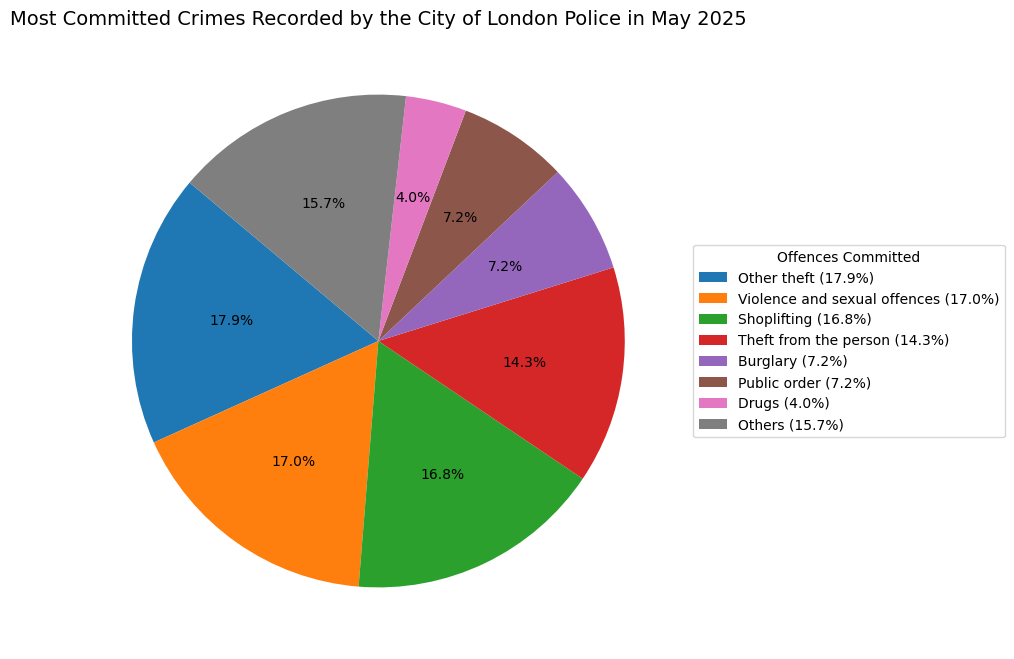

In [41]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd

# Group by "Crime type" and count records
crime_counts_full = lp_geospatial_crimes_df["Crime type"].value_counts()

# Take top 7 crimes
top7 = crime_counts_full.head(7)

# Sum the rest as "Others"
others_sum = crime_counts_full.iloc[7:].sum()

# Combine top 7 + Others
crime_counts = pd.concat([top7, pd.Series({"Others": others_sum})])

# Calculate percentages
crime_percentages = (crime_counts / crime_counts.sum() * 100).round(1)

# Create pie chart with top 7 + Others
fig, ax = plt.subplots(figsize=(10, 8))  # create a figure and axes
wedges, texts, autotexts = ax.pie(
    crime_counts,
    autopct='%1.1f%%',
    startangle=140
)

# Build legend labels with percentages
legend_labels = [f"{crime} ({pct}%)" for crime, pct in zip(crime_counts.index, crime_percentages)]

# Add a legend on the side of the chart
ax.legend(
    wedges,
    legend_labels,
    title="Offences Committed",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Add title
ax.set_title("Most Committed Crimes Recorded by the City of London Police in May 2025", fontsize=14)

# Save the figure into a variable
lp_crimes = fig

# Save to PNG + embed in HTML with legend text
# Save chart as PNG
png_filename = "london_crimes_pie.png"
lp_crimes.savefig(png_filename, dpi=300, bbox_inches="tight")

# Build HTML content with chart + legend list
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])
html_content = f"""
<html>
<head><title>London Crimes Pie Chart</title></head>
<body>
<h2>Most Committed Crimes Recorded by the City of London Police in May 2025</h2>
<img src="{png_filename}" alt="Pie Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""

# Save HTML file
with open("london_crimes_pie.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'london_crimes_pie.html' with embedded PNG and legend.")

# Show in notebook
plt.show()


By applying the following location filter, we can employ the same code structure and fine-tune it for the most crime-prone locations that we previously analysed in the ***Crimes and their Locations*** section of this work.

```Python
# Filter dataset by selected locations
selected_locations = [
    "On or near Shopping Area",
    "On or near Victoria Avenue",
    "On or near Supermarket",
    "On or near Circus Place",
    "On or near Bishopsgate"
]

filtered_df = lp_geospatial_crimes_df[
    lp_geospatial_crimes_df["Location"].isin(selected_locations)
]
``` 

✅ Chart saved as 'london_crimes_most_pie.html' with embedded PNG and legend.


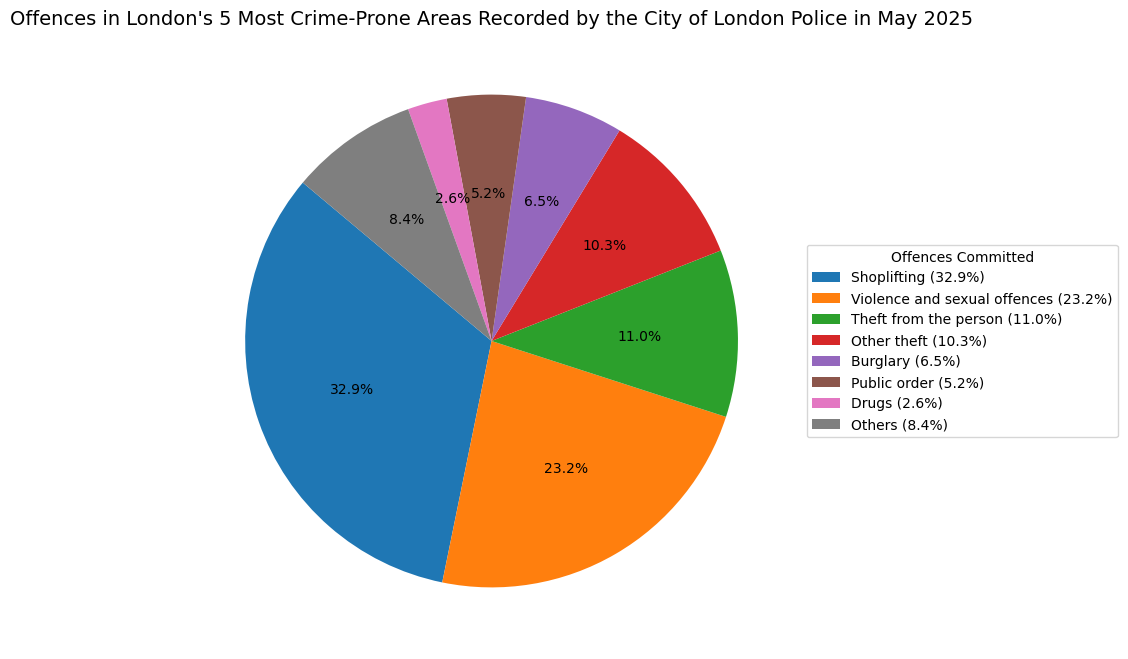

In [42]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd

# Filter dataset by selected locations
selected_locations = [
    "On or near Shopping Area",
    "On or near Victoria Avenue",
    "On or near Supermarket",
    "On or near Circus Place",
    "On or near Bishopsgate"
]

filtered_df = lp_geospatial_crimes_df[
    lp_geospatial_crimes_df["Location"].isin(selected_locations)
]

# Group by "Crime type" and count records
crime_counts_full = filtered_df["Crime type"].value_counts()

# Take top 7 crimes
top7 = crime_counts_full.head(7)

# Sum the rest as "Others"
others_sum = crime_counts_full.iloc[7:].sum()

# Combine top 7 + Others
crime_counts = pd.concat([top7, pd.Series({"Others": others_sum})])

# Calculate percentages
crime_percentages = (crime_counts / crime_counts.sum() * 100).round(1)

# Create pie chart with top 7 + Others
fig, ax = plt.subplots(figsize=(10, 8))  # create a figure and axes
wedges, texts, autotexts = ax.pie(
    crime_counts,
    autopct='%1.1f%%',
    startangle=140
)

# Build legend labels with percentages
legend_labels = [f"{crime} ({pct}%)" for crime, pct in zip(crime_counts.index, crime_percentages)]

# Add a legend on the side of the chart
ax.legend(
    wedges,
    legend_labels,
    title="Offences Committed",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Add title
ax.set_title("Offences in London's 5 Most Crime-Prone Areas Recorded by the City of London Police in May 2025", fontsize=14)

# Save the figure into a variable
lp_crimes_most = fig

# Save to PNG + embed in HTML with legend text
png_filename = "london_crimes_most_pie.png"
lp_crimes_most.savefig(png_filename, dpi=300, bbox_inches="tight")

# Build HTML content with chart + legend list
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])
html_content = f"""
<html>
<head><title>London Crimes Pie Chart (Selected Locations)</title></head>
<body>
<h2>Most Committed Crimes in Selected Locations (May 2025)</h2>
<img src="{png_filename}" alt="Pie Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""

# Save HTML file
with open("london_crimes_most_pie.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'london_crimes_most_pie.html' with embedded PNG and legend.")

# Show in notebook
plt.show()


And do the same with the City of London's least crime-prone areas. Here, since the category of offences reported are only 5, we won't need to count all the remaining and group them under the category `"Others"`.

✅ Chart saved as 'london_crimes_least_pie.html' with embedded PNG and legend.


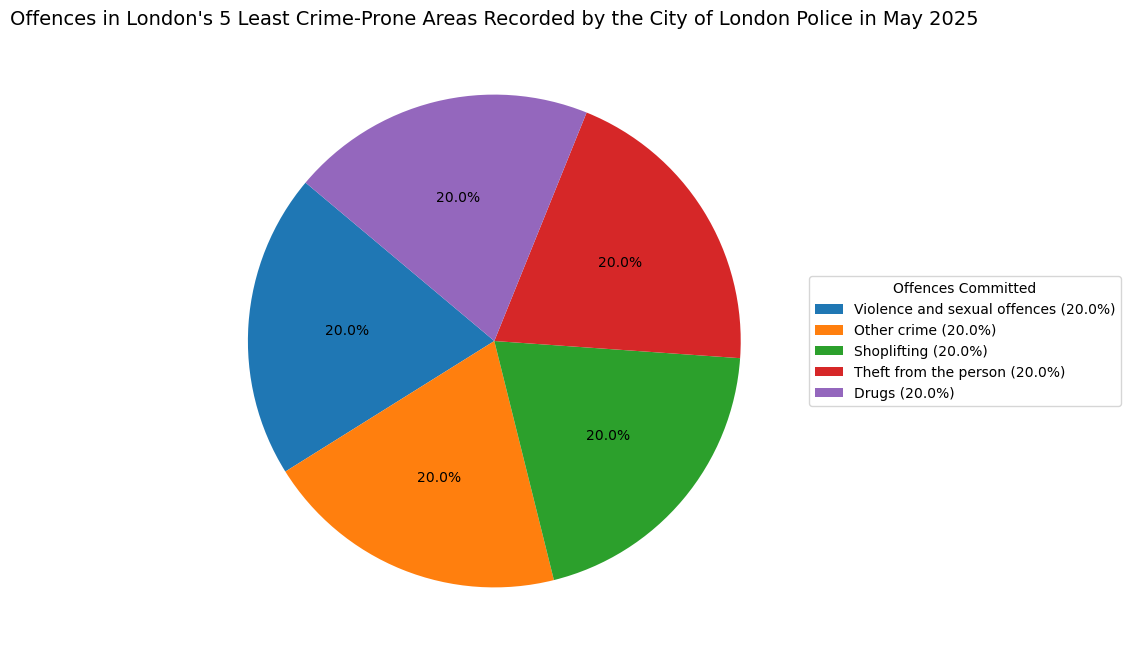

In [43]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd

# Filter dataset by selected locations
selected_locations = [
    "On or near A1240",
    "On or near A3211",
    "On or near Amen Corner",
    "On or near Back Mornington Road",
    "On or near Bartholomew Close"
]

filtered_df = lp_geospatial_crimes_df[
    lp_geospatial_crimes_df["Location"].isin(selected_locations)
]

# Group by "Crime type" and count records (all crime types since there are only 5)
crime_counts = filtered_df["Crime type"].value_counts()

# Calculate percentages
crime_percentages = (crime_counts / crime_counts.sum() * 100).round(1)

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 8))  # create a figure and axes
wedges, texts, autotexts = ax.pie(
    crime_counts,
    autopct='%1.1f%%',
    startangle=140
)

# Build legend labels with percentages
legend_labels = [f"{crime} ({pct}%)" for crime, pct in zip(crime_counts.index, crime_percentages)]

# Add a legend on the side of the chart
ax.legend(
    wedges,
    legend_labels,
    title="Offences Committed",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Add title
ax.set_title("Offences in London's 5 Least Crime-Prone Areas Recorded by the City of London Police in May 2025", fontsize=14)

# Save the figure into a variable
lp_crimes_least = fig

# Save to PNG + embed in HTML with legend text
png_filename = "london_crimes_least_pie.png"
lp_crimes_least.savefig(png_filename, dpi=300, bbox_inches="tight")

# Build HTML content with chart + legend list
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])
html_content = f"""
<html>
<head><title>London Crimes Pie Chart (Selected Locations - Least Crime-Prone)</title></head>
<body>
<h2>Most Committed Crimes in Selected Least Crime-Prone Locations (May 2025)</h2>
<img src="{png_filename}" alt="Pie Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""

# Save HTML file
with open("london_crimes_least_pie.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'london_crimes_least_pie.html' with embedded PNG and legend.")

# Show in notebook
plt.show()


Finally, with minor tweaks, we can apply the same principle to `MP_WARD_LEVEL`, and list the 8 most committed crimes in May 2025. To do so, however, we will have to implement aggregate counts, since the offences are numerically listed in column AA, attribute `202505`.

```Python
# Aggregate counts for May 2025 grouped by "MajorText"
crime_counts = (
    mp_ward_level_df.groupby("MajorText")["202505"].sum()
    .sort_values(ascending=False)
    .head(8)
)
```

✅ Chart saved as 'mp_crimes_pie.html' with embedded PNG and legend.


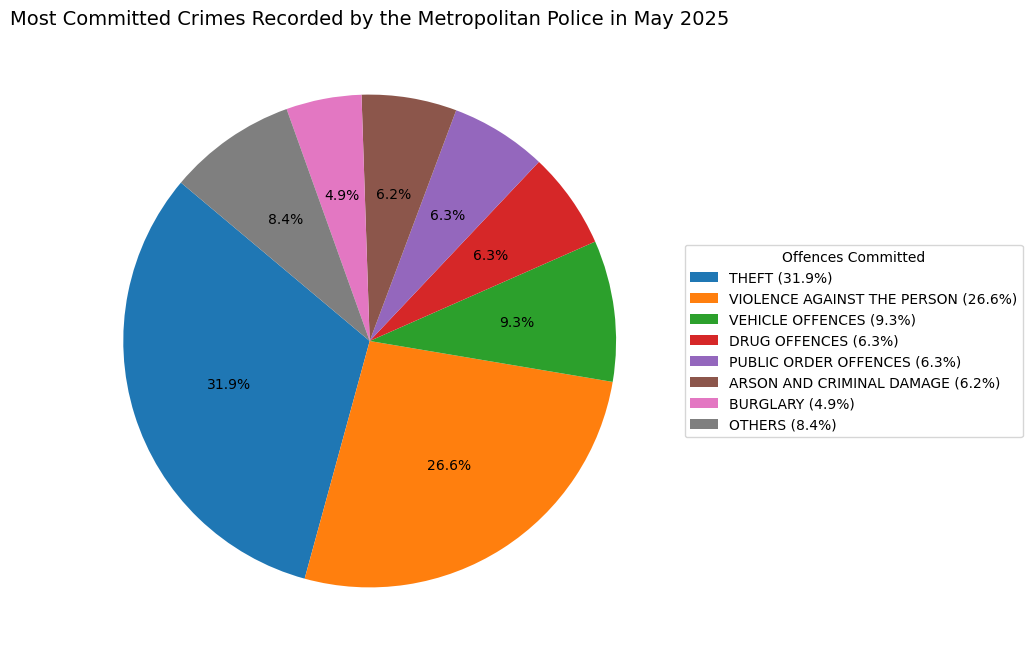

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# Aggregate counts for May 2025 grouped by "MajorText"
crime_counts_full = (
    mp_ward_level_df.groupby("MajorText")["202505"].sum()
    .sort_values(ascending=False)
)

# Take top 7 crimes
top7 = crime_counts_full.head(7)

# Sum the rest as "OTHERS"
others_sum = crime_counts_full.iloc[7:].sum()

# Combine top 7 + OTHERS
crime_counts = pd.concat([top7, pd.Series({"OTHERS": others_sum})])

# Calculate percentages
crime_percentages = (crime_counts / crime_counts.sum() * 100).round(1)

# Create pie chart with top 7 + OTHERS
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    crime_counts,
    autopct='%1.1f%%',
    startangle=140
)

# Build legend labels with percentages
legend_labels = [f"{crime} ({pct}%)" for crime, pct in zip(crime_counts.index, crime_percentages)]

# Add legend
ax.legend(
    wedges,
    legend_labels,
    title="Offences Committed",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Add title
ax.set_title("Most Committed Crimes Recorded by the Metropolitan Police in May 2025", fontsize=14)

# Save to PNG and embed into HTML
# Save the figure into a variable
mp_crimes = fig

# Save chart as PNG
png_filename = "mp_crimes_pie.png"
mp_crimes.savefig(png_filename, dpi=300, bbox_inches="tight")

# Build HTML content with chart + legend list
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])
html_content = f"""
<html>
<head><title>London Metropolitan Police Crimes Pie Chart</title></head>
<body>
<h2>Most Committed Crimes Recorded by the Metropolitan Police in May 2025</h2>
<img src="{png_filename}" alt="Pie Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""

# Save HTML file
with open("mp_crimes_pie.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'mp_crimes_pie.html' with embedded PNG and legend.")

# Show in notebook
plt.show()


And filter its most crime-prone wards as follows.

```Python
# Filter only the 5 most crime-prone wards
selected_wards = [
    "West End",
    "St James's",
    "Bloomsbury",
    "Heathrow Villages",
    "Stratford Olympic Park"
```  


✅ Chart saved as 'mp_crimes_most_pie.html' with embedded PNG and legend.


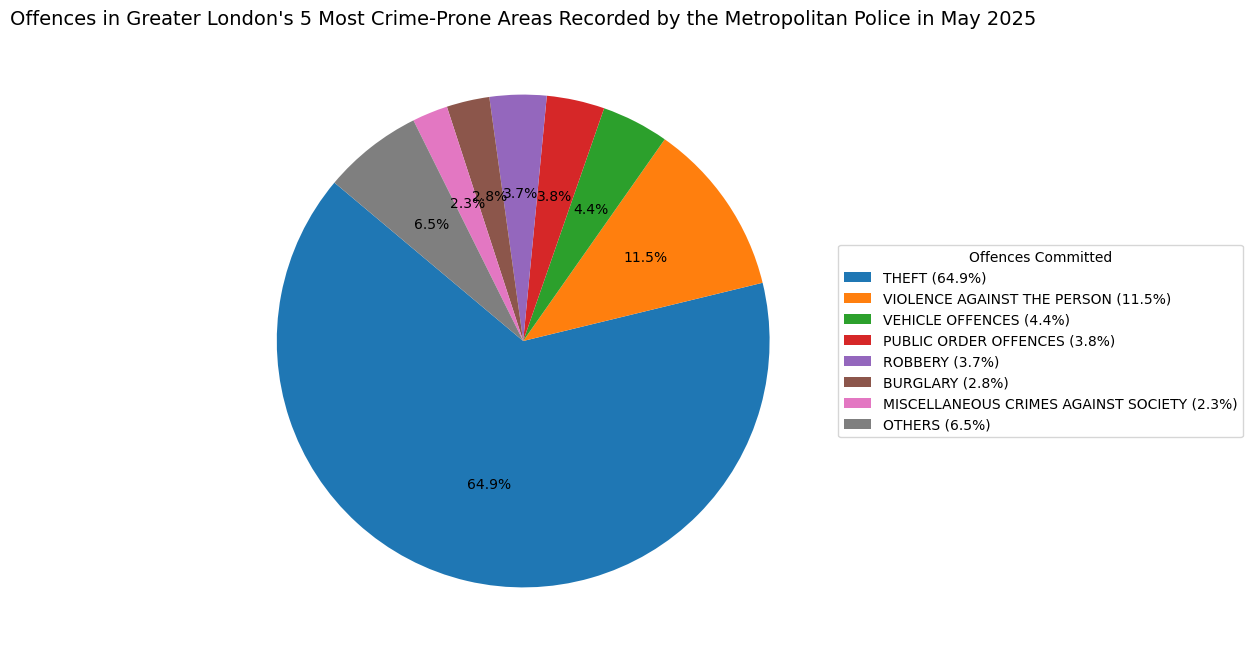

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter only the 5 most crime-prone wards
selected_wards = [
    "West End",
    "St James's",
    "Bloomsbury",
    "Heathrow Villages",
    "Stratford Olympic Park"
]

filtered_df = mp_ward_level_df[mp_ward_level_df["WardName"].isin(selected_wards)]

# Aggregate counts for May 2025 grouped by "MajorText"
crime_counts_full = (
    filtered_df.groupby("MajorText")["202505"].sum()
    .sort_values(ascending=False)
)

# Take top 7 crimes
top7 = crime_counts_full.head(7)

# Sum the rest as "OTHERS"
others_sum = crime_counts_full.iloc[7:].sum()

# Combine top 7 + OTHERS
crime_counts = pd.concat([top7, pd.Series({"OTHERS": others_sum})])

# Calculate percentages
crime_percentages = (crime_counts / crime_counts.sum() * 100).round(1)

# Create pie chart with top 7 + OTHERS
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    crime_counts,
    autopct='%1.1f%%',
    startangle=140
)

# Build legend labels with percentages
legend_labels = [f"{crime} ({pct}%)" for crime, pct in zip(crime_counts.index, crime_percentages)]

# Add legend
ax.legend(
    wedges,
    legend_labels,
    title="Offences Committed",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Add updated title
ax.set_title("Offences in Greater London's 5 Most Crime-Prone Areas Recorded by the Metropolitan Police in May 2025", fontsize=14)

# Save to PNG and embed into HTML
# Save the figure into a variable
mp_crimes_most = fig

# Save chart as PNG
png_filename = "mp_crimes_most_pie.png"
mp_crimes_most.savefig(png_filename, dpi=300, bbox_inches="tight")

# Build HTML content with chart + legend list
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])
html_content = f"""
<html>
<head><title>Metropolitan Police Most Crime-Prone Areas Pie Chart</title></head>
<body>
<h2>Most Offences in the Most Crime-Prone Areas Recorded by the Metropolitan Police in May 2025</h2>
<img src="{png_filename}" alt="Pie Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""

# Save HTML file
with open("mp_crimes_most_pie.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'mp_crimes_most_pie.html' with embedded PNG and legend.")

# Show in notebook
plt.show()


Quite impressively, we see an outstanding dominance of thefts in the most crime-prone areas of Greater London (64.9% of the total). Let's then see which offences were the most perpetuated in the least crime-prone locations of the City. 

✅ Chart saved as 'mp_crimes_least_pie.html' with embedded PNG and legend.


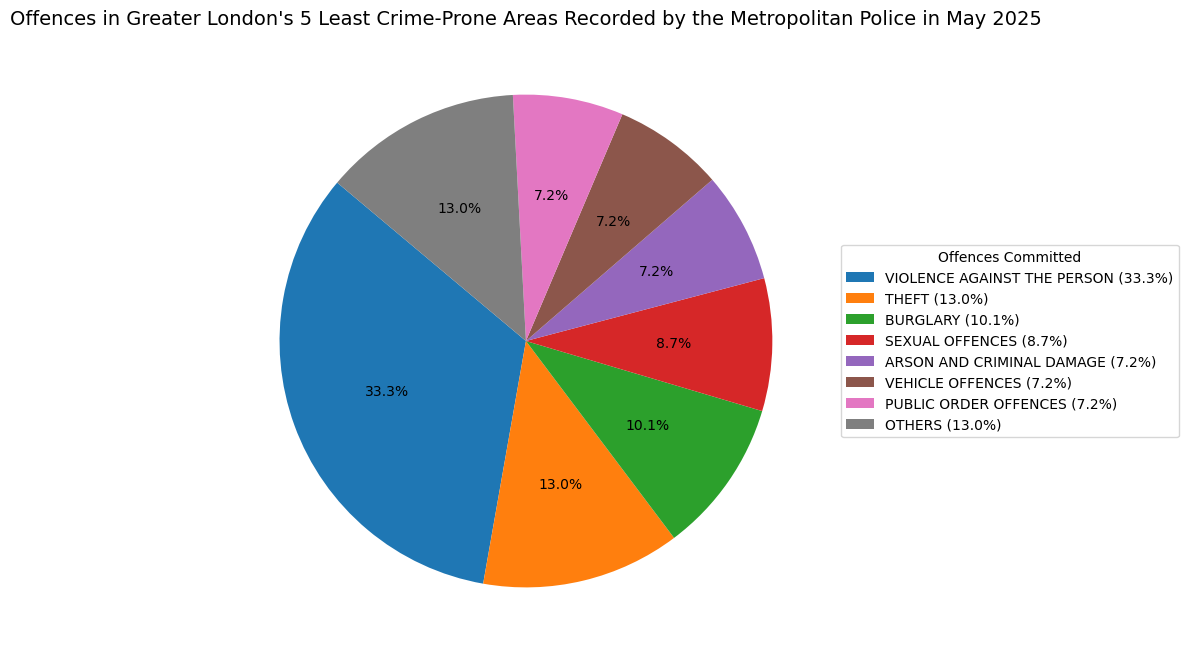

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter only the 5 selected least crime-prone wards
selected_wards = [
    "Motspur Park & Old Malden East",
    "Tudor",
    "Worcester Park South",
    "Cranham",
    "Park Hill & Whitgift"
]

filtered_df = mp_ward_level_df[mp_ward_level_df["WardName"].isin(selected_wards)]

# === Aggregate counts for May 2025 grouped by "MajorText"
crime_counts_full = (
    filtered_df.groupby("MajorText")["202505"].sum()
    .sort_values(ascending=False)
)

# Take top 7 crimes
top7 = crime_counts_full.head(7)

# Sum the rest as "OTHERS"
others_sum = crime_counts_full.iloc[7:].sum()

# Combine top 7 + OTHERS
crime_counts = pd.concat([top7, pd.Series({"OTHERS": others_sum})])

# Calculate percentages
crime_percentages = (crime_counts / crime_counts.sum() * 100).round(1)

# === Step 3: Create pie chart with top 7 + OTHERS ===
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    crime_counts,
    autopct='%1.1f%%',
    startangle=140
)

# Build legend labels with percentages
legend_labels = [f"{crime} ({pct}%)" for crime, pct in zip(crime_counts.index, crime_percentages)]

# Add legend
ax.legend(
    wedges,
    legend_labels,
    title="Offences Committed",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Add updated title
ax.set_title("Offences in Greater London's 5 Least Crime-Prone Areas Recorded by the Metropolitan Police in May 2025", fontsize=14)

# Save to PNG and embed into HTML
# Save the figure into a variable
mp_crimes_least = fig

# Save chart as PNG
png_filename = "mp_crimes_least_pie.png"
mp_crimes_least.savefig(png_filename, dpi=300, bbox_inches="tight")

# Build HTML content with chart + legend list
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])
html_content = f"""
<html>
<head><title>Metropolitan Police Least Crime-Prone Areas Pie Chart</title></head>
<body>
<h2>Most Offences in the Least Crime-Prone Areas Recorded by the Metropolitan Police in May 2025</h2>
<img src="{png_filename}" alt="Pie Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""

# Save HTML file
with open("mp_crimes_least_pie.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'mp_crimes_least_pie.html' with embedded PNG and legend.")

# Show in notebook
plt.show()

Having completed our analysis of the `LP_GEOSPATIAL_CRIMES` and `MP_WARD_LEVEL` datasets, we can proceed with the Office for National Statistics data. Important insights can be gained by plotting the British Passport Holders VS the Foreign Passport Holders in the most and least crime-prone areas of Greater London, to see if we notice discernible differences. A bar chart would be a good fit to achieve this end. Following is the code explanation.

### ***Imports***  

```Python
import matplotlib.pyplot as plt
import pandas as pd
```  

* `matplotlib.pyplot as plt`: plotting API used to build the bar chart.
* `pandas as pd`: common data library, which is not strictly used in this snippet, but it's fine to keep for consistency.

### ***Input Data: Totals and British Counts***  

```Python
# Data (totals + British)
wards_data = {
    "West End": {"total": 11542, "british": 6389},
    "St James's": {"total": 10365, "british": 6057},
    "Bloomsbury": {"total": 11095, "british": 6439},
    "Heathrow Villages": {"total": 14037, "british": 7941},
    "Stratford Olympic Park": {"total": 11862, "british": 7455},
}
```  

* A nested dictionary keyed by ward name.
* For each ward are only two numbers:
    * `total`: total passport holders.
    * `british`: British passport holders.

### ***Prepare Series for Plotting***  

```Python
# Prepare series
wards = list(wards_data.keys())
```  

* Extracts ward names in order for the x-axis.

```Python
british_counts = [wards_data[w]["british"] for w in wards]
```  

* List comprehension: pulls the British count for each ward in the same order as `wards`.

```Python
others_counts  = [wards_data[w]["total"] - wards_data[w]["british"] for w in wards]
```  
* Computes Foreign/Other as `total - british` for each ward.

### ***Compute Percentages (per Ward)***  

```Python
british_perc = [round(b / wards_data[w]["total"] * 100, 1) for w, b in zip(wards, british_counts)]
```  

* For each ward, computes British share as a percentage of that ward’s total, rounded to 1 decimal.

```Python
others_perc  = [round(o / wards_data[w]["total"] * 100, 1) for w, o in zip(wards, others_counts)]
```  

* Same for Foreign/Other.

### ***Axis Positions and Figure***  

```Python
# Plot grouped bar chart
x = range(len(wards))
bar_width = 0.4
```  

* `x`: positions 0..N-1 for the ward groups.
* `bar_width`: width of each bar (0.4 works well for side-by-side bars).

```Python
fig, ax = plt.subplots(figsize=(12, 7))
```  

* Creates the Figure and single Axes; sets canvas size.

### ***Draw bars (Blue = British, Red = Foreign)***  

```Python
# British (blue) and Foreign (red)
bars_british = ax.bar([i - bar_width/2 for i in x], british_counts, width=bar_width, label="British Passport Holders", color="blue")
```  

* Positions British bars left of each ward centre (`i - bar_width/2`).
* Sets label for the legend and colour blue.

```Python
bars_others  = ax.bar([i + bar_width/2 for i in x], others_counts,  width=bar_width, label="Foreign Passport Holders",  color="red")
```  

* Positions Foreign/Other bars right of each ward centre (i + bar_width/2).
* Sets label and colour red.

### ***X-axis labels, Y-axis label, Title***  

```Python
# Labels and title
ax.set_xticks(list(x))
ax.set_xticklabels(wards, rotation=0, ha="center")  # straight labels (no diagonal)
```  

* Places ticks at each group centre and prints ward names horizontally.

```Python
ax.set_ylabel("Number of Passport Holders")
```  

* Y-axis label.

```Python
ax.set_title("British VS Foreign Passport Holders in Greater London's Most Crime-Prone Areas", fontsize=14)
``` 

* Chart title with font size 14.

### ***Legend Placement***  

```Python
# Legend in the upper-left
ax.legend(loc="upper left")
```  

* Places the legend box in the upper-left corner of the Axes.

### ***Bar Annotations (Numbers and Percentages)***  

```Python
# Annotations: numbers + percentages above each bar
for bars, counts, percs in [(bars_british, british_counts, british_perc), (bars_others, others_counts, others_perc)]:
    for bar, count, perc in zip(bars, counts, percs):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(max(british_counts), max(others_counts)) * 0.01,
            f"{count}\n({perc}%)",
            ha="center", va="bottom", fontsize=9
        )
```  

* Outer loop runs twice: once for British bars, once for Foreign bars.
* Inner loop pairs each bar with its (`count, percentage`).
* `bar.get_x() + bar.get_width()/2`: centres text horizontally on the bar.
* `bar.get_height() + ... * 0.01`: puts text a bit above the top of the bar (1% of the global max height).
* `f"{count}\n({perc}%)"`: two-line label (number on top, percentage below).
* `ha="center", va="bottom"`: centre text horizontally, anchor at the bottom of the text box

### ***Tight Layout***  

```Python
plt.tight_layout()
```  

* Automatically adjusts margins to avoid clipping text or the legend.

### ***Keep a Reference to the Figure***  

```Python
# Save the figure in the requested variable
ons_passport_holders_most = fig
```  

* Stores the Figure object for later saving/reuse.

### ***Save PNG (Filename Variable as Requested)***  

```Python
# Save PNG with the requested filename variable
png_filename = "ons_passport_holders_most"  # (as requested; no extension)
ons_passport_holders_most.savefig(png_filename, dpi=300, bbox_inches="tight")
```  

* Sets the filename without extension (as requested).
* Saves at 300 dpi and trims extra whitespace (`bbox_inches="tight.

### ***Build legend labels for HTML***  

```Python
# Build HTML content with chart + legend list
legend_labels = [
    f"British: {c} ({p}%)" for c, p in zip(british_counts, british_perc)
]
legend_labels += [
    f"Foreign: {c} ({p}%)" for c, p in zip(others_counts, others_perc)
]
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])
```  

* First list comprehension creates British legend items (count + percent) for each ward.
* Second list comprehension creates Foreign legend items, then concatenates using `+=`.
* Joins them into `<li>…</li>` HTML entries for the page.

### ***HTML Page Content***  

```Python
html_content = f"""
<html>
<head><title>ONS Passport Holders (Most Crime-Prone Areas)</title></head>
<body>
<h2>British VS Foreign Passport Holders in Greater London's Most Crime-Prone Areas</h2>
<img src="{png_filename}" alt="Bar Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""
```  

* Multi-line f-string that:
    * Sets the web page title.
    * Inserts the chart image using `png_filename`.
    * Prints a human-readable legend list underneath.

### ***Save HTML File and Confirm***  

```Python
# Save HTML file with the requested name
with open("ons_passport_holders_most.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'ons_passport_holders_most.html' with embedded PNG and legend.")
```  

* Writes the HTML to `ons_passport_holders_most.html`.
* Prints a confirmation message.

### ***Render Chart in the Notebook***  

```Python
# Show chart in notebook
plt.show()
```  

* Displays the chart inline in the current notebook cell output.

✅ Chart saved as 'ons_passport_holders_most.html' with embedded PNG and legend.


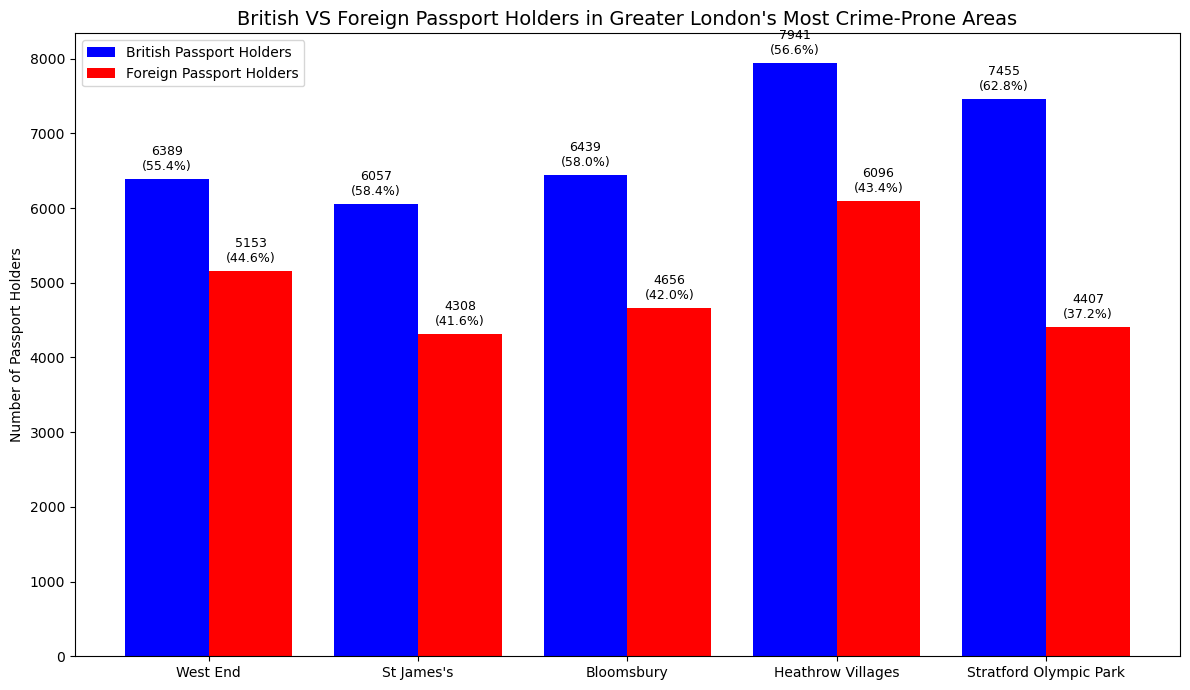

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Data (totals + British)
wards_data = {
    "West End": {"total": 11542, "british": 6389},
    "St James's": {"total": 10365, "british": 6057},
    "Bloomsbury": {"total": 11095, "british": 6439},
    "Heathrow Villages": {"total": 14037, "british": 7941},
    "Stratford Olympic Park": {"total": 11862, "british": 7455},
}

# Prepare series
wards = list(wards_data.keys())
british_counts = [wards_data[w]["british"] for w in wards]
others_counts  = [wards_data[w]["total"] - wards_data[w]["british"] for w in wards]

british_perc = [round(b / wards_data[w]["total"] * 100, 1) for w, b in zip(wards, british_counts)]
others_perc  = [round(o / wards_data[w]["total"] * 100, 1) for w, o in zip(wards, others_counts)]

# Plot grouped bar chart
x = range(len(wards))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(12, 7))

# British (blue) and Foreign (red)
bars_british = ax.bar([i - bar_width/2 for i in x], british_counts, width=bar_width, label="British Passport Holders", color="blue")
bars_others  = ax.bar([i + bar_width/2 for i in x], others_counts,  width=bar_width, label="Foreign Passport Holders",  color="red")

# Labels and title
ax.set_xticks(list(x))
ax.set_xticklabels(wards, rotation=0, ha="center")  # straight labels (no diagonal)
ax.set_ylabel("Number of Passport Holders")
ax.set_title("British VS Foreign Passport Holders in Greater London's Most Crime-Prone Areas", fontsize=14)

# Legend in the upper-left
ax.legend(loc="upper left")

# Annotations: numbers + percentages above each bar
for bars, counts, percs in [(bars_british, british_counts, british_perc), (bars_others, others_counts, others_perc)]:
    for bar, count, perc in zip(bars, counts, percs):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(max(british_counts), max(others_counts)) * 0.01,
            f"{count}\n({perc}%)",
            ha="center", va="bottom", fontsize=9
        )

plt.tight_layout()

# Save the figure in the requested variable
ons_passport_holders_most = fig

# Save PNG with the requested filename variable
png_filename = "ons_passport_holders_most.png"  # (as requested; no extension)
ons_passport_holders_most.savefig(png_filename, dpi=300, bbox_inches="tight")

# Build HTML content with chart + legend list
legend_labels = [
    f"British: {c} ({p}%)" for c, p in zip(british_counts, british_perc)
]
legend_labels += [
    f"Foreign: {c} ({p}%)" for c, p in zip(others_counts, others_perc)
]
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])

html_content = f"""
<html>
<head><title>ONS Passport Holders (Most Crime-Prone Areas)</title></head>
<body>
<h2>British VS Foreign Passport Holders in Greater London's Most Crime-Prone Areas</h2>
<img src="{png_filename}" alt="Bar Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""

# Save HTML file with the requested name
with open("ons_passport_holders_most.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'ons_passport_holders_most.html' with embedded PNG and legend.")

# Show chart in notebook
plt.show()

Now, we can tailor the previous code to plot the difference between British and foreign passport holders in Greater London's least crime-prone area, and see how do they differ. 

✅ Chart saved as 'ons_passport_holders_least.html' with embedded PNG and legend.


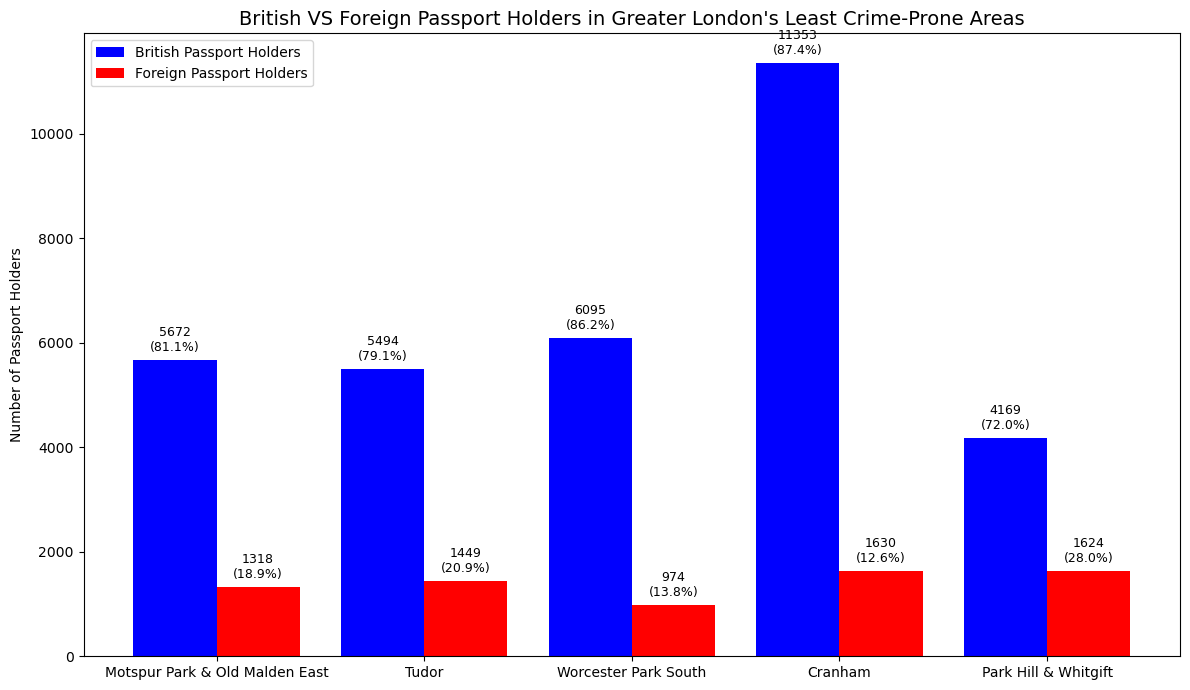

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Data (totals + British)
wards_data = {
    "Motspur Park & Old Malden East": {"total": 6990, "british": 5672},
    "Tudor": {"total": 6943, "british": 5494},
    "Worcester Park South": {"total": 7069, "british": 6095},
    "Cranham": {"total": 12983, "british": 11353},
    "Park Hill & Whitgift": {"total": 5793, "british": 4169},
}

# Prepare series
wards = list(wards_data.keys())
british_counts = [wards_data[w]["british"] for w in wards]
others_counts  = [wards_data[w]["total"] - wards_data[w]["british"] for w in wards]

british_perc = [round(b / wards_data[w]["total"] * 100, 1) for w, b in zip(wards, british_counts)]
others_perc  = [round(o / wards_data[w]["total"] * 100, 1) for w, o in zip(wards, others_counts)]

# Plot grouped bar chart
x = range(len(wards))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(12, 7))

# British (blue) and Foreign (red)
bars_british = ax.bar([i - bar_width/2 for i in x], british_counts, width=bar_width, label="British Passport Holders", color="blue")
bars_others  = ax.bar([i + bar_width/2 for i in x], others_counts,  width=bar_width, label="Foreign Passport Holders",  color="red")

# Labels and title
ax.set_xticks(list(x))
ax.set_xticklabels(wards, rotation=0, ha="center")  # straight labels (no diagonal)
ax.set_ylabel("Number of Passport Holders")
ax.set_title("British VS Foreign Passport Holders in Greater London's Least Crime-Prone Areas", fontsize=14)

# Legend in the upper-left
ax.legend(loc="upper left")

# Annotations: numbers + percentages above each bar
for bars, counts, percs in [(bars_british, british_counts, british_perc), (bars_others, others_counts, others_perc)]:
    for bar, count, perc in zip(bars, counts, percs):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(max(british_counts), max(others_counts)) * 0.01,
            f"{count}\n({perc}%)",
            ha="center", va="bottom", fontsize=9
        )

plt.tight_layout()

# Save the figure in the requested variable
ons_passport_holders_least = fig

# Save PNG with the requested filename variable
png_filename = "ons_passport_holders_least.png"
ons_passport_holders_most.savefig(png_filename, dpi=300, bbox_inches="tight")

# Build HTML content with chart + legend list
legend_labels = [
    f"British: {c} ({p}%)" for c, p in zip(british_counts, british_perc)
]
legend_labels += [
    f"Foreign: {c} ({p}%)" for c, p in zip(others_counts, others_perc)
]
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])

html_content = f"""
<html>
<head><title>ONS Passport Holders (Least Crime-Prone Areas)</title></head>
<body>
<h2>British VS Foreign Passport Holders in Greater London's Least Crime-Prone Areas</h2>
<img src="{png_filename}" alt="Bar Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""

# Save HTML file with the requested name
with open("ons_passport_holders_least.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'ons_passport_holders_least.html' with embedded PNG and legend.")

# Show chart in notebook
plt.show()

By an initial observation, it appears quite evident that the most crime-prone areas of Greater London are populated by an increased presence of foreigners. Now, we can repeat the experiment by analysing the `ONS_ETHNIC_GROUPS` dataset and comparing the numbers of white British and other ethnicities in the same locations of the City.

✅ Chart saved as 'ons_ethnic_groups_most.html' with embedded PNG and legend.


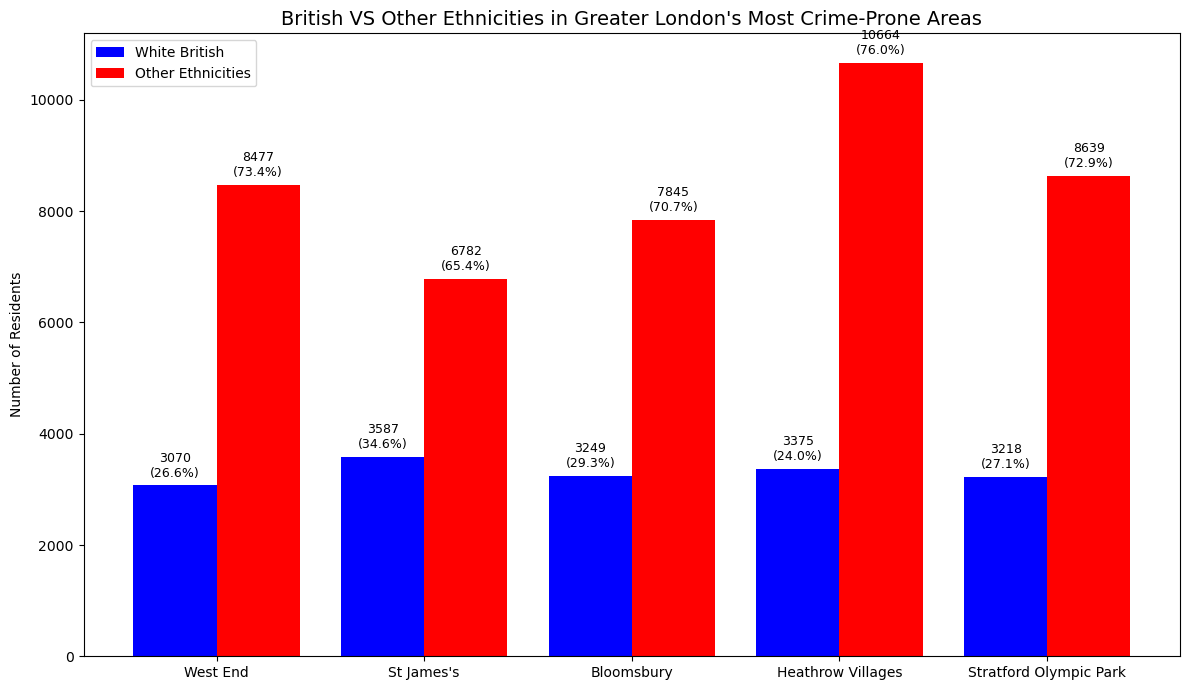

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

# Data (totals + British)
wards_data = {
    "West End": {"total": 11547, "british": 3070},
    "St James's": {"total": 10369, "british": 3587},
    "Bloomsbury": {"total": 11094, "british": 3249},
    "Heathrow Villages": {"total": 14039, "british": 3375},
    "Stratford Olympic Park": {"total": 11857, "british": 3218},
}

# Prepare series
wards = list(wards_data.keys())
british_counts = [wards_data[w]["british"] for w in wards]
others_counts  = [wards_data[w]["total"] - wards_data[w]["british"] for w in wards]

british_perc = [round(b / wards_data[w]["total"] * 100, 1) for w, b in zip(wards, british_counts)]
others_perc  = [round(o / wards_data[w]["total"] * 100, 1) for w, o in zip(wards, others_counts)]

# Plot grouped bar chart
x = range(len(wards))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(12, 7))

# British (blue) and Foreign (red)
bars_british = ax.bar([i - bar_width/2 for i in x], british_counts, width=bar_width, label="White British", color="blue")
bars_others  = ax.bar([i + bar_width/2 for i in x], others_counts,  width=bar_width, label="Other Ethnicities",  color="red")

# Labels and title
ax.set_xticks(list(x))
ax.set_xticklabels(wards, rotation=0, ha="center")  # straight labels (no diagonal)
ax.set_ylabel("Number of Residents")
ax.set_title("British VS Other Ethnicities in Greater London's Most Crime-Prone Areas", fontsize=14)

# Legend in the upper-left
ax.legend(loc="upper left")

# Annotations: numbers + percentages above each bar
for bars, counts, percs in [(bars_british, british_counts, british_perc), (bars_others, others_counts, others_perc)]:
    for bar, count, perc in zip(bars, counts, percs):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(max(british_counts), max(others_counts)) * 0.01,
            f"{count}\n({perc}%)",
            ha="center", va="bottom", fontsize=9
        )

plt.tight_layout()

# Save the figure in the requested variable
ons_ethnic_groups_most = fig

# === Save PNG with the requested filename variable ===
png_filename = "ons_ethnic_groups_most.png" 
ons_passport_holders_most.savefig(png_filename, dpi=300, bbox_inches="tight")

# Build HTML content with chart + legend list
legend_labels = [
    f"British: {c} ({p}%)" for c, p in zip(british_counts, british_perc)
]
legend_labels += [
    f"Foreign: {c} ({p}%)" for c, p in zip(others_counts, others_perc)
]
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])

html_content = f"""
<html>
<head><title>ONS Ethnic Groups (Most Crime-Prone Areas)</title></head>
<body>
<h2>"British VS Other Ethnicities in Greater London's Most Crime-Prone Areas"</h2>
<img src="{png_filename}" alt="Bar Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""

# Save HTML file with the requested name
with open("ons_ethnic_groups_most.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'ons_ethnic_groups_most.html' with embedded PNG and legend.")

# Show chart in notebook
plt.show()

With minimal tweaks, we can obtain the same graphs comparing the ethnicities in the least crime-prone areas of Greater London.

✅ Chart saved as 'ons_ethnic_groups_most.html' with embedded PNG and legend.


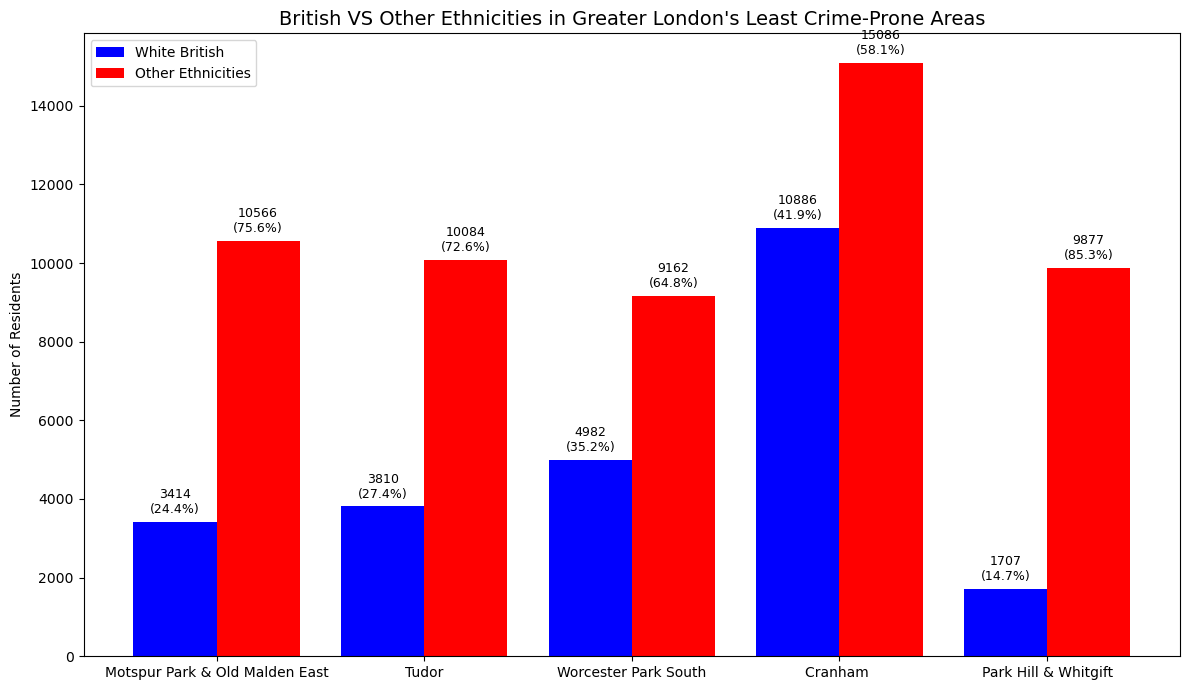

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

# Data (totals + British)
wards_data = {
    "Motspur Park & Old Malden East": {"total": 13980, "british": 3414},
    "Tudor": {"total": 13894, "british": 3810},
    "Worcester Park South": {"total": 14144, "british": 4982},
    "Cranham ": {"total": 25972, "british": 10886},
    "Park Hill & Whitgift": {"total": 11584, "british": 1707},
}

# Prepare series
wards = list(wards_data.keys())
british_counts = [wards_data[w]["british"] for w in wards]
others_counts  = [wards_data[w]["total"] - wards_data[w]["british"] for w in wards]

british_perc = [round(b / wards_data[w]["total"] * 100, 1) for w, b in zip(wards, british_counts)]
others_perc  = [round(o / wards_data[w]["total"] * 100, 1) for w, o in zip(wards, others_counts)]

# Plot grouped bar chart
x = range(len(wards))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(12, 7))

# British (blue) and Foreign (red)
bars_british = ax.bar([i - bar_width/2 for i in x], british_counts, width=bar_width, label="White British", color="blue")
bars_others  = ax.bar([i + bar_width/2 for i in x], others_counts,  width=bar_width, label="Other Ethnicities",  color="red")

# Labels and title
ax.set_xticks(list(x))
ax.set_xticklabels(wards, rotation=0, ha="center")  # straight labels (no diagonal)
ax.set_ylabel("Number of Residents")
ax.set_title("British VS Other Ethnicities in Greater London's Least Crime-Prone Areas", fontsize=14)

# Legend in the upper-left
ax.legend(loc="upper left")

# Annotations: numbers + percentages above each bar
for bars, counts, percs in [(bars_british, british_counts, british_perc), (bars_others, others_counts, others_perc)]:
    for bar, count, perc in zip(bars, counts, percs):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(max(british_counts), max(others_counts)) * 0.01,
            f"{count}\n({perc}%)",
            ha="center", va="bottom", fontsize=9
        )

plt.tight_layout()

# Save the figure in the requested variable
ons_ethnic_groups_least = fig

# Save PNG with the requested filename variable
png_filename = "ons_ethnic_groups_least.png" 
ons_passport_holders_most.savefig(png_filename, dpi=300, bbox_inches="tight")

# Build HTML content with chart + legend list
legend_labels = [
    f"British: {c} ({p}%)" for c, p in zip(british_counts, british_perc)
]
legend_labels += [
    f"Foreign: {c} ({p}%)" for c, p in zip(others_counts, others_perc)
]
legend_html = "".join([f"<li>{label}</li>" for label in legend_labels])

html_content = f"""
<html>
<head><title>ONS Ethnic Groups (Least Crime-Prone Areas)</title></head>
<body>
<h2>"British VS Other Ethnicities in Greater London's Least Crime-Prone Areas"</h2>
<img src="{png_filename}" alt="Bar Chart"><br><br>
<h3>Legend</h3>
<ul>
  {legend_html}
</ul>
</body>
</html>
"""

# Save HTML file with the requested name
with open("ons_ethnic_groups_least.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'ons_ethnic_groups_most.html' with embedded PNG and legend.")

# Show chart in notebook
plt.show()

With the exception of Worcester Park South and Cranham, where the white British ethnic group remarkably stands out when compared to the most crime-prone locations, all the other wards remain nearly as multiethnic.  
In conclusion to this section, I want to devise a graph that plots the five deprivation metrics across all ten wards and sorts them in descending order, making the one with the highest scores appear first. To achieve this end, a grouped bar chart seems the most appropriate choice, and it can be made by tweaking the previous code structure.

### ***Imports***  

```Python
import pandas as pd
import matplotlib.pyplot as plt
```  

* Adds `pandas as pd`, which is used here (unlike in the first code) to build and sort the dataset before plotting.

### ***Input Data: Deprivation Indices by Ward***

```Python
# Data for all 10 wards
wards = {
    "West End": {"IMD Extent %": 0, "Income score": 7.5, "Employment score": 5.9, "IDACI score": 11.2, "IDAOPI score": 14.1},
    ...
}
```  

* A nested dictionary keyed by ward name, but each ward now stores five deprivation scores instead of just `total` and `british`.
* The measures are already expressed as percentages (0-100 scale).

### ***Convert to DataFrame and Compute Overall Score***  

```Python
df = pd.DataFrame(wards).T
df["Overall Score"] = df.mean(axis=1)
df_sorted = df.sort_values("Overall Score", ascending=False).drop(columns="Overall Score")
```  

* Here we switch from simple lists to a DataFrame.
* A temporary `Overall Score` column is computed as the mean across indices to give a single deprivation measure per ward.
* Wards are then sorted in descending order, so the highest-deprivation wards appear first.

### ***Fixed Colours for Each Index***  

```Python
colors = {
    "IMD Extent %": "red",
    "Income score": "orange",
    "Employment score": "green",
    "IDACI score": "blue",
    "IDAOPI score": "purple"
}
```  

* Instead of hardcoding just blue and red (British vs Foreign), we define a colour map for each deprivation index.
* This ensures consistency across wards and matches the HTML legend later.

### ***Plotting with pandas DataFrame***  

```Python
fig, ax = plt.subplots(figsize=(18,10))  # Enlarged figure
df_sorted.plot(kind="bar", ax=ax, width=0.8, color=[colors[col] for col in df_sorted.columns])
```  

* Instead of manual offsets for two bar groups, `DataFrame.plot(kind="bar")` automatically creates five grouped bars per ward.
* `figsize` is enlarged to `(18,10)` to handle more data.
* Colours are assigned by mapping each column name to its colour.

### ***Title, Labels, and Tick Formatting***  

```Python
plt.title("Comparison of Deprivation Indices by Ward", fontsize=24, pad=25)
plt.ylabel("Score (%)", fontsize=16)
plt.xticks(rotation=30, ha="right", fontsize=14)
plt.yticks(fontsize=14)
```  

* Title and labels use larger fonts than before to improve readability.
* X-axis ward names are rotated 30° diagonally instead of being horizontal.
* Y-axis now explicitly says Score (%), since we are dealing with percentages.

### ***Bar Annotations (Percentages Only)***  

```Python
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=11, rotation=90, padding=2)
```  

* Unlike the previous code structure, which annotated count + percentage on two lines, this version uses `ax.bar_label()` to place a single percentage value above each bar.
* Labels are rotated vertically (`rotation=90`) to fit in the dense chart.

### ***Legend Inside the Chart***  

```Python
ax.legend(
    title="Deprivation Indices",
    title_fontsize=15,
    fontsize=13,
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=0.9
)
```  

* Instead of upper-left, the legend is moved inside the chart, anchored at the upper right.
* Title is changed to “Deprivation Indices”, with larger fonts and a framed background for clarity.

### ***HTML Content***  

```Python
html_content = f"""
<html>
<head><title>Deprivation Indices by Ward</title></head>
<body>
<h2>Comparison of Deprivation Indices by Ward</h2>
<img src="{png_filename}" alt="Deprivation Indices Chart">
<p>Legend:<br>
<span style='color:red'>■ IMD Extent %</span><br>
<span style='color:orange'>■ Income score</span><br>
<span style='color:green'>■ Employment score</span><br>
<span style='color:blue'>■ IDACI score</span><br>
<span style='color:purple'>■ IDAOPI score</span></p>
</body>
</html>
"""
```  

* Instead of dynamically building the legend from counts/percentages, the HTML includes a static colour legend for the five deprivation indices.

✅ Chart saved as 'moh_indices.png' and 'moh_indices.html' with larger fonts, diagonal ward names, and legend inside on the right.


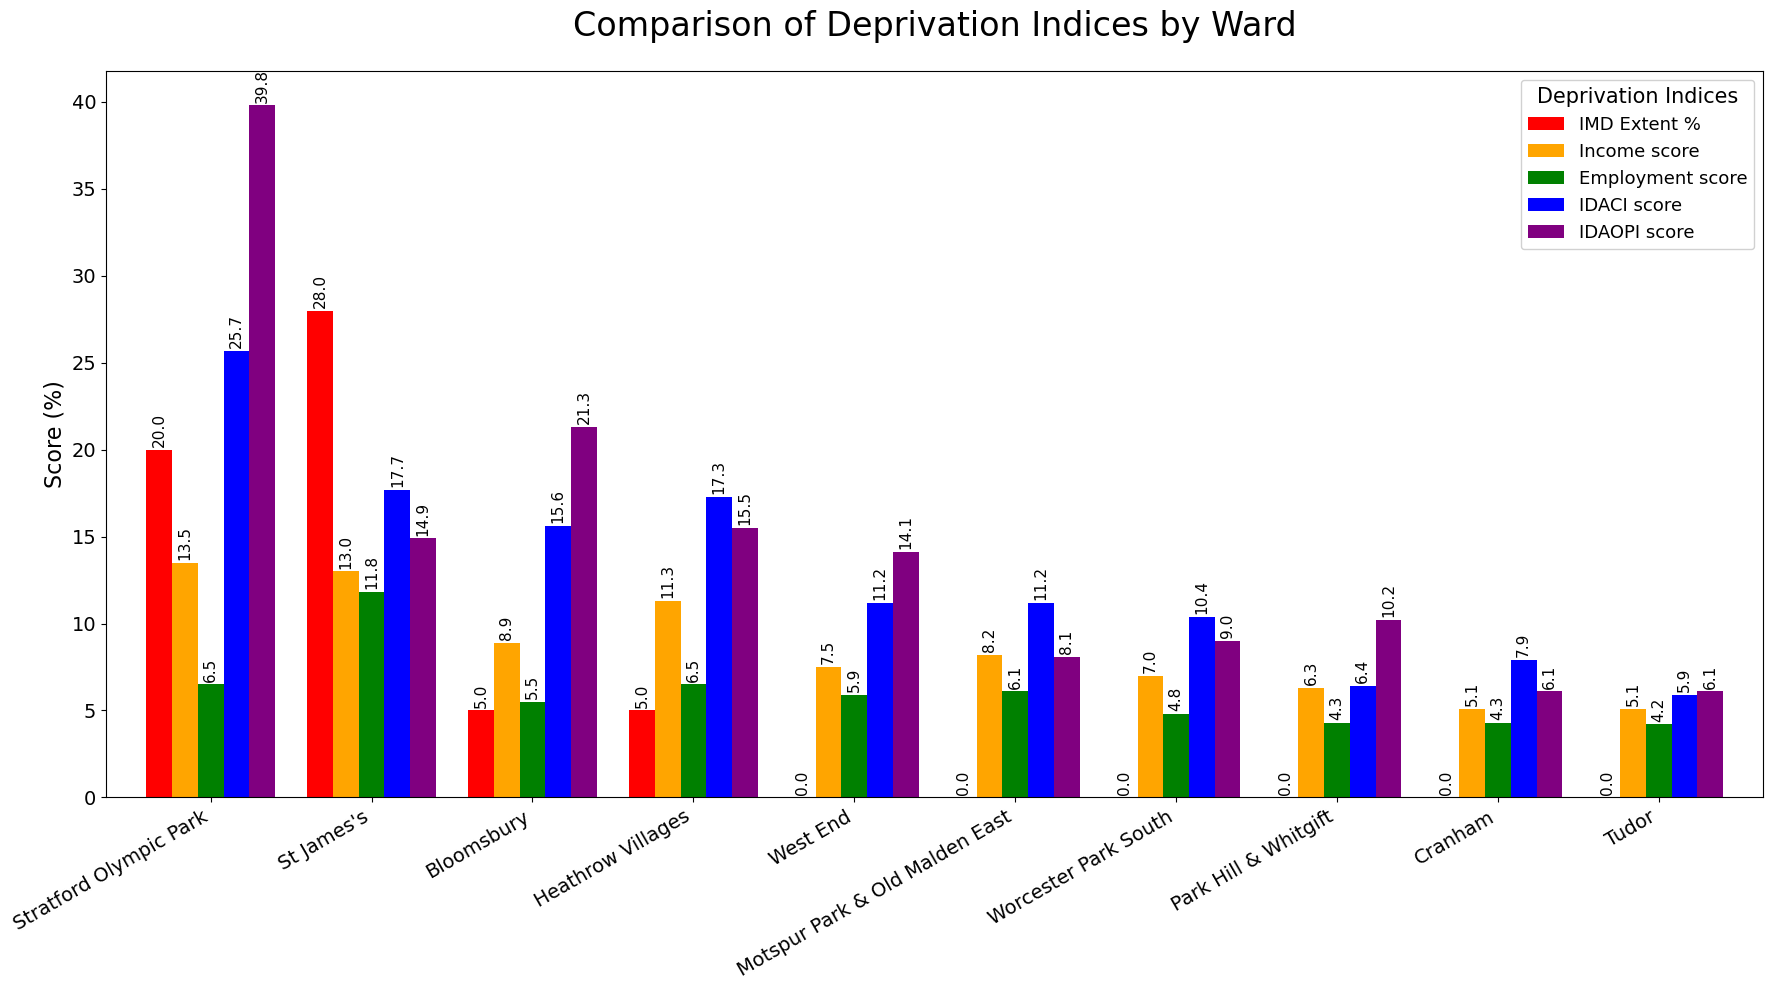

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Data for all 10 wards
wards = {
    "West End": {"IMD Extent %": 0, "Income score": 7.5, "Employment score": 5.9, "IDACI score": 11.2, "IDAOPI score": 14.1},
    "St James's": {"IMD Extent %": 28, "Income score": 13.0, "Employment score": 11.8, "IDACI score": 17.7, "IDAOPI score": 14.9},
    "Bloomsbury": {"IMD Extent %": 5, "Income score": 8.9, "Employment score": 5.5, "IDACI score": 15.6, "IDAOPI score": 21.3},
    "Heathrow Villages": {"IMD Extent %": 5, "Income score": 11.3, "Employment score": 6.5, "IDACI score": 17.3, "IDAOPI score": 15.5},
    "Stratford Olympic Park": {"IMD Extent %": 20, "Income score": 13.5, "Employment score": 6.5, "IDACI score": 25.7, "IDAOPI score": 39.8},
    "Motspur Park & Old Malden East": {"IMD Extent %": 0, "Income score": 8.2, "Employment score": 6.1, "IDACI score": 11.2, "IDAOPI score": 8.1},
    "Tudor": {"IMD Extent %": 0, "Income score": 5.1, "Employment score": 4.2, "IDACI score": 5.9, "IDAOPI score": 6.1},
    "Worcester Park South": {"IMD Extent %": 0, "Income score": 7.0, "Employment score": 4.8, "IDACI score": 10.4, "IDAOPI score": 9.0},
    "Cranham": {"IMD Extent %": 0, "Income score": 5.1, "Employment score": 4.3, "IDACI score": 7.9, "IDAOPI score": 6.1},
    "Park Hill & Whitgift": {"IMD Extent %": 0, "Income score": 6.3, "Employment score": 4.3, "IDACI score": 6.4, "IDAOPI score": 10.2},
}

# Convert to DataFrame
df = pd.DataFrame(wards).T

# Compute overall deprivation score (mean of all indices)
df["Overall Score"] = df.mean(axis=1)

# Sort wards DESC by overall score
df_sorted = df.sort_values("Overall Score", ascending=False).drop(columns="Overall Score")

# Define fixed colors for each index
colors = {
    "IMD Extent %": "red",
    "Income score": "orange",
    "Employment score": "green",
    "IDACI score": "blue",
    "IDAOPI score": "purple"
}

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(18,10))  # Enlarged figure
df_sorted.plot(kind="bar", ax=ax, width=0.8, color=[colors[col] for col in df_sorted.columns])

# Title and labels with larger fonts
plt.title("Comparison of Deprivation Indices by Ward", fontsize=24, pad=25)
plt.ylabel("Score (%)", fontsize=16)
plt.xticks(rotation=30, ha="right", fontsize=14)  # Diagonal ward names
plt.yticks(fontsize=14)

# Add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=11, rotation=90, padding=2)

# Legend INSIDE the chart on the right
ax.legend(
    title="Deprivation Indices",
    title_fontsize=15,
    fontsize=13,
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=0.9
)

plt.tight_layout()

# Save figure to variable
moh_indices = fig

# Save chart as PNG
png_filename = "moh_indices.png"
moh_indices.savefig(png_filename, dpi=300, bbox_inches="tight")

# Create HTML with embedded PNG reference + legend text
html_content = f"""
<html>
<head><title>Deprivation Indices by Ward</title></head>
<body>
<h2>Comparison of Deprivation Indices by Ward</h2>
<img src="{png_filename}" alt="Deprivation Indices Chart">
<p>Legend:<br>
<span style='color:red'>■ IMD Extent %</span><br>
<span style='color:orange'>■ Income score</span><br>
<span style='color:green'>■ Employment score</span><br>
<span style='color:blue'>■ IDACI score</span><br>
<span style='color:purple'>■ IDAOPI score</span></p>
</body>
</html>
"""

# Save HTML file with the requested name
with open("moh_indices.html", "w") as f:
    f.write(html_content)

print("✅ Chart saved as 'moh_indices.png' and 'moh_indices.html' with larger fonts, diagonal ward names, and legend inside on the right.")


<div align="center">

## ***Final Observations and Conclusion***

</iv>


Theft is the most frequently recorded offence by both the City of London Police and the Metropolitan Police.

In [52]:
%%sql
WITH clp AS (
  SELECT
    "Crime type" AS clp_crime,
    COUNT(*)     AS clp_count
  FROM LP_GEOSPATIAL_CRIMES
  GROUP BY "Crime type"
  ORDER BY clp_count DESC
  LIMIT 1
),
met AS (
  SELECT
    MajorText     AS met_crime,
    SUM("202505") AS met_count
  FROM MP_WARD_LEVEL
  GROUP BY MajorText
  ORDER BY met_count DESC
  LIMIT 1
)
SELECT
  clp_crime AS "Most Committed Crime (City of London Police)",
  clp_count AS "Number of Records (City of London Police)",
  met_crime AS "Most Committed Crime (Metropolitan Police)",
  met_count AS "Number of Records (Metropolitan Police)"
FROM clp
CROSS JOIN met;

 * sqlite:///FinalDB.db
Done.


Most Committed Crime (City of London Police),Number of Records (City of London Police),Most Committed Crime (Metropolitan Police),Number of Records (Metropolitan Police)
Other theft,139,THEFT,24624


According to the data provided by the Metropolitan Police for May 2025, theft is a remarkably common offence in the most crime-prone areas of Greater London, as it amounts to 64.9% of the whole records. 

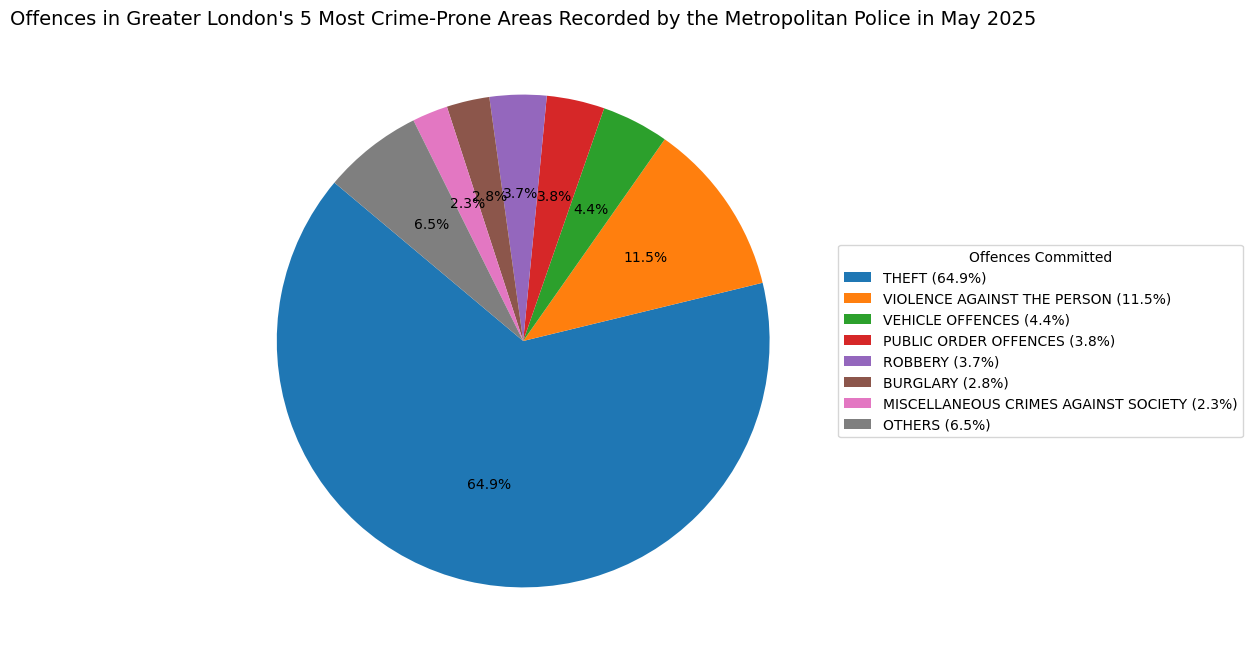

In [53]:
mp_crimes_most

According to the dataset `LP_OUTCOMES_CRIMES`, provided by the City of London Police, the majority of the offenders who committed the crimes recorded under the categories "*Other theft*", "*Shoplifting*", and "*Violence and sexual offences*" (assuming that each entry was executed by a different individual) were not prosecuted. However, it is important to emphasise that this analysis may be susceptible to recentism, as the dataset was released shortly after May 2025, and subsequent legal developments may have been occurred. 

In [54]:
print("Percentage of Positive Resolutions by Crime Type:")
print(f"Other theft: {other_theft_pct:.2f}%")
print(f"Shoplifting: {shoplifting_pct:.2f}%")
print(f"Violence and sexual offences: {violence_pct:.2f}%")

Percentage of Positive Resolutions by Crime Type:
Other theft: 4.29%
Shoplifting: 20.27%
Violence and sexual offences: 24.24%


Violent crimes are common in the safest areas of Greater London, whereas thefts are common in the most crime-prone areas of the City.

In [55]:
%%sql
WITH ward_counts AS (
  SELECT
    "WardName"  AS ward,
    "MajorText" AS crime,
    SUM("202505") AS cnt
  FROM MP_WARD_LEVEL
  WHERE "WardName" IN (
    'West End',
    'St James''s',
    'Bloomsbury',
    'Heathrow Villages',
    'Stratford Olympic Park',
    'Motspur Park & Old Malden East',
    'Tudor',
    'Worcester Park South',
    'Cranham',
    'Park Hill & Whitgift'
  )
  GROUP BY "WardName", "MajorText"
),
ranked AS (
  SELECT
    ward, crime, cnt,
    RANK() OVER (PARTITION BY ward ORDER BY cnt DESC) AS rnk
  FROM ward_counts
)
SELECT
  ward  AS "Ward",
  crime AS "Most Committed Crime",
  cnt   AS "Number of Offences"
FROM ranked
WHERE rnk = 1
ORDER BY cnt DESC, ward;


 * sqlite:///FinalDB.db
Done.


Ward,Most Committed Crime,Number of Offences
West End,THEFT,1871
St James's,THEFT,996
Bloomsbury,THEFT,415
Stratford Olympic Park,THEFT,274
Heathrow Villages,THEFT,136
Park Hill & Whitgift,VIOLENCE AGAINST THE PERSON,12
Motspur Park & Old Malden East,VIOLENCE AGAINST THE PERSON,6
Worcester Park South,THEFT,5
Cranham,VIOLENCE AGAINST THE PERSON,3
Tudor,SEXUAL OFFENCES,3


The areas of Greater London with the highest crime rates tend to have larger proportions of residents of foreign nationality, whereas the safest wards are predominantly populated by British citizens.

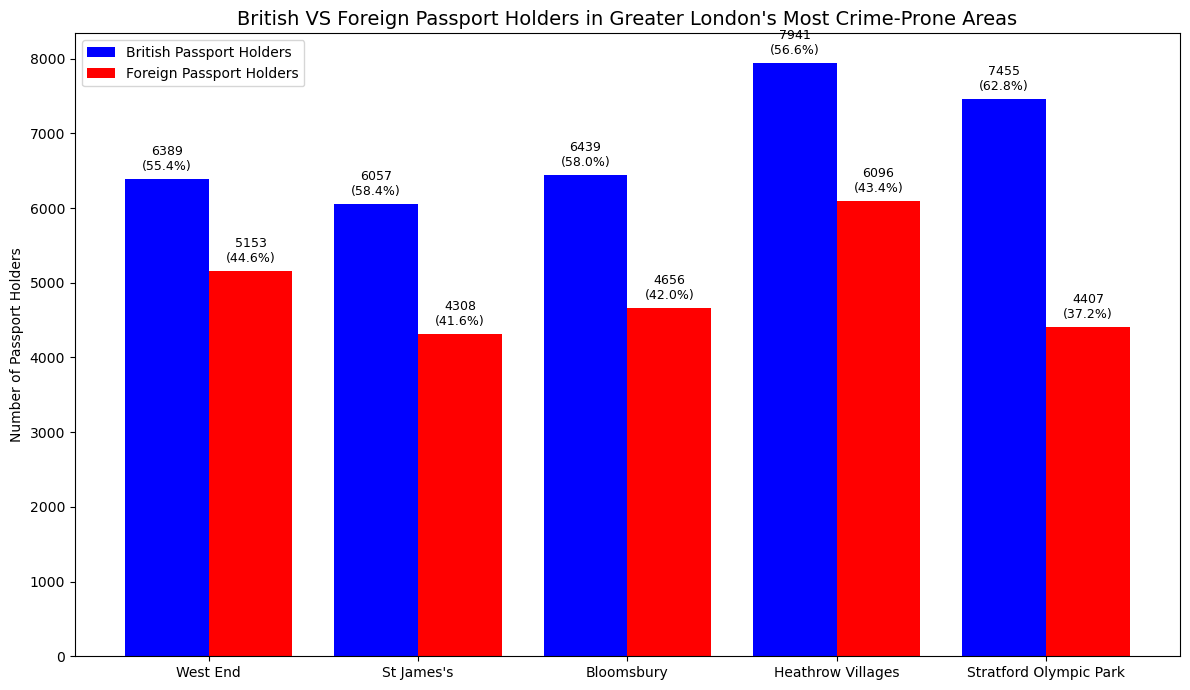

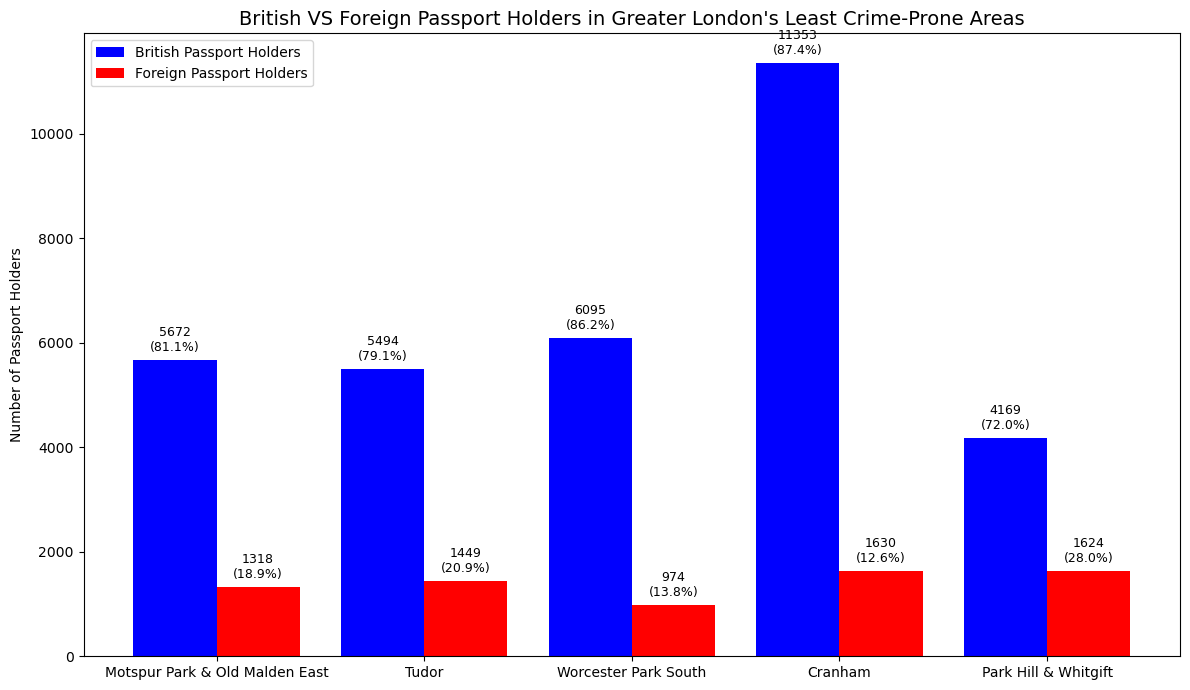

In [56]:
from IPython.display import display

display(ons_passport_holders_most, ons_passport_holders_least)

On the other hand, with the exception of Worcester Park South and Cranham, where we observed an increase in the White British population, all other locations remain comparably multi-ethnic.

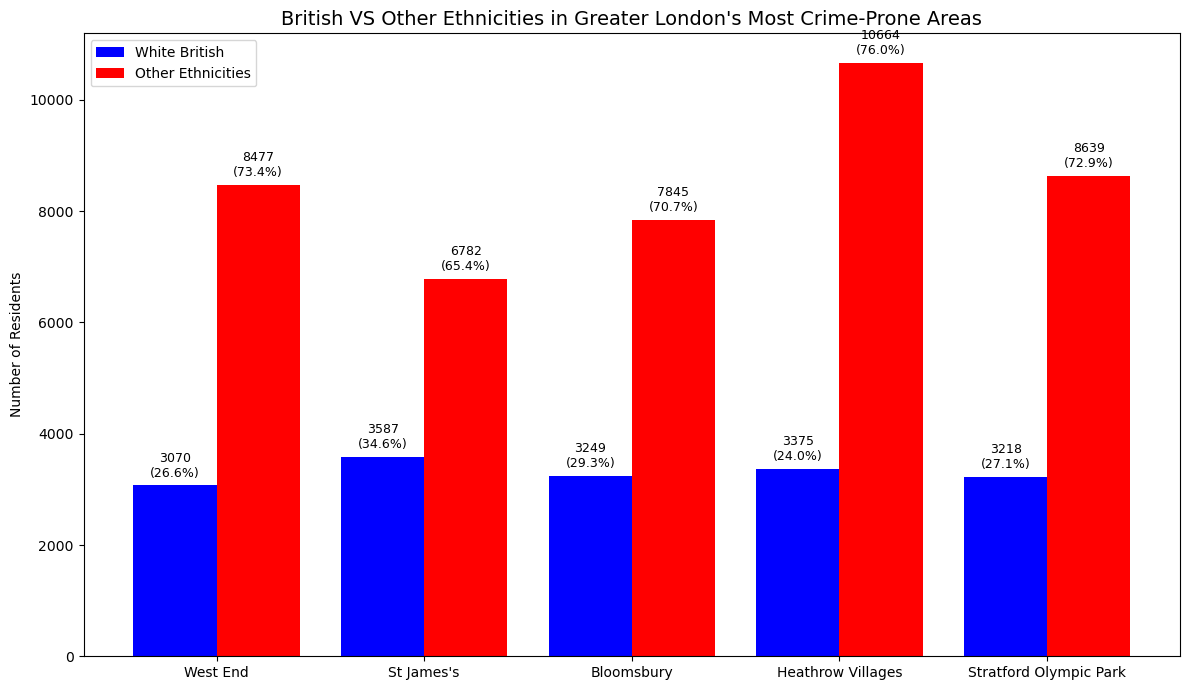

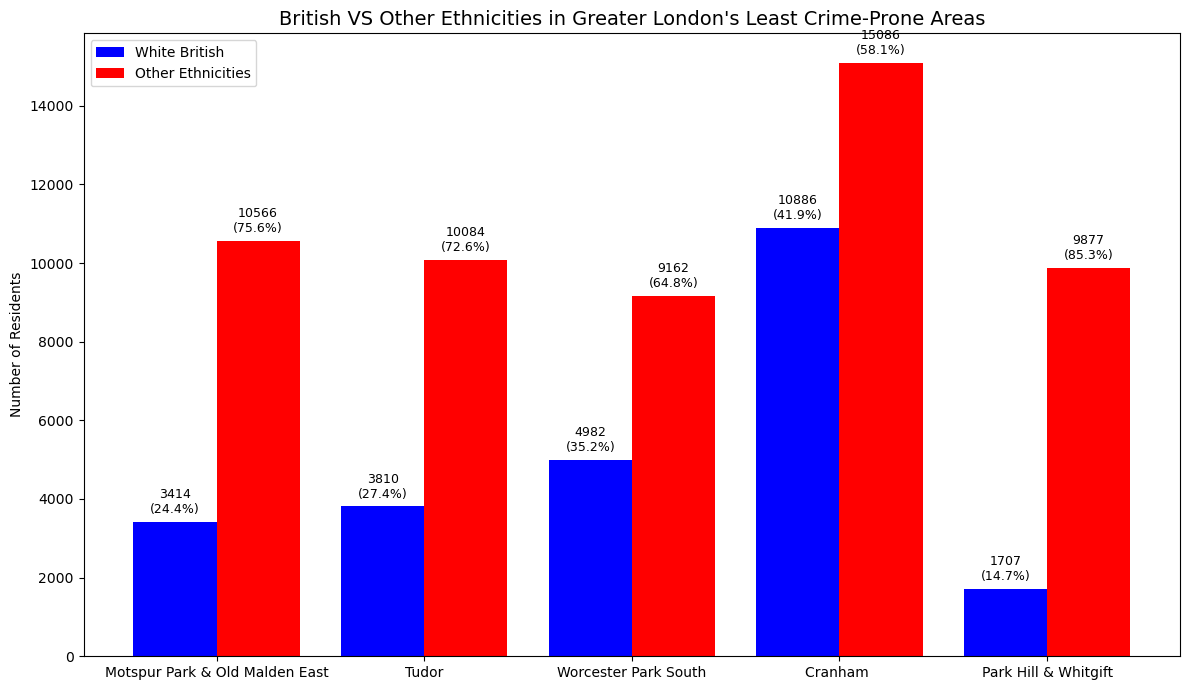

In [57]:
display(ons_ethnic_groups_most, ons_ethnic_groups_least)

Among the variables considered, the indices that most closely correlate with the crime levels of an area are the Deprivation Indices provided by the Ministry of Housing, Communities & Local Government. Indeed, they closely mirror the order in which the wards were originally classified.

| Most Crime-Prone Wards | Least Crime-Prone Wards | 
|---------------|--------------|
| West End   | Motspur Park & Old Malden East|
| St James's | Tudor |
| Bloomsbury | Worcester |
| Heathrow Villages | Cranham |    
| Stratford Olympic Park | Park Hill & Whitgift|

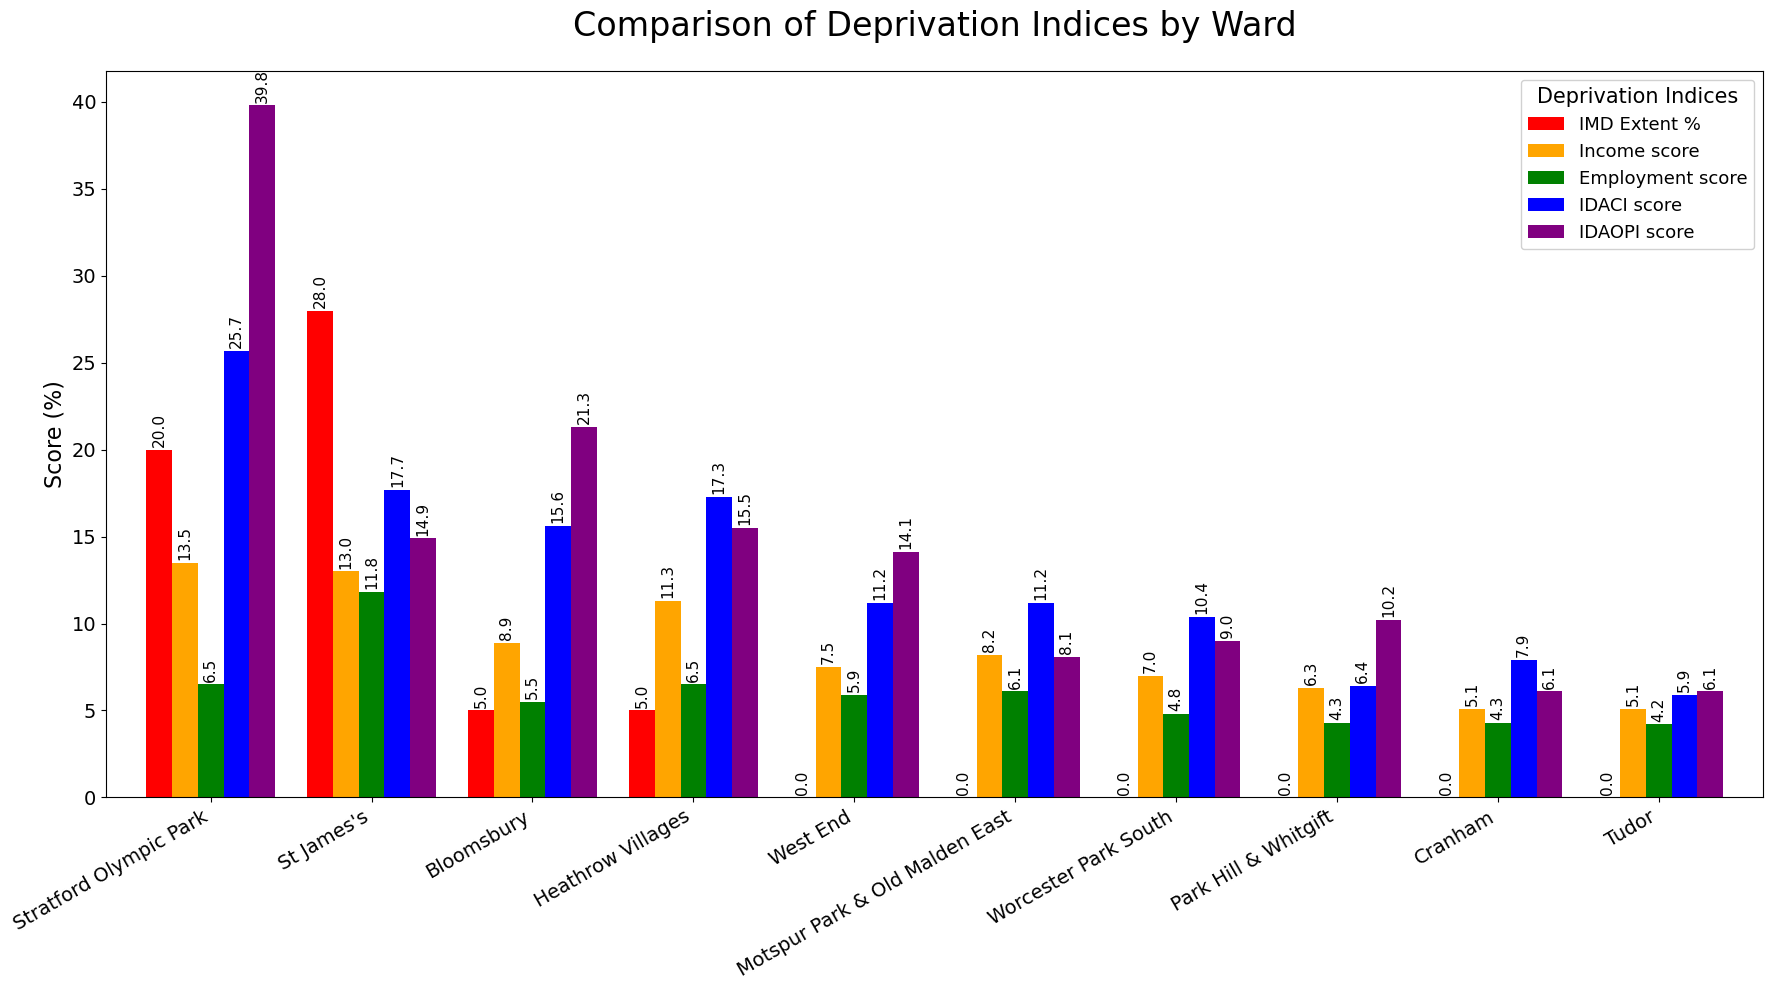

In [58]:
moh_indices

# **Author**
## **[Matteo Meloni](https://www.linkedin.com/in/matteo-meloni-40a357154/)**